# Set up

In [ ]:
#Intall packages
packages <- readLines("requirements.txt")
install_if_missing <- function(pkg) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    install.packages(pkg, dependencies = TRUE)
  }
}
invisible(lapply(packages, install_if_missing))
install.packages(c("recipes", "hardhat", "sparsevctrs","sjmisc","survminer","knitr","markdown"), type = "binary")


Warning message in check_dep_version():
"ABI version mismatch: 
lme4 was built with Matrix ABI version 1
Current Matrix ABI version is 0
Please re-install lme4 from source or restore original 'Matrix' package"
Installation des packages dans 'C:/Users/atanoh/AppData/Local/R/win-library/4.2'
(car 'lib' n'est pas spécifié)




   le package 'sparsevctrs' est disponible comme source mais non comme binaire


  Des versions binaires sont disponibles (et seront installées) mais
  les versions des sources sont plus récentes:
          binary source
recipes   1.0.10  1.3.1
hardhat    1.3.1  1.4.1
sjmisc     2.8.9 2.8.11
survminer  0.4.9  0.5.0
knitr       1.46   1.50
markdown    1.12    2.0



Warning message:
"le package 'sparsevctrs' n'est pas disponible as a binary package for this version of R

Une version de ce package pour votre version de R est peut-être disponible ailleurs,
Voyez des idées à
https://cran.r-project.org/doc/manuals/r-patched/R-admin.html#Installing-packages"


le package 'recipes' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'hardhat' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'sjmisc' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'survminer' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'knitr' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'markdown' a été décompressé et les sommes MD5 ont été vérifiées avec succés

Les packages binaires téléchargés sont dans
	C:\Users\atanoh\AppData\Local\Temp\RtmpMTKGAX\downloaded_packages


## Load libraries

In [ ]:
# Required packages
library(ggplot2)
library(reshape2)
library(dplyr)
library(RColorBrewer)
library(DescTools)
library(purrr)
library(mice)
library(haven)
library(tidyverse)
library(dplyr)
library(tidyr)
library(writexl)
library(naniar)
library(ggpubr)
library(openxlsx)
library(labelled)
library(lava)
library(recipes)
library(caret)
library(broom)
library(broom.helpers)
library(nnet)
library(gamlss)
library(MASS)
library(brant)
library(lubridate)
library(patchwork) 

Warning message:
"le package 'reshape2' a été compilé avec la version R 4.2.3"
Warning message:
"le package 'dplyr' a été compilé avec la version R 4.2.3"

Attachement du package : 'dplyr'


Les objets suivants sont masqués depuis 'package:stats':

    filter, lag


Les objets suivants sont masqués depuis 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"le package 'DescTools' a été compilé avec la version R 4.2.3"
Warning message:
"le package 'purrr' a été compilé avec la version R 4.2.3"
Warning message:
"le package 'mice' a été compilé avec la version R 4.2.3"

Attachement du package : 'mice'


L'objet suivant est masqué depuis 'package:stats':

    filter


Les objets suivants sont masqués depuis 'package:base':

    cbind, rbind


Warning message:
"le package 'haven' a été compilé avec la version R 4.2.3"
Warning message:
"le package 'tidyverse' a été compilé avec la version R 4.2.3"
Warning message:
"le package 'tibble' a été compilé avec la version R 4

## Load dataset

In [3]:

data <- read_sav("./Torres_bd_vf.sav")
data <- data %>%
  mutate(across(where(~ inherits(.x, "haven_labelled")), ~ as.factor(.x)))
glimpse(data)


Rows: 120
Columns: 436
$ IdPac                    <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14…
$ Centro                   <chr> "CLÍNIC", "CLÍNIC", "CLÍNIC", "CLÍNIC", "CLÍN…
$ FechaIngr                <date> 2004-06-23, 2004-09-10, 2004-11-18, 2004-12-…
$ Sexo                     <fct> 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, …
$ Edad                     <dbl> 80, 91, 77, 59, 63, 81, 91, 58, 77, 40, 82, 8…
$ Sala                     <fct> 1, 4, 1, 4, 4, 1, 0, 4, 0, 0, 1, 1, 4, 4, 4, …
$ UCI_Interm               <fct> 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, …
$ FechaIncl                <date> 2004-06-23, 2004-09-10, 2004-11-19, 2004-12-…
$ Coment                   <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, N…
$ Fumador                  <fct> 1, 2, 1, 0, 1, 2, 2, 2, 2, 1, 2, 2, 0, 0, 1, …
$ NumPaq                   <dbl> 10, 60, 60, NA, 100, NA, 75, 25, NA, NA, NA, …
$ Enolismo                 <fct> 0, 2, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, …
$ Diabetes       

In [4]:

# summary_table<-data %>%
#   summarise(across(everything(), list(
#     class = ~ class(.x)[1],
#     example = ~ paste0(head(.x, 6), collapse = ", ")
#   ))) %>%
#   pivot_longer(cols = everything(),
#                names_to = c("Variable", ".value"),
#                names_sep = "_")
# # writexl::write_xlsx(summary_table, "glimpse_summary.xlsx")

## Useful functions

### Univariate analysis

In [5]:
characteristics <- function(dataset) {
    #' To compute characteristics of a dataet
    #' @param dataset 'A dataframe'
    #' @return a dataframe with type, number of modalities, number of NA, min, mean, max and mode of each variable of the dataset


  carac <- data.frame(variable = colnames(dataset), stringsAsFactors = FALSE)
  
  # Types
  carac$types <- sapply(dataset, class)
  
  # Number of modalities
  carac$nombre_de_modalites <- sapply(dataset, function(col) length(unique(col)))
  
  # Number of missing values
  carac$number_of_missing_values <- sapply(dataset, function(col) sum(is.na(col)))
  
  # Proportion of missing values
  carac$proportion_missing_values_percent <- round(carac$number_of_missing_values / nrow(dataset) * 100, 1)
  
  # Mean, max, min for numeric columns
  carac$moyenne <- sapply(dataset, function(col) {
    if (all(is.na(col))) {NA}
    else if (is.numeric(col) && !inherits(col, "haven_labelled")) {mean(col, na.rm = TRUE)}
    else {NA}
}) 
  carac$maximum <- sapply(dataset, function(col) {
    if (all(is.na(col))) {NA}
    else if (is.numeric(col) && !inherits(col, "haven_labelled")) {max(col, na.rm = TRUE)}
    else {NA}
})
  carac$minimum <- sapply(dataset, function(col) {
    if (all(is.na(col))) {NA}
    else if (is.numeric(col) && !inherits(col, "haven_labelled")) {min(col, na.rm = TRUE)}
    else {NA}
})
  
  # Mode
  get_mode <- function(col) {
    col <- col[!is.na(col)]
    if (length(col) == 0) return(NA)
    uniq_vals <- unique(col)
    freq <- tabulate(match(col, uniq_vals))
    uniq_vals[which.max(freq)]
  }
  
  carac$mode <- sapply(dataset, get_mode)
  
  # Proportion of mode
  prop_mode <- function(col, mode_val) {
  # Convert haven_labelled or factors to character first
  col_chr <- as.character(col)
  mode_chr <- as.character(mode_val)
  
  if (is.na(mode_val)) {
    return(round(sum(is.na(col)) / length(col) * 100, 3))
  } else {
    return(round(sum(col_chr == mode_chr, na.rm = TRUE) / length(col) * 100, 3))
  }
}
  
  carac$proportion_mode_percent <- mapply(prop_mode, dataset, carac$mode)
  
  return(carac)
}


In [6]:
#Check normality of numerical variables
seek_normality<-function(col) {
    #' Perform a shapiro-wilk test of normality to see if a numerical variable is normally distributed
    #' @param col 'The variable'
    #' @return a datafram with the veridict of normality 
  if (is.numeric(col) && !inherits(col, "haven_labelled")) {
    col_clean <- col[!is.na(col)]
    if (length(col_clean) < 3) {
      return(NA)  # Shapiro-Wilk requires at least 3 values
    }
    p_val <- shapiro.test(col_clean)$p.value
    if (p_val >= 0.05) {
      return("normal")
    } else {
      return("not normal")
    }
  } else {
    return(NA)
  }
}

In [ ]:
summary_cat_by_group <- function(df, group_var_name="Grupo") {
  #' To retrieve number of individuals and proportions of a modality of categorical variablesof a dataframe, desagragated according to another categorical variable
  #' @param df A dataframe
  #' @param group_var_name The variable of desagragation
  #' @return A dataframe with the overall numbers and proportions for each categorical variable of the dataset, in addition of the desagragated results

  group_var <- df[[group_var_name]]
  
  # Select categorical variables (factors or character)
  cat_vars <- names(df)[sapply(df, function(x) is.factor(x) || is.character(x))]
  
  result_list <- list()
  
  for (var in cat_vars) {
    cat_var <- df[[var]]
    
    # Remove rows with NA in cat_var or group_var
    valid <- !is.na(cat_var) & !is.na(group_var)
    cat_var <- cat_var[valid]
    group_var_valid <- group_var[valid]
    
    # Overall counts and proportions
    overall_table <- table(cat_var)
    overall_prop <- prop.table(overall_table)
    
    # Group 1 counts and proportions
    group1_table <- table(cat_var[group_var_valid == 1])
    group1_prop <- prop.table(group1_table)

    # Group 0 counts and proportions
    group0_table <- table(cat_var[group_var_valid == 0])
    group0_prop <- prop.table(group0_table)
    
    all_levels <- union(union(names(overall_table), names(group1_table)), names(group0_table))
    
    df_var <- data.frame(
      Variable = var,
      Category = all_levels,
      Overall_N_prop = paste(as.character(as.integer(overall_table[all_levels])),
      " (", 
      as.character(round(as.numeric(overall_prop[all_levels]),2)*100),
      ")"
      ),
      Treatment_N_prop = paste(as.character(as.integer(group1_table[all_levels])),
      " (", 
      as.character(round(as.numeric(group1_prop[all_levels]),2)*100),
      ")"
      ),
      Placebo_N_prop = paste(as.character(as.integer(group0_table[all_levels])),
      " (", 
      as.character(round(as.numeric(group0_prop[all_levels]),2)*100),
      ")"
      ),
      stringsAsFactors = FALSE
    )
    
    # Replace NAs with 0 for missing categories in groups
    df_var[is.na(df_var)] <- 0
    
    result_list[[var]] <- df_var
  }
  
  # Combine all into one big data.frame
  final_df <- do.call(rbind, result_list)
  rownames(final_df) <- NULL
  return(final_df)
}


summary_num_by_group <- function(df, group_var_name) {
  #' To retrieve mean and SD of numerical variables of a dataframe, desagragated according to another categorical variable
  #' @param df A dataframe
  #' @param group_var_name The variable of desagragation
  #' @return A dataframe with the overall mean and SD for each numerical variable of the dataset, in addition of the desagragated results

  group_var <- df[[group_var_name]]
  
  # Select numeric variables
  num_vars <- names(df)[sapply(df, is.numeric)]
  
  result_list <- list()
  
  for (var in num_vars) {

    if (var != "EvolDiasUCI") {
      x <- df[[var]]
      # Remove missing values for each subset
      overall_x <- x[!is.na(x)]
      group1_x <- x[group_var == 1 & !is.na(x) & !is.na(group_var)]
      group0_x <- x[group_var == 0 & !is.na(x) & !is.na(group_var)]
      df_var <- data.frame(
        Variable = var,
        Overall_mean_SD = paste(as.character(round(mean(overall_x, na.rm=TRUE),1)),
        " (", 
        as.character(round(sd(overall_x, na.rm=TRUE),1)),
        ")"
        ),
        Overall_med_IQR = paste(as.character(round(median(overall_x,na.rm = TRUE),1)),
        " (", 
        as.character(round(quantile(overall_x, probs = 0.25, na.rm = TRUE)[[1]],1)),
        " - ",
        as.character(round(quantile(overall_x, probs = 0.75, na.rm = TRUE)[[1]],1)),
        ")"
        ),
        Overall_min_max = paste(as.character(round(min(overall_x,na.rm = TRUE),1)),
        " - ", 
        as.character(round(max(overall_x, na.rm = TRUE),1))
        ),

        Treatment_mean_SD=paste(as.character(round(mean(group1_x, na.rm=TRUE),1)),
        " (", 
        as.character(round(sd(group1_x, na.rm=TRUE),1)),
        ")"
        ),
        Treatment_med_IQR=paste(as.character(round(median(group1_x,na.rm = TRUE),1)),
        " (", 
        as.character(round(quantile(group1_x, probs = 0.25, na.rm = TRUE)[[1]],1)),
        " - ",
        as.character(round(quantile(group1_x, probs = 0.75, na.rm = TRUE)[[1]],1)),
        ")"
        ),
        Treatment_min_max = paste(as.character(round(min(group1_x,na.rm = TRUE),1)),
        " - ", 
        as.character(round(max(group1_x, na.rm = TRUE),1))
        ),

        Placebo_mean_SD=paste(as.character(round(mean(group0_x, na.rm=TRUE),1)),
        " (", 
        as.character(round(sd(group0_x, na.rm=TRUE),1)),
        ")"
        ),
        Placebo_med_IQR=paste(as.character(round(median(group0_x,na.rm = TRUE),1)),
        " (", 
        as.character(round(quantile(group0_x, probs = 0.25, na.rm = TRUE)[[1]],1)),
        " - ",
        as.character(round(quantile(group0_x, probs = 0.75, na.rm = TRUE)[[1]],1)),
        ")"
        ),
        Placebo_min_max = paste(as.character(round(min(group0_x,na.rm = TRUE),1)),
        " - ", 
        as.character(round(max(group0_x, na.rm = TRUE),1))
        )

      )
    }

    else {
      x <- df[[var]][df[[var]]>0 & !is.na(df[[var]])]
      # Remove missing values for each subset
      overall_x <- x[!is.na(x)]
      group1_x <- x[group_var == 1 & !is.na(x) & !is.na(group_var)]
      group0_x <- x[group_var == 0 & !is.na(x) & !is.na(group_var)]
      df_var <- data.frame(
        Variable = var,
        Overall_mean_SD = paste(as.character(round(mean(overall_x),1)),
        " (", 
        as.character(round(sd(overall_x),1)),
        ")"
        ),
        Overall_med_IQR = paste(as.character(round(median(overall_x,na.rm = TRUE),1)),
        " (", 
        as.character(round(quantile(overall_x, probs = 0.25, na.rm = TRUE)[[1]],1)),
        " - ",
        as.character(round(quantile(overall_x, probs = 0.75, na.rm = TRUE)[[1]],1)),
        ")"
        ),
        Overall_min_max = paste(as.character(round(min(overall_x,na.rm = TRUE),1)),
        " - ", 
        as.character(round(max(overall_x, na.rm = TRUE),1))
        ),

        Treatment_mean_SD=paste(as.character(round(mean(group1_x),1)),
        " (", 
        as.character(round(sd(group1_x),1)),
        ")"
        ),
        Treatment_med_IQR=paste(as.character(round(median(group1_x,na.rm = TRUE),1)),
        " (", 
        as.character(round(quantile(group1_x, probs = 0.25, na.rm = TRUE)[[1]],1)),
        " - ",
        as.character(round(quantile(group1_x, probs = 0.75, na.rm = TRUE)[[1]],1)),
        ")"
        ),
        Treatment_min_max = paste(as.character(round(min(group1_x,na.rm = TRUE),1)),
        " - ", 
        as.character(round(max(group1_x, na.rm = TRUE),1))
        ),

        Placebo_mean_SD=paste(as.character(round(mean(group0_x),1)),
        " (", 
        as.character(round(sd(group0_x),1)),
        ")"
        ),
        Placebo_med_IQR=paste(as.character(round(median(group0_x,na.rm = TRUE),1)),
        " (", 
        as.character(round(quantile(group0_x, probs = 0.25, na.rm = TRUE)[[1]],1)),
        " - ",
        as.character(round(quantile(group0_x, probs = 0.75, na.rm = TRUE)[[1]],1)),
        ")"
        ),
        Placebo_min_max = paste(as.character(round(min(group0_x,na.rm = TRUE),1)),
        " - ", 
        as.character(round(max(group0_x, na.rm = TRUE),1))
        )
        

      )
    }
    result_list[[var]] <- df_var
    }
    
    
  
  final_df <- do.call(rbind, result_list)
  rownames(final_df) <- NULL
  return(final_df)
}




### Bivariate analysis

In [ ]:
compare_var_cat <- function(df, group_var_name) {
  #' To see if categorical variables are associated with the variable of interest, using chi2 or fisher test according to headcount
  #' @param df A dataframe
  #' @param group_var_name name of the variable of interest
  #' @return A data frame with categerical variables names, the name of the test, the p-value and the verdict (wheter or not the test is significant)
  

  #retrive categorical variables in the dataframe
  cat_vars <- names(df)[sapply(df, function(x) is.factor(x) || is.character(x))]
  cat_vars <- setdiff(cat_vars, group_var_name)
  result_list <- list()

  for (var in cat_vars) {
    #For each categorical variable compute contigency table...
    contingency <- table(df[[var]], df[[group_var_name]])
    expected <- chisq.test(contingency)$expected
    test_type <- ""
    pval <- NA

    #...then check headcounts
    if (all(expected >= 5)) {
      #...chi2 test if all headcounts >5...
      pval <- round(chisq.test(contingency)$p.value, 3)
      test_type <- "Chi2"
    } else {
      #...or else fisher test
      pval <- round(fisher.test(contingency)$p.value, 3)
      test_type <- "Fisher"
    }

    verdict <- if (pval < 0.1) "associated/significative difference" else "No significative difference"
    
    # Format results
    result_list[[var]] <- data.frame(
      Variable = var,
      Test = test_type,
      P_value = pval,
      Verdict = verdict,
      stringsAsFactors = FALSE
    )
  }

  final_df <- do.call(rbind, result_list)
  rownames(final_df) <- NULL
  return(final_df)
}


compare_var_num <- function(df, group_var_name) {
  #' To see if numerical variables are associated with the variable of interest, using student or mann-whitney test according to normality
  #' @param df A dataframe
  #' @param group_var_name name of the variable of interest
  #' @return A data frame with numerical variables names, the name of the test, the p-value and the verdict (wheter or not the test is significant)
  
  #Retrive numerical variabels in the dataframe
  num_vars <- names(df)[sapply(df, is.numeric)]
  result_list <- list()

  for (var in num_vars) {
    data_subset <- df[!is.na(df[[var]]) & !is.na(df[[group_var_name]]), ]
    
    # Skip if fewer than 3 non-NA values per group
    if (any(table(data_subset[[group_var_name]]) < 3)) next
    
    # Normality test on whole variable
    if (shapiro.test(data_subset[[var]])$p.value >= 0.05) {
      # Student t-test
      group0 <- data_subset[data_subset[[group_var_name]] == 0, var]
      group1 <- data_subset[data_subset[[group_var_name]] != 0, var]
      pval <- round(t.test(group0, group1)$p.value,3)
      test <- "Student"
    } else {
      # Wilcoxon test
      formula <- as.formula(paste(var, "~", group_var_name))
      pval <- round(wilcox.test(formula, data = data_subset)$p.value,3)
      test <- "Mann-Whitney"
    }

    verdict <- if (pval < 0.1) "associated/significative difference" else "No significative difference"

    #Format results
    result_list[[var]] <- data.frame(
      Variable = var,
      test=test,
      pvalue = pval,
      verdict = verdict,
      stringsAsFactors = FALSE
    )
  }

  final_df <- do.call(rbind, result_list)
  rownames(final_df) <- NULL
  return(final_df)
}



In [72]:
names(data_dint)

[1] "IdPac"                    "YearOfAdmission"         
 [3] "Edad"                     "Sexo"                    
 [5] "Fumador"                  "Diabetes"                
 [7] "EPOC"                     "HTA"                     
 [9] "Cancer"                   "CardIsq"                 
[11] "CFiebre"                  "CAlterNivelConc"         
[13] "CDisnea"                  "CTos"                    
[15] "CEscalofrios"             "CDolorPleur"             
[17] "FINE"                     "Puntos"                  
[19] "CdxVM"                    "CdxVMtipo"               
[21] "CdxShockSept"             "CdxPAP90"                
[23] "CdxMultilobar"            "CdxPaFi250"              
[25] "RatioPao2_oxygen"         "UCI_Interm"              
[27] "TimeToFirstAntibiotic_SS" "macrolide"               
[29] "BGlucosa"                 "BCreatinina"             
[31] "HPlaquetas"               "HLeucocitos"             
[33] "BProteinasTot"            "PCT1"                    
[35] "IL61"                     "IL81"                    
[37] "IL101"                    "Temperatura"             
[39] "FR"                       "FC"                      
[41] "EarlyFailure"             "EMV"                     
[43] "ESS"                      "ED"                      
[45] "LateFailure"              "RP"                      
[47] "RF"                       "LMV"                     
[49] "LSS"                      "tiempo_estancia"         
[51] "EvolDiasUCI"              "EvolMort28"              
[53] "EstabClin"                "Dia_TF"                  
[55] "Grupo"                    "ITT"                     
[57] "PP"                       "Centro"                  
[59] "ratio_il6_il10"           "TreatmentFailure"        
[61] "EarlyFailureMan"          "LateFailureMan"          
[63] "TreatmentFailureMan"

In [75]:
compare_var_cat(df=data_dint,group_var_name = "Grupo")

Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingenc

Variable,Test,P_value,Verdict
<chr>,<chr>,<dbl>,<chr>
YearOfAdmission,Fisher,0.886,No significative difference
Sexo,Chi2,0.427,No significative difference
Fumador,Chi2,0.872,No significative difference
Diabetes,Chi2,0.580,No significative difference
EPOC,Chi2,0.280,No significative difference
HTA,Chi2,0.740,No significative difference
Cancer,Chi2,0.186,No significative difference
CardIsq,Chi2,0.692,No significative difference
CFiebre,Chi2,0.346,No significative difference


In [9]:
compare_proportions <- function(data, variables, group_var) {
  #' To see if proportion differ from one modality of a categorical variable to another,according to a variable of interest, using a Chi-squared test for proportions
  #' @param data A dataframe
  #' @param variables list of variables we want to test
  #' @param group_var name of the variable of interest
  #' @return A data frame with the variables names, the p-value of the test, the difference of proportions and the 95% CI
  
  results <- lapply(variables, function(var) {
    tab <- table(data[[group_var]], data[[var]])
    
    # Ensure the table is 2x2
    if (!all(dim(tab) == c(2, 2))) return(NULL)
    
    # Make sure rows of the table are in order: group 0 then group 1
    group_levels <- sort(unique(data[[group_var]]))
    if (!all(as.numeric(rownames(tab)) == group_levels)) {
      tab <- tab[as.character(group_levels), ]
    }
    
    # Extract success counts (column 1 = 0, column 2 = 1)
    successes <- tab[, "1"]
    totals <- rowSums(tab)

    # prop2 - prop1
    test <- prop.test(successes, totals, correct = FALSE)
    diff_prop <- round(100 * (test$estimate[1] - test$estimate[2]), 0)
    ci_low <- round(100 * test$conf.int[1], 0)
    ci_high <- round(100 * test$conf.int[2], 0)
    p_val <- round(test$p.value, 2)

    diff_ci_str <- paste0(diff_prop, " (", ci_low, "–", ci_high, ")")

    data.frame(
      Variable = var,
      P_value = p_val,
      Difference_CI = diff_ci_str,
      stringsAsFactors = FALSE
    )
  })

  # Combine results
  do.call(rbind, results)
}


In [10]:
compare_medians <- function(data, variables, group_var) {
  #' To see if medians differ from one modality of a categorical variable to another, according to a variable of interest, using a Mann–Whitney U test
  #' @param data A dataframe
  #' @param variables list of variables we want to test
  #' @param group_var name of the variable of interest
  #' @return A data frame with the variables names, the p-value of the test, the difference of medians and the 95% CI


  results <- lapply(variables, function(var) {
    group0 <- data[data[[group_var]] == 0, var, drop = TRUE]
    group1 <- data[data[[group_var]] == 1, var, drop = TRUE]
    
    # Remove NA
    group0 <- group0[!is.na(group0)]
    group1 <- group1[!is.na(group1)]
    
    if (length(group0) == 0 || length(group1) == 0) return(NULL)

    # Median difference
    diff_median <- round(median(group1) - median(group0), 2)
    
    # P-value
    p_val <- round(wilcox.test(group0, group1, exact = FALSE)$p.value, 4)
    
    # Bootstrap CI for median difference
    boot_diffs <- replicate(1000, {
      med1 <- median(sample(group1, replace = TRUE))
      med0 <- median(sample(group0, replace = TRUE))
      med1 - med0
    })
    
    ci <- quantile(boot_diffs, probs = c((1 - 0.95)/2, 1 - (1 - 0.95)/2))
    ci_str <- paste0(round(ci[1], 2), " – ", round(ci[2], 2))
    
    data.frame(
      Variable = var,
      Median_Diff = diff_median,
      CI_95 = ci_str,
      P_value = p_val,
      stringsAsFactors = FALSE
    )
  })
  
  do.call(rbind, results)
}


In [11]:

# Define CorrelationsStudy class
CorrelationsStudy <- setRefClass(
    #' A class of methods to perform correlation analysis
    #' @params A dataframe and a list of its numerical and categorical variables
  "CorrelationsStudy",
  fields = list(
    dataset = "data.frame",
    numerical_variables = "character",
    categorical_variables = "character"
  ),
  methods = list(
    initialize = function(dataset) {
      dataset <<- dataset
      numerical_variables <<- names(dataset)[sapply(dataset, is.numeric)] #retrieve list of numerical variables
      categorical_variables <<- setdiff(names(dataset), numerical_variables) #retrieve list of categorical variables
    },

    num_correlation_heatmap = function() {
        #' To compute pearson correlation scores among all numerical variables
        #' @return A heatmap displaying correlations

      corr_matrix <- cor(dataset[, numerical_variables], use = "pairwise.complete.obs")
      melted_corr <- melt(corr_matrix)
      ggplot(melted_corr, aes(Var1, Var2, fill = value)) +
        geom_tile() +
        geom_text(aes(label = round(value, 2)), size = 4) +
        scale_fill_distiller(palette = "Spectral", direction = 1,limits = c(-1, 1)) +
        theme_minimal() +
        theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
        labs(title = "Numerical Correlation Heatmap", fill = "Correlation")
    },

    cat_correlation_heatmap = function() {
        #' To compute Cramer's v correlation scores among all categorical variables
        #' @return A heatmap displaying correlations
        
      n_vars <- length(categorical_variables)
      assoc_matrix <- matrix(1, nrow = n_vars, ncol = n_vars)
      colnames(assoc_matrix) <- categorical_variables
      rownames(assoc_matrix) <- categorical_variables

      for (i in seq_len(n_vars)) {
        for (j in seq(i + 1, n_vars)) {
          x <- dataset[[categorical_variables[i]]]
          y <- dataset[[categorical_variables[j]]]
          assoc <- CramerV(table(x, y), bias.correct = TRUE)
          assoc_matrix[i, j] <- assoc
          assoc_matrix[j, i] <- assoc
        }
      }
      melted_assoc <- melt(assoc_matrix)
      ggplot(melted_assoc, aes(Var1, Var2, fill = value)) +
        geom_tile() +
        geom_text(aes(label = round(value, 2)), size = 4) +
        scale_fill_distiller(palette = "Spectral", direction = 1, limits = c(-1, 1)) +
        theme_minimal() +
        theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
        labs(title = "Categorical Correlation Heatmap (Cramer's V)", fill = "Cramer's V")
    },

    kruskall_wallis = function() {
        #' To compute kruskall-wallis test (difference of means) to see how numerical and categorical variables are correlated
        #' @return A list of correlated couples (numerical variable, categorical variable)
        
      kruskal_correlation <- list()

      for (num_var in numerical_variables) {
        for (cat_var in categorical_variables) {
          df <- dataset %>% filter(!is.na(.data[[num_var]]), !is.na(.data[[cat_var]]))
          if (length(unique(df[[cat_var]])) < 2) next

          kw_test <- kruskal.test(df[[num_var]] ~ as.factor(df[[cat_var]]))
          if (kw_test$p.value <= 0.05) {
            kruskal_correlation <- append(kruskal_correlation, list(c(num_var, cat_var)))
          }
        }
      }

      return(kruskal_correlation)
    }
  )
)


# Data exploration

In [12]:
#Characteristics of dataset
torres_caracs=characteristics(data[, !sapply(data, inherits, what = "Date")])
torres_caracs

variable,types,nombre_de_modalites,number_of_missing_values,proportion_missing_values_percent,moyenne,maximum,minimum,mode,proportion_mode_percent
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
IdPac,numeric,95,0,0.0,47.633333,301,1,20,1.667
Centro,character,3,0,0.0,NA,NA,NA,CLÍNIC,71.667
Sexo,factor,2,0,0.0,NA,NA,NA,2,0.000
Edad,numeric,59,0,0.0,65.241667,96,19,81,7.500
Sala,factor,6,0,0.0,NA,NA,NA,5,0.833
UCI_Interm,factor,2,0,0.0,NA,NA,NA,2,0.000
Coment,numeric,1,120,100.0,NA,NA,NA,NA,100.000
Fumador,factor,3,0,0.0,NA,NA,NA,3,0.000
NumPaq,numeric,18,73,60.8,46.659574,120,0,60,7.500


In [13]:
# var_label(data)

### Analyze missing values

In [14]:
#Variables with only missing values
print(nrow(torres_caracs[torres_caracs$proportion_missing_values_percent==100,]))
onlyna=torres_caracs[torres_caracs$proportion_missing_values_percent==100,"variable"]
onlyna

[1] 73


[1] "Coment"                 "RPatRadOtrosEsp"        "MEsputoGram2"          
 [4] "MEsputoZiehl2"          "MHemocCultivoResult3"   "FCatTelFBSNum"         
 [7] "FCatTel"                "FCatTelLegionella"      "FCatTelCultivoHabitual"
[10] "FCatTelCultivoHongos"   "FCatTelCitologia"       "FLavBroncCalidad"      
[13] "FLavBroncGramICO"       "IL62"                   "IL64"                  
[16] "IL65"                   "IL66"                   "IL82"                  
[19] "IL84"                   "IL85"                   "IL86"                  
[22] "IL102"                  "IL104"                  "IL105"                 
[25] "IL106"                  "PCR2"                   "PCR4"                  
[28] "PCR5"                   "PCR6"                   "PCT2"                  
[31] "PCT4"                   "PCT5"                   "PCT6"                  
[34] "TNFalfa1"               "TNFalfa2"               "TNFalfa3"              
[37] "TNFalfa4"               "TNFalfa5"               "TNFalfa6"              
[40] "TNFalfa7"               "Cortisol2"              "Cortisol3"             
[43] "Cortisol4"              "Cortisol5"              "Cortisol6"             
[46] "Cortisol7"              "TMotivoCambio7"         "TIntervalo8"           
[49] "TMotivoCambio8"         "TAntibiotico9"          "TDosis9"               
[52] "TIntervalo9"            "TFechaInicio9"          "TFechaSupresion9"      
[55] "TMotivoCambio9"         "TAntibiotico10"         "TDosis10"              
[58] "TIntervalo10"           "TFechaInicio10"         "TFechaSupresion10"     
[61] "TMotivoCambio10"        "TAntibiotico11"         "TDosis11"              
[64] "TIntervalo11"           "TFechaInicio11"         "TFechaSupresion11"     
[67] "TMotivoCambio11"        "TAntibiotico12"         "TDosis12"              
[70] "TIntervalo12"           "TFechaInicio12"         "TFechaSupresion12"     
[73] "TMotivoCambio12"

In [15]:
#Variables with majority of missing values
print(nrow(torres_caracs[(torres_caracs$proportion_missing_values_percent>50) & (torres_caracs$proportion_missing_values_percent<100),]))
majorityna=torres_caracs[(torres_caracs$proportion_missing_values_percent>50) & (torres_caracs$proportion_missing_values_percent<100),"variable"]
majorityna

[1] 92


[1] "NumPaq"                   "SOFA"                    
 [3] "CURB"                     "RPatRad2"                
 [5] "HNNS"                     "HVSG"                    
 [7] "BGGT"                     "BProteinasTot"           
 [9] "BCK"                      "BCortisolBasal"          
[11] "BBilirrubina"             "BAlbumina"               
[13] "BLDH"                     "BBUN"                    
[15] "BGOTGPT"                  "BFAlcalina"              
[17] "GFiO202"                  "GpH02"                   
[19] "GpO202"                   "GpCO202"                 
[21] "GEB02"                    "GFiO22"                  
[23] "GpH2"                     "GpO22"                   
[25] "GpCO22"                   "GEB2"                    
[27] "GFiO24"                   "GpH4"                    
[29] "GpO24"                    "GpCO24"                  
[31] "GEB4"                     "GFiO26"                  
[33] "GpH6"                     "GpO26"                   
[35] "GpCO26"                   "GEB6"                    
[37] "GFiO28"                   "GpH8"                    
[39] "GpO28"                    "GpCO28"                  
[41] "GEB8"                     "LPGlu"                   
[43] "LPProt"                   "LPLDH"                   
[45] "LPCelulas"                "LPPM"                    
[47] "MEsputoCultivo1"          "MEsputoGram1"            
[49] "MEsputoZiehl1"            "MEsputoCultivo2"         
[51] "MHemocCultivo2"           "MHemocCultivo3"          
[53] "MAgAspResult"             "FLavBroncFBSNum"         
[55] "FLavBronc"                "FLavBroncLobulo"         
[57] "FLavBroncNumLBA"          "FLavBroncCultivoHabitual"
[59] "FLavBroncZiehl"           "FLavBroncCultivoHongos"  
[61] "FLavBroncLegionella"      "FLavBroncCitologia"      
[63] "FLavBroncRecCeluA"        "FLavBroncRecCeluM"       
[65] "SCPneumoniae2"            "SCBurnetti2"             
[67] "SLPneumop2"               "SMycoplasma2"            
[69] "SVirusResp2"              "Temp7"                   
[71] "FR7"                      "TASist7"                 
[73] "SO27"                     "Dia_TF"                  
[75] "TDosis3"                  "TIntervalo3"             
[77] "TDosis4"                  "TIntervalo4"             
[79] "TDosis5"                  "TIntervalo5"             
[81] "TDosis6"                  "TIntervalo6"             
[83] "TDosis7"                  "TIntervalo7"             
[85] "TDosis8"                  "TDosisPDNLlegadaUCIASmg" 
[87] "EvolShockTiempo"          "EvolVentilMecDosis"      
[89] "EvolVNIDias"              "EvolExitusDosis"         
[91] "EvolExitusCausas"         "EvolSuspProtNumDosis"

In [16]:
# Exclude variables with too many missing values
# data <-data[,names(data)[
#   !(names(data) %in% c(onlyna, majorityna)) | 
#   names(data) %in% vars_dint
# ]]
# dim(data)

In [17]:
#Checkings
#PP = EvolSuspProt 
check <- with(data, 
  (PP == 0 & EvolSuspProt == 1) |
  (PP == 1 & (is.na(EvolSuspProt) | EvolSuspProt == 0))
)
data[!check, c("PP","EvolSuspProt")]

PP,EvolSuspProt
<fct>,<fct>
1,1
1,1
1,1
1,1
1,1
1,1
NA,NA
1,1


Some patitents are marqued as "per-protocol" but stopped the treatment ou did not followed the protocol through

In [18]:
#EvolDiasUCI = EvolUCIFechaAlta-EvolUCIFechaIngr vs EvolUCI 
data[["daysinICU"]]=as.numeric(data$EvolUCIFechaAlta-data$EvolUCIFechaIngr)+1
check_dias_uci <- with(data, 
  ((is.na(EvolDiasUCI)| EvolDiasUCI==0) & is.na(EvolUCIFechaAlta) & is.na(EvolUCIFechaIngr)) |
  (!is.na(EvolDiasUCI) & EvolDiasUCI == as.numeric(EvolUCIFechaAlta - EvolUCIFechaIngr)+1)|
  (!is.na(EvolDiasUCI) & EvolDiasUCI == as.numeric(EvolUCIFechaAlta - EvolUCIFechaIngr))
)
# EvolDiasUCI vs EvolIUCI 
check_iuci <- with(data,
  EvolUCI == 0 | !is.na(EvolDiasUCI)
)
data[!check_dias_uci,c("EvolDiasUCI","daysinICU","EvolUCIFechaIngr","EvolUCIFechaAlta")]

EvolDiasUCI,daysinICU,EvolUCIFechaIngr,EvolUCIFechaAlta
<dbl>,<dbl>,<date>,<date>
0,11,2004-09-10,2004-09-20
8,5,2004-12-07,2004-12-11
32,35,2005-03-15,2005-04-18
NA,NA,NA,NA
12,16,2006-03-28,2006-04-12
60,63,2006-04-20,2006-06-21
6,9,2006-12-28,2007-01-05
NA,10,2007-03-07,2007-03-16
NA,10,2007-10-23,2007-11-01


In [19]:
data[!check_iuci,c("EvolUCI","daysinICU","EvolDiasUCI")]

EvolUCI,daysinICU,EvolDiasUCI
<fct>,<dbl>,<dbl>
1,10,NA
1,10,NA
1,7,NA
1,2,NA


The admission in ICU is correct but the days spent in the ICU are miscalculated in some cases

In [20]:
#Correction
invalid <- which(!check_dias_uci %in% TRUE)  # selects only FALSE (excludes NA)
data$EvolDiasUCI[invalid] <- data$daysinICU[invalid]
data[!check_dias_uci,c("EvolDiasUCI","daysinICU","EvolUCIFechaIngr","EvolUCIFechaAlta")]

EvolDiasUCI,daysinICU,EvolUCIFechaIngr,EvolUCIFechaAlta
<dbl>,<dbl>,<date>,<date>
11,11,2004-09-10,2004-09-20
5,5,2004-12-07,2004-12-11
35,35,2005-03-15,2005-04-18
NA,NA,NA,NA
16,16,2006-03-28,2006-04-12
63,63,2006-04-20,2006-06-21
9,9,2006-12-28,2007-01-05
10,10,2007-03-07,2007-03-16
10,10,2007-10-23,2007-11-01


In [21]:
#Dia_TF vs Treatment criteria failure vs NecVMFecha
check_TF<-with(data,
(!is.na(Dia_TF) & (EarlyFailure==1 | LateFailure==1)) |
(is.na(Dia_TF) & EarlyFailure==0 & LateFailure==0) 
)
data[!check_TF,c("Dia_TF","EarlyFailure","LateFailure")]

Dia_TF,EarlyFailure,LateFailure
<dbl>,<fct>,<fct>
NA,0,1
NA,0,1
NA,0,1
NA,0,1
NA,0,1
NA,0,1
NA,0,1


7 patients have a late failure but we do not have the number of days till failure

In [22]:
#Check early failure 
check_ETF<-with(data,
(EarlyFailure==1 & (EMV==1 | ESS==1 | ED==1))|
(EarlyFailure==0 & EMV==0 & ESS==0 & ED==0)
)
data[!check_ETF,c("EarlyFailure","EMV","ESS","ED")]

EarlyFailure,EMV,ESS,ED
<fct>,<fct>,<fct>,<fct>


We good!!

In [23]:
#Check late failure 
check_LTF<-with(data,
(LateFailure==1 & (RP==1 | RF==1 | LMV==1 | LSS==1))|
(LateFailure==0 & RP==0 & RF==0 & LMV==0 & LSS==0) 
)
data[!check_LTF,c("LateFailure","RP","RF","LSS","LMV","EvolMort28","EvolMort90")]

LateFailure,RP,RF,LSS,LMV,EvolMort28,EvolMort90
<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
1,0,0,0,0,0,0
1,0,0,0,0,0,0
1,0,0,0,0,0,0
1,0,0,0,0,0,0
1,0,0,0,0,0,0
1,0,0,0,0,0,0
1,0,0,0,0,1,1
1,0,0,0,0,0,0
1,0,0,0,0,0,0


In [24]:
#Create variables
#Year of admission
data$YearOfAdmission <- as.factor(format(as.Date(data$FechaIngr), "%Y"))
#Ratio Pao2/FiO2
data$RatioPao2_oxygen <- data$GpO201/(data$GFiO201/100)
#Macrolide therapy
abx_vars <- paste0("TAntibiotico", 1:12)
macrolides <- c("azitromicina", "claritromicina", "eritromicina")
data$macrolide <- factor(
  apply(data[abx_vars], 1, function(row) any(row %in% macrolides, na.rm = TRUE)),
  levels = c(FALSE, TRUE),
  labels = c(0, 1)
)


In [25]:

data <- data %>%
  mutate(TimeToFirstAntibiotic_SS = case_when(
    TTiempoDesdeLlegUCIAS <= 1 & CdxShockSept == 1 ~ "0",
    TTiempoDesdeLlegUCIAS <= 4 & CdxShockSept == 0 ~ "1",
    TRUE ~ NA_character_  # For all other cases
  )) %>%
  mutate(TimeToFirstAntibiotic_SS = as.factor(TimeToFirstAntibiotic_SS))
table(data$TimeToFirstAntibiotic_SS,data$Grupo)

   
     0  1
  0  5  3
  1 27 35

In [26]:
#Oder by patient ids
data <- data[order(data$IdPac), ]

#Select variables of interest
vars_dint <- c("IdPac","YearOfAdmission","Edad",
"Sexo",
"Fumador",
"Diabetes",
"EPOC",
"HTA",
"Cancer",
"CardIsq",
"CFiebre",
"CAlterNivelConc",
"CDisnea",
"CTos",
"CEscalofrios",
"CDolorPleur",
"FINE",
"Puntos",
"CdxVM",
"CdxVMtipo",
"CdxShockSept",
"CdxPAP90",
"CdxMultilobar",
"CdxPaFi250",
"RatioPao2_oxygen",
"UCI_Interm",
"TimeToFirstAntibiotic_SS",
"macrolide",
"BGlucosa",
"BCreatinina",
"HPlaquetas",
"HLeucocitos",
"BProteinasTot",
"PCT1",
"IL61",
"IL81",
"IL101",
"Temperatura",
"FR",
"FC",
"EarlyFailure",
"EMV",
"ESS",
"ED",
"LateFailure",
"RP",
"RF",
"LMV",
"LSS",
"tiempo_estancia",
"EvolDiasUCI",
"EvolMort28",
"EstabClin",
"Dia_TF",
"Grupo",
"ITT",
"PP",
"Centro"
)


In [27]:
#Convert data type
data_dint<-data[,vars_dint] %>%
  mutate(FINE=as.factor(FINE))%>%
  mutate(BProteinasTot =as.numeric(as.character(BProteinasTot)))%>%
  mutate(PCT1 =as.numeric(as.character(PCT1 )))%>%
  mutate(IL61 =as.numeric(as.character(IL61 )))%>%
  mutate(IL81 =as.numeric(as.character(IL81 )))%>%
  mutate(IL101 =as.numeric(as.character(IL101)))
data_dint[["ratio_il6_il10"]]=data_dint$IL101/data_dint$IL61
data_dint$TreatmentFailure <- with(data_dint, factor(as.integer(EarlyFailure == 1 | LateFailure == 1), levels = c(0,1)))

glimpse(data_dint)


Rows: 120
Columns: 60
$ IdPac                    <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14…
$ YearOfAdmission          <fct> 2004, 2004, 2004, 2004, 2004, 2004, 2004, 200…
$ Edad                     <dbl> 80, 91, 77, 59, 63, 81, 91, 58, 77, 40, 82, 8…
$ Sexo                     <fct> 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, …
$ Fumador                  <fct> 1, 2, 1, 0, 1, 2, 2, 2, 2, 1, 2, 2, 0, 0, 1, …
$ Diabetes                 <fct> 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, …
$ EPOC                     <fct> 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, …
$ HTA                      <fct> 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, …
$ Cancer                   <fct> 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ CardIsq                  <fct> 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, …
$ CFiebre                  <fct> 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, …
$ CAlterNivelConc          <fct> 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ CDisnea         

In [28]:
caracs_dint<-characteristics(data_dint)
caracs_dint

variable,types,nombre_de_modalites,number_of_missing_values,proportion_missing_values_percent,moyenne,maximum,minimum,mode,proportion_mode_percent
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
IdPac,numeric,95,0,0.0,4.763333e+01,3.010000e+02,1.000000e+00,20,1.667
YearOfAdmission,factor,9,0,0.0,NA,NA,NA,2,0.000
Edad,numeric,59,0,0.0,6.524167e+01,9.600000e+01,1.900000e+01,81,7.500
Sexo,factor,2,0,0.0,NA,NA,NA,2,0.000
Fumador,factor,3,0,0.0,NA,NA,NA,3,0.000
Diabetes,factor,2,0,0.0,NA,NA,NA,1,19.167
EPOC,factor,2,0,0.0,NA,NA,NA,1,15.833
HTA,factor,2,0,0.0,NA,NA,NA,1,38.333
Cancer,factor,2,0,0.0,NA,NA,NA,1,9.167


Missing informations for temperature, respiratory and heart rates mostly

,IdPac,YearOfAdmission,Edad,Sexo,Fumador,Diabetes,EPOC,HTA,Cancer,CardIsq,⋯,IL81,EstabClin,EvolDiasUCI,FC,FR,Temperatura,TimeToFirstAntibiotic_SS,BProteinasTot,Dia_TF,
1,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,1,1,0
4,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,1,0,1
3,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,0,1,1
20,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,0,0,2
4,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,0,1,0,2
3,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,0,0,1,2
14,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,0,0,0,3
1,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,0,1,0,0,3
2,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,0,0,0,1,0,1,4
5,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,0,0,0,0,0,0,6


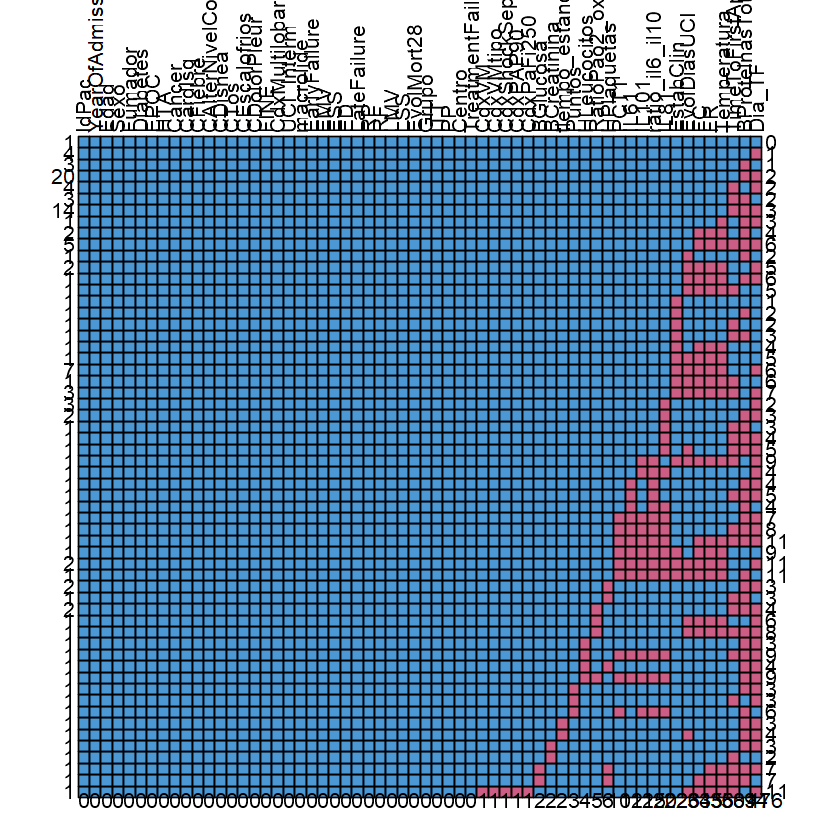

In [29]:
md.pattern(data_dint, rotate.names = TRUE)

In [30]:
#Test if missing values are MCAR
# mcar_test(data_dint)


Not compatible with MCAR. Let's suppose MAR

### Descriptive statistics

In [31]:
#Manually builds early and late failure
data_dint$EarlyFailureMan <- with(data_dint, factor(as.integer(EMV == 1 | ESS == 1 | ED == 1), levels = c(0,1)))
data_dint$LateFailureMan <- with(data_dint, factor(as.integer(LMV == 1 | LSS == 1 | RP == 1 | RF == 1), levels = c(0,1)))
data_dint$TreatmentFailureMan <- with(data_dint, factor(as.integer(EarlyFailureMan == 1 | LateFailureMan == 1), levels = c(0,1)))

In [32]:
#check if it matches
table(data_dint$EarlyFailure,data_dint$EarlyFailureMan)

   
      0   1
  0 108   0
  1   0  12

We good

In [33]:
table(data_dint$LateFailure,data_dint$LateFailureMan)

   
     0  1
  0 96  0
  1  9 15

Hum :(

In [34]:
table(data_dint$TreatmentFailure,data_dint$TreatmentFailureMan)

   
     0  1
  0 87  0
  1  9 24

Hum :(

In [35]:
#Compute pleural effusion
data$pleural_effusion <- with(data, factor(as.integer(!is.na(LPGlu) | !is.na(LPProt)| !is.na(LPLDH)| 
!is.na(LPCelulas)| !is.na(LPPM)), levels = c(0,1))) 
table(data$Cancer,data$Grupo)   

   
     0  1
  0 51 58
  1  8  3

In [36]:
#Test normality of numerical variables
normality <- sapply(data_dint[!names(data_dint) %in% "IdPac"],seek_normality)
data.frame(variable = names(normality), normality = normality)


,variable,normality
,<chr>,<chr>
YearOfAdmission,YearOfAdmission,NA
Edad,Edad,not normal
Sexo,Sexo,NA
Fumador,Fumador,NA
Diabetes,Diabetes,NA
EPOC,EPOC,NA
HTA,HTA,NA
Cancer,Cancer,NA
CardIsq,CardIsq,NA


In [37]:
# for (col in names(data_dint)[sapply(data_dint, is.numeric)]) {
#   cat("QQ Plot for:", col, "\n")
#   p <- ggqqplot(data_dint[[col]], title = paste("QQ Plot of", col))
#   print(p)
# }

In [38]:
#Explicit modalities of categorical variables
data_dint_explcit<-data_dint %>%
  mutate(Sexo = recode(Sexo, "1" = "Male", "0" = "Female")) %>%
  mutate(Diabetes = recode(Diabetes, "1" = "Diabetes mellitus", "0" = "Not diabetic"))%>%
  mutate(Fumador = recode(Fumador, "1" = "Current smoker", "0" = "Not smoker"))%>%
  mutate(EPOC = recode(EPOC, "1" = "Chronic pulmonary disease", "0" = "Not EPOC"))%>%
  mutate(HTA = recode(HTA, "1" = "Congestive heart failure", "0" = "Not HTA"))%>%
  mutate(Cancer = recode(Cancer, "1" = "History of malignancy", "0" = "No cancer"))%>%
  mutate(CardIsq = recode(CardIsq, "1" = "Ischemic heart disease", "0" = "No IHD"))%>%
  mutate(CFiebre = recode(CFiebre, "1" = "Fever", "0" = "No fever"))%>%
  mutate(CAlterNivelConc = recode(CAlterNivelConc, "1" = "Altered Mental status", "0" = "Not altered"))%>%
  mutate(CDisnea = recode(CDisnea, "1" = "Breathlessness", "0" = "No Breathlessness"))%>%
  mutate(CTos = recode(CTos, "1" = "Cough", "0" = "No cough"))%>%
  mutate(CEscalofrios = recode(CEscalofrios, "1" = "Chills", "0" = "No chills"))%>%
  mutate(CDolorPleur = recode(CDolorPleur, "1" = "Chest pain", "0" = "No chest pain"))%>%
  mutate(CdxVM = recode(CdxVM, "1" = "Mechanical ventialtion", "0" = "No MV"))%>%
  mutate(CdxVMtipo = recode(CdxVMtipo, "1" = "Noninvasive alone","2" = "Noninvasive followed by invasive","3" = "Invasive alone", "0" = "No MV"))%>%
  mutate(CdxShockSept = recode(CdxShockSept, "1" = "Septic shock", "0" = "No shock"))%>%
  mutate(CdxPAP90 = recode(CdxPAP90, "1" = "Systolic blood pressure< 90 mmHg", "0" = "PAP>90"))%>%
  mutate(CdxMultilobar = recode(CdxMultilobar, "1" = "Multilobar involvement", "0" = "No involvement"))%>%
  mutate(CdxPaFi250 = recode(CdxPaFi250, "1" = "Ratio of PaO2 to fraction of inspired oxygen < 250 mmHg", "0" = "Ratio>250"))%>%
  mutate(UCI_Interm = recode(UCI_Interm, "1" = "ICU admission", "0" = "No ICU admission"))%>%
  mutate(TimeToFirstAntibiotic_SS = recode(TimeToFirstAntibiotic_SS, "1" = "Within 1h in patients with septic shock", "0" = "Within 4h in patients without septic shock"))%>% 
  mutate(macrolide = recode(macrolide, "1" = " Macrolide combination therapy", "0" = "No macrolide"))%>%
  mutate(EarlyFailure = recode(EarlyFailure, "1" = "Early failure", "0" = "No early failure"))%>%
  mutate(EarlyFailureMan = recode(EarlyFailureMan, "1" = "Early failure", "0" = "No early failure"))%>%
  mutate(EMV = recode(EMV, "1" = "Early mechanical ventilation", "0" = "EVM"))%>%
  mutate(ESS = recode(ESS, "1" = "Early septic shock", "0" = "no ESS"))%>%
  mutate(ED = recode(ED, "1" = "Early death", "0" = "no ED"))%>%
  mutate(LateFailure = recode(LateFailureMan, "1" = "Late failure", "0" = "No late failure"))%>%
  mutate(LateFailureMan = recode(LateFailureMan, "1" = "Late failure", "0" = "No late failure"))%>%
  mutate(RP = recode(RP, "1" = "Radiographic progression", "0" = "no RP"))%>%
  mutate(RF = recode(RF, "1" = "Respiratory failure", "0" = "no RF"))%>%
  mutate(LMV = recode(LMV, "1" = "Late mechanical ventilation", "0" = "no LMV"))%>%
  mutate(LSS = recode(LSS, "1" = "Late septic shock", "0" = "no LSS"))%>%
  mutate(EvolMort28 = recode(EvolMort28, "1" = "In-hospitality mortality", "0" = "no IHM"))%>%
  mutate(TreatmentFailure = recode(TreatmentFailure, "1" = "Treatment failure", "0" = "No treatment failure"))%>%
  mutate(TreatmentFailureMan = recode(TreatmentFailureMan, "1" = "Treatment failure", "0" = "No treatment failure"))
#Summary of categorical variables
summary_cat_by_group(data_dint_explcit, "Grupo")

Variable,Category,Overall_N_prop,Treatment_N_prop,Placebo_N_prop
<chr>,<chr>,<chr>,<chr>,<chr>
YearOfAdmission,2004,8 ( 7 ),3 ( 5 ),5 ( 8 )
YearOfAdmission,2005,24 ( 20 ),11 ( 18 ),13 ( 22 )
YearOfAdmission,2006,21 ( 17 ),13 ( 21 ),8 ( 14 )
YearOfAdmission,2007,17 ( 14 ),10 ( 16 ),7 ( 12 )
YearOfAdmission,2008,14 ( 12 ),7 ( 11 ),7 ( 12 )
YearOfAdmission,2009,9 ( 7 ),3 ( 5 ),6 ( 10 )
YearOfAdmission,2010,13 ( 11 ),6 ( 10 ),7 ( 12 )
YearOfAdmission,2011,12 ( 10 ),7 ( 11 ),5 ( 8 )
YearOfAdmission,2012,2 ( 2 ),1 ( 2 ),1 ( 2 )


In [39]:
table(data_dint$EvolMort28, data_dint$EvolDiasUCI)

   
     0  1  2  3  4  5  6  7  8  9 10 11 13 16 20 23 35 63
  0 32  4  8  6  8  6  4  5  2  3  3  0  1  1  1  1  1  1
  1  0  1  2  0  1  0  0  1  0  0  1  1  0  0  0  0  0  0

We keep the manual construction of treatments failure

In [40]:
# #Suppress
# data_dint <- data_dint %>% select(-TreatmentFailure, -LateFailure, -EarlyFailure)

In [41]:
# Summary of numerical variables 
summary_num_by_group(data_dint[!names(data_dint) %in% "IdPac"], "Grupo")

Warning message in group_var == 1 & !is.na(x):
"la taille d'un objet plus long n'est pas multiple de la taille d'un objet plus court"
Warning message in group_var == 0 & !is.na(x):
"la taille d'un objet plus long n'est pas multiple de la taille d'un objet plus court"


Variable,Overall_mean_SD,Overall_med_IQR,Overall_min_max,Treatment_mean_SD,Treatment_med_IQR,Treatment_min_max,Placebo_mean_SD,Placebo_med_IQR,Placebo_min_max
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Edad,65.2 ( 19.6 ),69.5 ( 53 - 81 ),19 - 96,64.5 ( 19.1 ),69 ( 53 - 81 ),24 - 89,66.1 ( 20.1 ),70 ( 54.5 - 81 ),19 - 96
Puntos,108.6 ( 36.4 ),110 ( 86 - 135 ),4 - 212,107.1 ( 38.2 ),109 ( 85.8 - 134.2 ),28 - 212,110.2 ( 34.6 ),111 ( 91 - 135 ),4 - 173
RatioPao2_oxygen,232.9 ( 78.7 ),238.1 ( 179.6 - 270.5 ),63.6 - 609.5,236.2 ( 74.9 ),239 ( 210.1 - 265.6 ),63.6 - 609.5,229.6 ( 82.9 ),228.6 ( 170.5 - 287.6 ),76 - 407.5
BGlucosa,149.5 ( 72.4 ),130.5 ( 106 - 167.2 ),50 - 548,148.3 ( 78.9 ),131 ( 106 - 159 ),64 - 548,150.8 ( 65.6 ),129 ( 107 - 180 ),50 - 394.8
BCreatinina,1.6 ( 0.9 ),1.3 ( 1 - 1.8 ),0.4 - 5.2,1.5 ( 0.9 ),1.3 ( 0.9 - 1.8 ),0.6 - 4.9,1.6 ( 1 ),1.3 ( 1 - 1.8 ),0.4 - 5.2
HPlaquetas,248 ( 131.7 ),214.5 ( 175.2 - 283 ),32 - 864,235.7 ( 109.3 ),214 ( 176 - 282 ),32 - 630,260.4 ( 150.8 ),217 ( 175 - 283 ),81 - 864
HLeucocitos,15.1 ( 10.7 ),13.4 ( 9 - 19.7 ),0.7 - 74,15.3 ( 12.2 ),12.7 ( 9 - 16.7 ),1.3 - 74,14.9 ( 9 ),14.4 ( 9.2 - 23 ),0.7 - 36.7
BProteinasTot,27.8 ( 24.8 ),8.2 ( 6.6 - 56.5 ),4.9 - 69,31.2 ( 26.1 ),19.6 ( 6.3 - 57.5 ),4.9 - 69,23.4 ( 23 ),7.5 ( 6.8 - 47 ),5.2 - 58
PCT1,6.3 ( 11.8 ),1.8 ( 0.5 - 7.2 ),0 - 86.3,6 ( 14.2 ),1.2 ( 0.4 - 4.4 ),0 - 86.3,6.7 ( 8.6 ),3.1 ( 0.8 - 9.5 ),0.1 - 37.4


### Intention to treat

#### Comparison tests

In [42]:
compare_var_cat(data_dint[!names(data_dint) %in% "IdPac"],"Grupo")

Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingenc

Variable,Test,P_value,Verdict
<chr>,<chr>,<dbl>,<chr>
YearOfAdmission,Fisher,0.886,No significative difference
Sexo,Chi2,0.427,No significative difference
Fumador,Chi2,0.872,No significative difference
Diabetes,Chi2,0.580,No significative difference
EPOC,Chi2,0.280,No significative difference
HTA,Chi2,0.740,No significative difference
Cancer,Chi2,0.186,No significative difference
CardIsq,Chi2,0.692,No significative difference
CFiebre,Chi2,0.346,No significative difference


In [43]:
#Double check for septic shock
contingency <- table(data_dint$CdxShockSept, data_dint$Grupo)
print(chisq.test(contingency)$p.value)
print(fisher.test(contingency)$p.value)
# if (pval < 0.1) "associated/significative difference" else "No significative difference"

[1] 0.1178949


[1] 0.08699988


Associated/significatve difference for the the fisher test

In [44]:
compare_var_num(data_dint[!names(data_dint) %in% "IdPac"], "Grupo")

Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
"impossible de calculer la p-value exacte avec des ex-aequos"
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
"impossible de calculer la p-value exacte avec des ex-aequos"
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
"impossible de calculer la p-value exacte avec des ex-aequos"
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
"impossible de calculer la p-value exacte avec des ex-aequos"
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
"impossible de calculer la p-value exacte avec des ex-aequos"
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
"impossible de calculer la p-value exacte avec des ex-aequos"


Variable,test,pvalue,verdict
<chr>,<chr>,<dbl>,<chr>
Edad,Mann-Whitney,0.592,No significative difference
Puntos,Student,0.652,No significative difference
RatioPao2_oxygen,Mann-Whitney,0.695,No significative difference
BGlucosa,Mann-Whitney,0.620,No significative difference
BCreatinina,Mann-Whitney,0.607,No significative difference
HPlaquetas,Mann-Whitney,0.792,No significative difference
HLeucocitos,Mann-Whitney,0.485,No significative difference
BProteinasTot,Mann-Whitney,0.542,No significative difference
PCT1,Mann-Whitney,0.040,associated/significative difference


In [45]:
#Compare proportions
compare_proportions(data_dint[!names(data_dint) %in% "IdPac"], c("TreatmentFailureMan"
                                ,"EarlyFailureMan","EMV","ESS","ED",
                                "LateFailureMan","RP","RF","LMV","LSS"),
                                 "Grupo")

Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"


Variable,P_value,Difference_CI
<chr>,<dbl>,<chr>
TreatmentFailureMan,0.02,17 (3–31)
EarlyFailureMan,0.95,0 (-10–11)
EMV,0.69,2 (-8–11)
ESS,0.62,2 (-5–9)
ED,0.97,0 (-6–7)
LateFailureMan,0.00,22 (11–33)
RP,0.01,14 (4–23)
RF,0.09,7 (-1–15)
LMV,0.16,5 (-2–12)


In [46]:
compare_medians(data_dint[!names(data_dint) %in% "IdPac"], c("tiempo_estancia","EstabClin"),"Grupo")

Variable,Median_Diff,CI_95,P_value
<chr>,<dbl>,<chr>,<dbl>
tiempo_estancia,0.5,-2.5 – 3,0.8311
EstabClin,-1.0,-2 – 1,0.2769


In [47]:
group0 <- data_dint[data_dint[["Grupo"]] == 0 & data_dint$EvolDiasUCI>0, "EvolDiasUCI", drop = TRUE]
group1 <- data_dint[data_dint[["Grupo"]] == 1 & data_dint$EvolDiasUCI>0, "EvolDiasUCI", drop = TRUE]
    
    # Remove NA
group0 <- group0[!is.na(group0)]
group1 <- group1[!is.na(group1)]
if (length(group0) == 0 || length(group1) == 0) return(NULL)

    # Median difference
diff_median <- round(median(group1) - median(group0), 2)
    
    # P-value
p_val <- round(wilcox.test(group0, group1, exact = FALSE)$p.value, 4)
    
    # Bootstrap CI for median difference
boot_diffs <- replicate(1000, {
      med1 <- median(sample(group1, replace = TRUE))
      med0 <- median(sample(group0, replace = TRUE))
      med1 - med0
    })
    
ci <- quantile(boot_diffs, probs = c((1 - 0.95)/2, 1 - (1 - 0.95)/2))
ci_str <- paste0(round(ci[1], 2), " – ", round(ci[2], 2))
    
data.frame(
      Variable = "EvolDiasUCI",
      Median_Diff = diff_median,
      CI_95 = ci_str,
      P_value = p_val,
      stringsAsFactors = FALSE
    )

Variable,Median_Diff,CI_95,P_value
<chr>,<dbl>,<chr>,<dbl>
EvolDiasUCI,-1,-3 – 2,0.7017


In [48]:
# p<-CorrelationsStudy(data)$num_correlation_heatmap()
# ggsave("numassoc_heatmap.png", p, width = 24, height = 12)

In [49]:
# p<-CorrelationsStudy(data)$cat_correlation_heatmap()
# ggsave("catassoc_heatmap.png", p, width = 24, height = 12)

Significative difference for procalcitonin, IL-10 and septic shock


### Sensitivity analysis

In [ ]:
#Imputation
vars_to_impute<-caracs_dint[caracs_dint$number_of_missing_values>0,"variable"]
print(caracs_dint[caracs_dint$number_of_missing_values>0,"variable"])


 [1] "Puntos"                   "CdxVM"                   
 [3] "CdxVMtipo"                "CdxShockSept"            
 [5] "CdxPAP90"                 "CdxPaFi250"              
 [7] "RatioPao2_oxygen"         "TimeToFirstAntibiotic_SS"
 [9] "BGlucosa"                 "BCreatinina"             
[11] "HPlaquetas"               "HLeucocitos"             
[13] "BProteinasTot"            "PCT1"                    
[15] "IL61"                     "IL81"                    
[17] "IL101"                    "Temperatura"             
[19] "FR"                       "FC"                      
[21] "tiempo_estancia"          "EvolDiasUCI"             
[23] "EstabClin"                "Dia_TF"                  
[25] "ratio_il6_il10"          


In [ ]:
#Prepare variables
## Treatment failure
data_dint$TreatmentFailureMan <- as.numeric(as.character(data_dint$TreatmentFailureMan))
data_dint$Dia_TF[is.na(data_dint$Dia_TF)] <- 5 #Censor at 5 days

##Length of stay in hospital
data_dint$StayHosp <- as.numeric(as.character(ifelse(is.na(data_dint$tiempo_estancia),0,1)))

##Time in ICU
data_dint$EvolDiasUCI[is.na(data_dint$EvolDiasUCI)] <- data$EvolDiasInterm[is.na(data$EvolDiasUCI)]
data_dint$EvolDiasUCI[is.na(data_dint$EvolDiasUCI)] <- data_dint$tiempo_estancia[is.na(data_dint$EvolDiasUCI)]
data_dint$EvolDiasUCI[data_dint$UCI_Interm==0] <- 0
data_dint$EvolDiasUCI_tronq<-data_dint$EvolDiasUCI
data_dint$EvolDiasUCI_tronq[data_dint$UCI_Interm==1]<-ifelse(data_dint$EvolDiasUCI[data_dint$UCI_Interm==1]>28 | data_dint$EvolMort28[data_dint$UCI_Interm==1]==1,28,data_dint$EvolDiasUCI[data_dint$UCI_Interm==1]) #truncate at 28 days
data_dint$UCI_event<- as.numeric(as.character(ifelse(is.na(data$EvolUCIFechaAlta) | is.na(data$EvolIntermFechaAlta),0,1)))

## Clinical stability
data_dint$EstabClin_event <- as.numeric(as.character(ifelse(is.na(data_dint$EstabClin),0,1)))
data_dint$EstabClin[is.na(data_dint$EstabClin)] <- data_dint$tiempo_estancia[is.na(data_dint$EstabClin)]

In [ ]:
data_dint[data_dint$EvolMort28==1,"UCI_event"]

UCI_event
<dbl>
0
0
0
0
0
0
0
0
0


In [ ]:
data_dint$EvolDiasUCI[data_dint$EvolDiasUCI>28]

[1] NA 35 63

In [ ]:
# List of all column names
all_vars <- names(data_dint[!names(data_dint) %in% "IdPac"])

# Create a method vector with empty strings
meth <- rep("", length(all_vars))
names(meth) <- all_vars

# Set "pmm" only for the 3 target columns
meth[c("PCT1", "IL101","CdxShockSept")] <- "pmm"

# Run mice with the method vector
imp <- mice(data_dint[!names(data_dint) %in% "IdPac"], m = 5, method = meth, seed = 123)


 iter imp variable
  1   1  CdxShockSept  PCT1  IL101
  1   2  CdxShockSept  PCT1  IL101
  1   3  CdxShockSept  PCT1  IL101
  1   4  CdxShockSept  PCT1  IL101
  1   5  CdxShockSept  PCT1  IL101
  2   1  CdxShockSept  PCT1  IL101
  2   2  CdxShockSept  PCT1  IL101
  2   3  CdxShockSept  PCT1  IL101
  2   4  CdxShockSept  PCT1  IL101
  2   5  CdxShockSept  PCT1  IL101
  3   1  CdxShockSept  PCT1  IL101
  3   2  CdxShockSept  PCT1  IL101
  3   3  CdxShockSept  PCT1  IL101
  3   4  CdxShockSept  PCT1  IL101
  3   5  CdxShockSept  PCT1  IL101
  4   1  CdxShockSept  PCT1  IL101
  4   2  CdxShockSept  PCT1  IL101
  4   3  CdxShockSept  PCT1  IL101
  4   4  CdxShockSept  PCT1  IL101
  4   5  CdxShockSept  PCT1  IL101
  5   1  CdxShockSept  PCT1  IL101
  5   2  CdxShockSept  PCT1  IL101
  5   3  CdxShockSept  PCT1  IL101
  5   4  CdxShockSept  PCT1  IL101
  5   5  CdxShockSept  PCT1  IL101


Warning message:
"Number of logged events: 4"


#### Logistic regresion

In [ ]:

# Variables to explain
vars_to_explain <- c("TreatmentFailureMan",
                     "EarlyFailureMan","EMV","ESS","ED",
                     "LateFailureMan","RP","RF","LMV","LSS","EvolMort28")

# Function to extract OR, CI, and p-value from a glm fit inside mice object
extract_stats <- function(pooled_fit) {
  tidy_fit <- tidy(pooled_fit, conf.int = TRUE, exponentiate = TRUE)
  grupo_row <- tidy_fit[2,]
  
  if (nrow(grupo_row) == 0) {
    or_ci <- NA
    p_val <- NA
  } else {
    or <- round(grupo_row$estimate, 2)
    ci_lower <- round(grupo_row$conf.low, 2)
    ci_upper <- round(grupo_row$conf.high, 2)
    p_val <- grupo_row$p.value
    or_ci <- paste0(or, " (", ci_lower, " - ", ci_upper, ")")
  }
  
  list(or_ci = or_ci, p_val = p_val)
}

results_list <- map(vars_to_explain, function(var) {
  # formula for first regression: outcome ~ Grupo
  fit1 <- with(imp, glm(as.formula(paste(var, "~ Grupo")), family = binomial))
  
  # formula for second regression: outcome ~ Grupo + IL101 + PCT1 + Centro + YearOfAdmission
  fit2 <- with(imp, glm(as.formula(paste(var, "~ Grupo + IL101 + PCT1 + CdxShockSept+ Centro + YearOfAdmission")), family = binomial))
  
  # Pool results and extract stats
  pool1 <- pool(fit1)
  pool2 <- pool(fit2)
  
  stats1 <- extract_stats(pool1)
  stats2 <- extract_stats(pool2)
  
  data.frame(
    Variable_to_explain = var,
    OR_CI_not_adjusted = stats1$or_ci,
    p_value_1 = stats1$p_val,
    OR_CI_adjusted = stats2$or_ci,
    p_value_2 = stats2$p_val,
    stringsAsFactors = FALSE
  )
})

# Combine all into one dataframe
results_df_log <- bind_rows(results_list)
results_df_log


Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: des probabilités ont été ajustées numé

Variable_to_explain,OR_CI_not_adjusted,p_value_1,OR_CI_adjusted,p_value_2
<chr>,<chr>,<dbl>,<chr>,<dbl>
TreatmentFailureMan,0.32 (0.12 - 0.85),0.022941429,0.24 (0.07 - 0.78),0.018394660
EarlyFailureMan,0.96 (0.29 - 3.22),0.951568231,1.13 (0.24 - 5.35),0.872723966
EMV,0.76 (0.19 - 3.02),0.691642954,0.82 (0.13 - 5.25),0.831956379
ESS,0.63 (0.1 - 4.01),0.624227646,0 (0 - 123425.5),0.203536341
ED,0.97 (0.13 - 7.24),0.973010054,9.01 (0.01 - 10463.37),0.537662368
LateFailureMan,0.05 (0.01 - 0.43),0.006378337,0.03 (0 - 0.35),0.005196135
RP,0.09 (0.01 - 0.77),0.028254932,0.06 (0.01 - 0.65),0.020701023
RF,0.18 (0.02 - 1.63),0.125499406,0.13 (0.01 - 1.35),0.085992680
LMV,0.23 (0.02 - 2.16),0.196175133,0.13 (0.01 - 1.55),0.105963253


Goodness of fit

In [ ]:
library(pROC)
library(ResourceSelection)

Warning message:
"le package 'pROC' a été compilé avec la version R 4.2.3"
Type 'citation("pROC")' for a citation.


Attachement du package : 'pROC'


Les objets suivants sont masqués depuis 'package:stats':

    cov, smooth, var


Warning message:
"le package 'ResourceSelection' a été compilé avec la version R 4.2.3"
ResourceSelection 0.3-6 	 2023-06-27



In [ ]:

# fit1 <- with(data_dint, glm(LateFailureMan ~ Grupo, family = binomial))

# # Use predicted probabilities (not 0/1 classification)
# yhat <- fitted(fit1)

# # True labels
# ytrue <- as.numeric(as.character(data_dint$LateFailureMan))

# # Perform Hosmer-Lemeshow test
# hoslem.test(x = ytrue, y = yhat, g = 10)


In [ ]:

# Function to extract model performances
extract_performance <- function(fit,var) {
    pred_list <- lapply(fit$analyses, function(model) {
        predict(model, type = "response")
        })
    # Average predicted probabilities across imputations
    avg_probs <- Reduce("+", pred_list) / length(pred_list)
    # Actual values from the original data used for imputation
    actuals_f <- factor(imp$data[[var]],levels = c(0,1))
    avg_probs <- avg_probs[!is.na(actuals_f)]
    preds_f <- factor(ifelse(avg_probs >= 0.5, 1, 0), levels = c(0,1))
    # Confusion matrix anc ROC curve
    cm<-confusionMatrix(data = preds_f, reference = actuals_f, positive = "1")
    # roc_obj <- roc(actuals_f, avg_probs)
    #Deviance residuals
    residuals_list <- lapply(fit$analyses, function(mod) residuals(mod, type = "deviance"))
    residuals_matrix <- do.call(cbind, residuals_list)
    number_deviant_residuals <- length(unique(c(as.numeric(which(abs(residuals_list[[1]]) > 2)),
                                                as.numeric(which(abs(residuals_list[[2]]) > 2)),
                                                as.numeric(which(abs(residuals_list[[3]]) > 2)),
                                                as.numeric(which(abs(residuals_list[[4]]) > 2)),
                                                as.numeric(which(abs(residuals_list[[5]]) > 2)) 
                                                )))




    #Model performances
    accuracy <-as.numeric(cm$overall["Accuracy"])
    sensitivity <- as.numeric(cm$byClass["Sensitivity"])
    specificity <- as.numeric(cm$byClass["Specificity"])
    # auc <- as.numeric(auc(roc_obj))
    number_deviant_residuals<-number_deviant_residuals
    #predicted proportions vs true proportions
    diff_prop_placebo<-round((prop.table(table(imp$data[["Grupo"]], actuals_f), margin=1)[3] - prop.table(table(imp$data[["Grupo"]], preds_f),margin=1)[3])*100,2)
    diff_prop_traitement<-round((prop.table(table(imp$data[["Grupo"]], actuals_f), margin=1)[4] - prop.table(table(imp$data[["Grupo"]], preds_f),margin=1)[4])*100,2)

  list(accuracy = accuracy,
  sensitivity = sensitivity,
  specificity = specificity,
  # auc = auc,
  diff_prop_placebo =diff_prop_placebo,
  diff_prop_traitement = diff_prop_traitement,
  number_deviant_residuals=number_deviant_residuals)
}

results_list <- map(vars_to_explain, function(var) {
  # formula for first regression: outcome ~ Grupo
  fit1 <- with(imp, glm(as.formula(paste(var, "~ Grupo")), family = binomial))
  
  # formula for second regression: outcome ~ Grupo + IL101 + PCT1 + Centro + YearOfAdmission
  fit2 <- with(imp, glm(as.formula(paste(var, "~ Grupo + IL101 + PCT1 + CdxShockSept+ Centro + YearOfAdmission")), family = binomial))

  perf1 <- extract_performance(fit1,var)
  perf2 <- extract_performance(fit2,var)
  data.frame(
    Variable_to_explain = var,
    accuracy = perf1$accuracy,
    sensitivity = perf1$sensitivity,
    specificity = perf1$specificity,
    diff_prop_placebo = perf1$diff_prop_placebo,
    diff_prop_traitement = perf1$diff_prop_traitement,
    # auc = perf1$auc,
    number_deviant_residuals= perf1$number_deviant_residuals,
    accuracy_adjusted = perf2$accuracy,
    sensitivity_adjusted = perf2$sensitivity,
    specificity_adjusted = perf2$specificity,
    diff_prop_placebo = perf2$diff_prop_placebo,
    diff_prop_traitement = perf2$diff_prop_traitement,
    # auc_adjusted = perf2$auc,
    number_deviant_residuals_adjusted= perf2$number_deviant_residuals,
    stringsAsFactors = FALSE
  )
})

# Combine all into one dataframe
results_df <- bind_rows(results_list)
t(results_df)


Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: des probabilités ont été ajustées numé

Variable_to_explain,TreatmentFailureMan,EarlyFailureMan,EMV,ESS,ED,LateFailureMan,RP,RF,LMV,LSS,EvolMort28
accuracy,0.8000000,0.9000000,0.9250000,0.9583333,0.9666667,0.8750000,0.9166667,0.9500000,0.9583333,0.9666667,0.8750000
sensitivity,0,0,0,0,0,0,0,0,0,0,0
specificity,1,1,1,1,1,1,1,1,1,1,1
diff_prop_placebo,28.81,10.17,8.47,5.08,3.39,23.73,15.25,8.47,6.78,6.78,15.25
diff_prop_traitement,11.48,9.84,6.56,3.28,3.28,1.64,1.64,1.64,1.64,0.00,9.84
number_deviant_residuals,7,12,9,5,4,1,1,6,5,4,6
accuracy_adjusted,0.7570093,0.8971963,0.9252336,0.9252336,0.9626168,0.8504673,0.9065421,0.9439252,0.9532710,0.9439252,0.8598131
sensitivity_adjusted,0.08695652,0.00000000,0.00000000,0.00000000,0.25000000,0.21428571,0.00000000,0.00000000,0.00000000,0.00000000,0.13333333
specificity_adjusted,0.9404762,1.0000000,1.0000000,0.9705882,0.9902913,0.9462366,0.9897959,1.0000000,1.0000000,0.9805825,0.9782609
diff_prop_placebo.1,26.89,10.17,8.47,5.08,-0.46,17.96,15.25,8.47,6.78,6.78,9.49


The models can predict who won't have an outcomme but cannot predict who will.

In [ ]:
fit <- with(imp, glm(as.formula(paste("TreatmentFailureMan", "~ Grupo+ IL101 + PCT1 + CdxShockSept+ Centro + YearOfAdmission")), family = binomial))
pred_list <- lapply(fit$analyses, function(model) {
predict(model, type = "response")
        })
# Average predicted probabilities across imputations
avg_probs <- Reduce("+", pred_list) / length(pred_list)
actuals_f <- factor(imp$data[["TreatmentFailureMan"]],levels = c(0,1))
avg_probs <- avg_probs[!is.na(actuals_f)]
preds_f <- factor(ifelse(avg_probs >= 0.5, 1, 0), levels = c(0,1))
# Confusion matrix anc ROC curve
cm<-confusionMatrix(data = preds_f, reference = actuals_f, positive = "1")

In [ ]:
prop.table(table(data_dint$Grupo, actuals_f), margin=1)

   actuals_f
            0         1
  0 0.7118644 0.2881356
  1 0.8852459 0.1147541

In [ ]:
prop.table(table(data_dint$Grupo, actuals_f), margin=1)[3]

[1] 0.2881356

In [ ]:
prop.table(table(data_dint$Grupo, preds_f),margin=1)

   preds_f
             0          1
  0 0.98076923 0.01923077
  1 0.89090909 0.10909091

In [ ]:
table(preds_f, actuals_f)

       actuals_f
preds_f  0  1
      0 79 21
      1  5  2

In [ ]:
cm

Confusion Matrix and Statistics

          Reference
Prediction  0  1
         0 79 21
         1  5  2
                                          
               Accuracy : 0.757           
                 95% CI : (0.6646, 0.8347)
    No Information Rate : 0.785           
    P-Value [Acc > NIR] : 0.797021        
                                          
                  Kappa : 0.0367          
                                          
 Mcnemar's Test P-Value : 0.003264        
                                          
            Sensitivity : 0.08696         
            Specificity : 0.94048         
         Pos Pred Value : 0.28571         
         Neg Pred Value : 0.79000         
             Prevalence : 0.21495         
         Detection Rate : 0.01869         
   Detection Prevalence : 0.06542         
      Balanced Accuracy : 0.51372         
                                          
       'Positive' Class : 1               
                                    

In [ ]:
cm$byClass["Pos Pred Value"]

Pos Pred Value 
     0.2857143

Instead of modelling for each item of treatment failure, let's model effect of treatment on severity of treatment failure

In [ ]:
data_dint <- data_dint %>%
  mutate(SeveryOfFailure = case_when(
    ED == 1 | ESS == 1 | LSS == 1 ~ "Fatal",
    EMV == 1 | LMV == 1 | RF == 1|RP==1 ~ "Severe",
    TRUE                        ~ "No outcome"
  ))
prop.table(table(data_dint$SeveryOfFailure))


     Fatal No outcome     Severe 
0.09166667 0.80000000 0.10833333 

In [ ]:
table(data_dint$SeveryOfFailure, data_dint$Grupo)

            
              0  1
  Fatal       8  3
  No outcome 42 54
  Severe      9  4

In [ ]:
prop.table(table(data_dint$SeveryOfFailure, data_dint$Grupo),margin=2)

            
                      0          1
  Fatal      0.13559322 0.04918033
  No outcome 0.71186441 0.88524590
  Severe     0.15254237 0.06557377

In [ ]:

# Fit proportional odds model
model <- polr(as.factor(SeveryOfFailure) ~ Grupo, data = data_dint, method = "logistic")

# Brant test
brant(model)


-------------------------------------------- 
Test for	X2	df	probability 
-------------------------------------------- 
Omnibus		5.19	1	0.02
Grupo1		5.19	1	0.02
-------------------------------------------- 

H0: Parallel Regression Assumption holds


Model is not PO

In [ ]:
library(VGAM)

Warning message:
"le package 'VGAM' a été compilé avec la version R 4.2.3"
Le chargement a nécessité le package : stats4


Attachement du package : 'VGAM'


L'objet suivant est masqué depuis 'package:caret':

    predictors


Les objets suivants sont masqués depuis 'package:lava':

    constraints, logit, multinomial


L'objet suivant est masqué depuis 'package:DescTools':

    Rank




In [ ]:
# Fit gologit (partial proportional odds) model

data_dint$SeveryOfFailure <- ordered(data_dint$SeveryOfFailure, levels = c("No outcome", "Severe", "Fatal"))
model <- vglm(SeveryOfFailure ~ Grupo, family = cumulative(parallel = FALSE), data = data_dint)

# Coefficients and standard errors
coefs <- coef(model)
se <- sqrt(diag(vcov(model)))

# Compute statistics
z <- coefs / se                         # z-statistics
pvals <- 2 * (1 - pnorm(abs(z)))        # two-tailed p-values
or <- exp(coefs)                        # odds ratios
lower <- exp(coefs - 1.96 * se)         # 95% CI lower
upper <- exp(coefs + 1.96 * se)         # 95% CI upper

# Combine in a data frame
results <- data.frame(
  Term = names(coefs),
  OR = round(or, 3),
  CI_lower = round(lower, 3),
  CI_upper = round(upper, 3),
  p_value = signif(pvals, 3)
)

print(results)



                       Term    OR CI_lower CI_upper  p_value
(Intercept):1 (Intercept):1 2.471    1.406    4.340 1.65e-03
(Intercept):2 (Intercept):2 6.375    3.025   13.433 1.11e-06
Grupo1:1           Grupo1:1 3.122    1.186    8.222 2.12e-02
Grupo1:2           Grupo1:2 3.033    0.764   12.045 1.15e-01


In [ ]:
# Fit multinomial model
data_dint$SeveryOfFailure <- ordered(data_dint$SeveryOfFailure, levels = c("No outcome", "Severe", "Fatal"))
model <- multinom(SeveryOfFailure ~ Grupo, data = data_dint)
tidy(model, exponentiate = TRUE, conf.int = TRUE)



# weights:  9 (4 variable)
initial  value 131.833475 
iter  10 value 73.699185
iter  10 value 73.699185
final  value 73.699185 
converged


y.level,term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Severe,(Intercept),0.2142846,0.3673158,-4.193804,2.743156e-05,0.10431125,0.4402007
Severe,Grupo1,0.3456852,0.6351665,-1.672360,9.445341e-02,0.09954651,1.2004261
Fatal,(Intercept),0.1904740,0.3857598,-4.298633,1.718550e-05,0.08942858,0.4056907
Fatal,Grupo1,0.2916692,0.7075759,-1.741347,8.162282e-02,0.07287874,1.1672941


Results for multinomial regressions are not significative at a 5% level

In [ ]:
#Create a table of counts and risks for severity of treatment failure
risk_table<-data_dint %>%
  group_by(Grupo) %>%
  summarise(
    n = n(),
    FatalCount = sum(SeveryOfFailure=="Fatal"),
    SevereCount = sum(SeveryOfFailure=="Severe"),
    NoOutcomeCount = sum(SeveryOfFailure=="No outcome"),
    FatalRisk = FatalCount / n,
    SevereOrFatalRisk = SevereCount / n,
    NoOutcomeRisk = NoOutcomeCount / n
  )


In [ ]:
relative_risk<-function(risk_table,severity){
  #' For a particular severity of treatment failure, compute relative risk between placebo and treatment group, 95% CI of the RR, odds ratios, 95% CI of the OR
  #' and p-value of the test comparing RR to 1.
  #' @param risk_table table with counts and risks for each severity case
  #' @param severity the severity case of interest
  #' @return A data frame with the variables names and the differents calculations

    # Extract counts
    risk_table <- risk_table %>% arrange(Grupo)
    n0 <- risk_table$n[1]     # Placebo
    n1 <- risk_table$n[2]     # Treatment

    if (severity=="fatal"){
        a <- risk_table$FatalCount[2]
        b <- risk_table$FatalCount[1]
    }
    else if(severity=="severe"){
        a <- risk_table$SevereCount[2]
        b <- risk_table$SevereCount[1]
    }
    else {
        a <- risk_table$NoOutcomeCount[2]
        b <- risk_table$NoOutcomeCount[1]
    }
    c <- n1 - a
    d <- n0 - b

    # Relative Risk
    RR <- (a / n1) / (b / n0)

    # Standard error of log(RR)
    se_log_rr <- sqrt((1 / a) - (1 / n1) + (1 / b) - (1 / n0))

    # 95% CI
    lower_CI <- exp(log(RR) - 1.96 * se_log_rr)
    upper_CI <- exp(log(RR) + 1.96 * se_log_rr)
    table <- matrix(c(a, c, b, d), nrow = 2, byrow = TRUE)
    fish<-fisher.test(table)
    results <- data.frame(
    Severity = severity,
    RR = round(RR,3),
    CI_RR = paste0(as.character(round(lower_CI,3)), " - ",as.character(round(upper_CI,3))),
    OR=round(fish$estimate,3),
    CI_OR = paste0(as.character(round(fish$conf.int[1],3)), " - ",as.character(round(fish$conf.int[2],3))),
    p_value = fish$p.value,
    stringsAsFactors = FALSE
  )
    return(results)
}

In [ ]:
relative_risk(risk_table, "fatal")

,Severity,RR,CI_RR,OR,CI_OR,p_value
,<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>
odds ratio,fatal,0.363,0.101 - 1.302,0.333,0.054 - 1.48,0.1226216


In [ ]:
relative_risk(risk_table, "severe")

,Severity,RR,CI_RR,OR,CI_OR,p_value
,<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>
odds ratio,severe,0.43,0.14 - 1.32,0.393,0.083 - 1.514,0.1502444


In [ ]:
relative_risk(risk_table, "no outcome")

,Severity,RR,CI_RR,OR,CI_OR,p_value
,<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>
odds ratio,no outcome,1.244,1.033 - 1.497,3.093,1.095 - 9.674,0.02246713


In [ ]:
relative_risk_within<-function(risk_table,severity){
  #' For a particular severity of treatment failure, compute relative risk between severity and no outcome, 95% CI of the RR, and p-value of the test comparing RR to 1.
  #' @param risk_table table with counts and risks for each severity case
  #' @param severity the severity case of interest
  #' @return A data frame with the treatment group and the differents calculations  

    # Extract counts
    risk_table <- risk_table %>% arrange(Grupo)
    n0 <- risk_table$n[1]     # Placebo
    n1 <- risk_table$n[2]     # Treatment

    if (severity=="fatal"){
        a_t <- risk_table$FatalCount[2]
        b_t <- risk_table$NoOutcomeCount[2]
        a_p <- risk_table$FatalCount[1]
        b_p <- risk_table$NoOutcomeCount[1]
    }
    else if(severity=="severe"){
        a_t <- risk_table$SevereCount[2]
        b_t <- risk_table$NoOutcomeCount[2]
        a_p <- risk_table$SevereCount[1]
        b_p <- risk_table$NoOutcomeCount[1]
    }
    # Relative Risk
    RR_within_t<- a_t / b_t
    RR_within_p<- a_p / b_p

    # Standard error of log(RR)
    se_log_rr_within_t <- sqrt((1 / a_t) + (1 / b_t))
    se_log_rr_within_p <- sqrt((1 / a_p) + (1 / b_p))

    # 95% CI
    lower_CI_t <- exp(log(RR_within_t) - 1.96 * se_log_rr_within_t)
    upper_CI_t <- exp(log(RR_within_t) + 1.96 * se_log_rr_within_t)
    lower_CI_p <- exp(log(RR_within_p) - 1.96 * se_log_rr_within_p)
    upper_CI_p <- exp(log(RR_within_p) + 1.96 * se_log_rr_within_p)
    observed_t <- c(a_t, b_t)
    observed_p <- c(a_t, b_p)
    
    results <- data.frame(
    Treatment = c("Treatment","Placebo"),
    RR = c(round(RR_within_t,3),round(RR_within_p,3)),
    pvalue=c(round(chisq.test(x = observed_t, p = c(0.5, 0.5))$p.value,3),
            round(chisq.test(x = observed_p, p = c(0.5, 0.5))$p.value,3)
            ),
    CI = c(paste0(as.character(round(lower_CI_t,3)), " - ",as.character(round(upper_CI_t,3))),
            paste0(as.character(round(lower_CI_p,3)), " - ",as.character(round(upper_CI_p,3)))
    ),
    stringsAsFactors = FALSE
  )
    return(results)
}

In [ ]:
relative_risk_within(risk_table,"fatal")

Treatment,RR,pvalue,CI
<chr>,<dbl>,<dbl>,<chr>
Treatment,0.056,0,0.017 - 0.178
Placebo,0.190,0,0.089 - 0.406


In [ ]:
relative_risk_within(risk_table,"severe")

Treatment,RR,pvalue,CI
<chr>,<dbl>,<dbl>,<chr>
Treatment,0.074,0,0.027 - 0.205
Placebo,0.214,0,0.104 - 0.44


#### log-rank test and Cox model

In [ ]:
library(survival)
library(survminer)


Attachement du package : 'survival'


L'objet suivant est masqué depuis 'package:caret':

    cluster


Warning message:
"le package 'survminer' a été compilé avec la version R 4.2.3"

Attachement du package : 'survminer'


L'objet suivant est masqué depuis 'package:survival':

    myeloma


L'objet suivant est masqué depuis 'package:lava':

    %++%




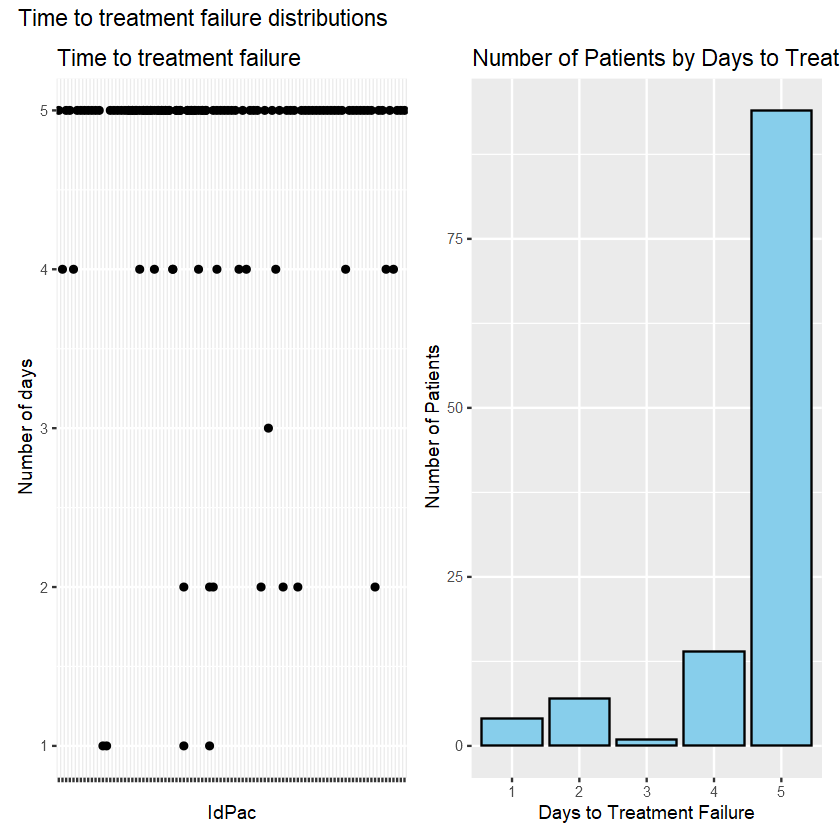

In [ ]:
#Graphicaly assert nature of data
# p1 in ggplot2
p1 <- ggplot(data_dint[!is.na(data_dint$Dia_TF), ], aes(x = factor(IdPac), y = Dia_TF)) +
  geom_point() +
  labs(title = "Time to treatment failure", x = "IdPac", y = "Number of days") +
  theme(axis.text.x = element_blank())

# p2 in ggplot2
p2 <- ggplot(data_dint[!is.na(data_dint$Dia_TF), ], aes(x = factor(Dia_TF))) +
  geom_bar(fill = "skyblue", color = "black") +
  labs(title = "Number of Patients by Days to Treatment Failure",
       x = "Days to Treatment Failure",
       y = "Number of Patients")

# Combine with patchwork
(p1 | p2) + plot_annotation(title = "Time to treatment failure distributions")


In [ ]:
mean(data$Dia_TF, na.rm=TRUE)

[1] 2.961538

In [ ]:
var(data$Dia_TF, na.rm=TRUE)

[1] 1.478462

In [ ]:
model <- glm(Dia_TF ~ Grupo , family = poisson(), data = data_dint)

# Calculate dispersion statistic
dispersion <- sum(residuals(model, type = "pearson")^2) / model$df.residual
dispersion


[1] 0.2242515

Under dispersion

In [ ]:
# #Estimating time to treatment failure with doble poisson...
# db_model <- with(imp, gamlss(Dia_TF ~Grupo, family = DPO))
# summary(db_model)

In [ ]:
#...then quasi poisson
qp_model <- with(imp, glm(Dia_TF ~Grupo, family  = quasipoisson(link = "log")))
summary(pool(qp_model))

term,estimate,std.error,statistic,df,p.value
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),1.49461659,0.02920047,51.184675,116.0379,1.765297e-81
Grupo1,0.04348379,0.04052512,1.073008,116.0379,2.854939e-01


In [ ]:
# model <- with(imp, gamlss(Dia_TF ~Grupo + IL101 + PCT1 + CdxShockSept+ Centro + YearOfAdmission, family = DPO))
# summary(model)

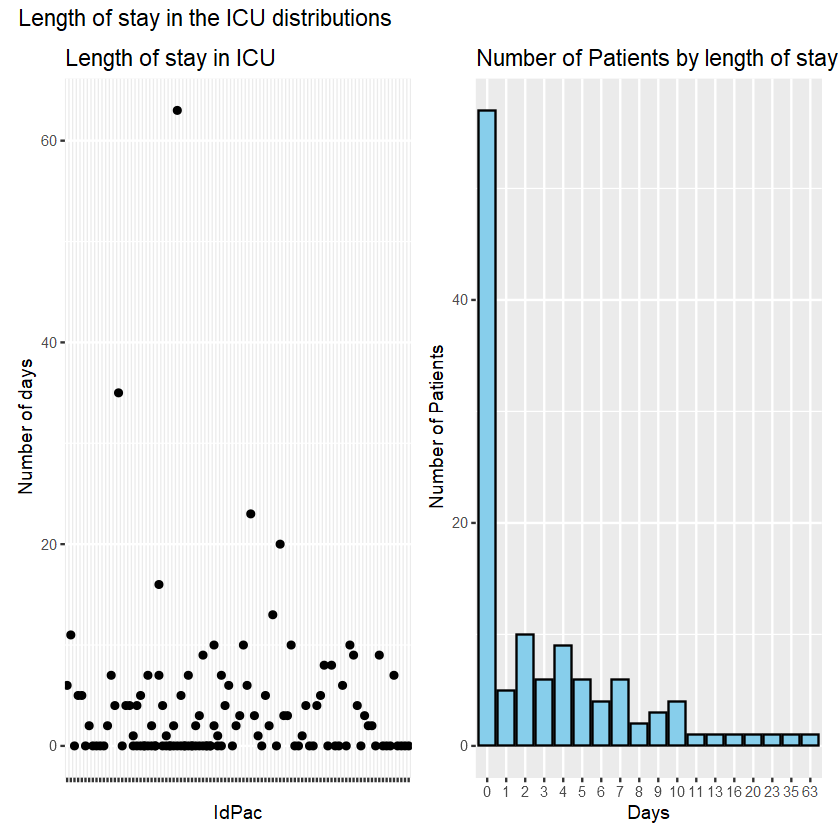

In [ ]:
#Graphicaly assert nature of data
# p1 in ggplot2
p1 <- ggplot(data_dint[!is.na(data_dint$EvolDiasUCI), ], aes(x = factor(IdPac), y = EvolDiasUCI)) +
  geom_point() +
  labs(title = "Length of stay in ICU", x = "IdPac", y = "Number of days") +
  theme(axis.text.x = element_blank())

# p2 in ggplot2
p2 <- ggplot(data_dint[!is.na(data_dint$EvolDiasUCI), ], aes(x = factor(EvolDiasUCI))) +
  geom_bar(fill = "skyblue", color = "black") +
  labs(title = "Number of Patients by length of stay in the ICU",
       x = "Days",
       y = "Number of Patients")

# Combine with patchwork
(p1 | p2) + plot_annotation(title = "Length of stay in the ICU distributions")


In [ ]:
#Evaluate dispersion
print(mean(data$EvolDiasUCI, na.rm=TRUE))
print(var(data$EvolDiasUCI, na.rm=TRUE))

[1] 4.670213


[1] 66.89007


With have an overdispersion

In [ ]:
#negative binomial to estimate los in ICU
nb_model <- with(imp,glm.nb(EvolDiasUCI ~Grupo))
summary(pool(nb_model))

term,estimate,std.error,statistic,df,p.value
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),1.3605419,0.2445665,5.5630759,115.0385,1.750274e-07
Grupo1,-0.1125522,0.3451637,-0.3260835,115.0385,7.449536e-01


In [ ]:
#negative binomial to estimate los in ICU (truncated to 28 days)
nb_model_ <- with(imp,glm.nb(EvolDiasUCI_tronq ~Grupo))
summary(pool(nb_model_), conf.int=TRUE)

term,estimate,std.error,statistic,df,p.value,2.5 %,97.5 %
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),1.8057849,0.2500329,7.222190,115.0385,5.959091e-11,1.310520,2.3010502
Grupo1,-0.4840291,0.3545368,-1.365244,115.0385,1.748403e-01,-1.186296,0.2182375


In [ ]:
print(paste("Average stay of placebo group:", exp(1.8057849)))
print(paste("Average stay of treatment group:", exp(1.8057849-0.4840291)))

[1] "Average stay of placebo group: 6.08474549143833"


[1] "Average stay of treatment group: 3.74999985006631"


#### Composite likelihood

$Y \mid X = x \sim \text{Poisson}(\lambda_x)$, $x \in \{0,1\}$

where $\lambda_x$ is the Poisson parameter that depends on the value of $X$. Typically, in an exponential model:

$$
\lambda_x = \exp(\beta_0 + \beta_1 x)
$$

We consider a sample ${\{(Y_1, X_1), \ldots, (Y_n, X_n)\}}$ drawn from ${(Y, X)}$.
The associated statistical model is given by
$$
\Bigl( (\mathbb{R}_+^*)^n, \quad \mathcal{B}((\mathbb{R}_+^*)^n), \quad \{ \text{Poisson}(\lambda_x), \ \lambda_x > 0 \} \Bigr).
$$

The model is dominated by the counting measure $\delta$, and let $P_{\lambda_x}$ be the probability distribution associated with the model. Then, the density of $P_{\lambda_x}$ with respect to $\delta$ is given by:

$$
\frac{dP_{\lambda_x}}{d\delta}(y) = \frac{\lambda_x^y e^{-\lambda_x}}{y!}
$$

for $y \in \mathbb{N}$.\
a) The support of the density function does not depend on $\lambda$, and the parameter space is open.\
b) The density function is $\mathcal{C}^\infty$ (infinitely differentiable) on the interval $]0, +\infty[$.

The likelihood is given by:

$$
L(\boldsymbol{\beta}) = \prod_{i=1}^n \left( \frac{e^{-\lambda_{X_i}} \lambda_{X_i}^{Y_i}}{Y_i!} \cdot \mathbf{1}_{\mathbb{N}}(Y_i) \cdot \mathbf{1}_{\{\lambda_{X_i} > 0\}} \right)
$$
with $\lambda_{X_i} = \exp(\beta_0 + \beta_1 X_i)$.

The log-likelihood is:

$$
\ell(\boldsymbol{\beta}) = -e^{\beta_0} \sum_{i=1}^n e^{\beta_1 X_i} + \beta_0 \sum_{i=1}^n Y_i + \beta_1 \sum_{i=1}^n X_i Y_i - \sum_{i=1}^n \log(Y_i!)
$$


In [ ]:
#log-likelihood maximisation
X<-as.numeric(as.character(data_dint$Grupo[!is.na(data_dint$EvolDiasUCI_tronq) & data_dint$UCI_Interm==1]))
Y<-as.numeric(as.character(data_dint$EvolDiasUCI_tronq[!is.na(data_dint$EvolDiasUCI_tronq) & data_dint$UCI_Interm==1]))
neg_ll_poisson<-function(b){
    b0 <- b[1]
    b1 <- b[2]
    ll <- -exp(b0)*sum(exp(b1)*X) + b0*sum(Y) +b1*sum(X*Y)-sum(lgamma(Y + 1))
  return(-ll)
}
optim(par = c(0, 0), fn = neg_ll_poisson)

$par
[1]  709.7827 -708.1040

$value
[1] -253894.3

$counts
function gradient 
     269       NA 

$convergence
[1] 0

$message
NULL

Coefficients are very extreme.

Let's do it with negative binomial distribution

In [ ]:
library(maxLik)

Warning message:
"le package 'maxLik' a été compilé avec la version R 4.2.3"
Le chargement a nécessité le package : miscTools

Warning message:
"le package 'miscTools' a été compilé avec la version R 4.2.3"

Please cite the 'maxLik' package as:
Henningsen, Arne and Toomet, Ott (2011). maxLik: A package for maximum likelihood estimation in R. Computational Statistics 26(3), 443-458. DOI 10.1007/s00180-010-0217-1.

If you have questions, suggestions, or comments regarding the 'maxLik' package, please use a forum or 'tracker' at maxLik's R-Forge site:
https://r-forge.r-project.org/projects/maxlik/



$Y \mid X = x \sim \text{BN}(\mu_x,\theta)$, $x \in \{0,1\}$

where $\mu_x$ is the BN parameter that depends on the value of $X$. Typically, in an exponential model:

$$
\mu_x = \exp(\beta_0 + \beta_1 x)
$$

We consider a sample ${\{(Y_1, X_1), \ldots, (Y_n, X_n)\}}$ drawn from ${(Y, X)}$.
The associated statistical model is given by
$$
\Bigl( (\mathbb{R}_+^*)^2n, \quad \mathcal{B}((\mathbb{R}_+^*)^2n), \quad \{ \text{BN}(\mu_x, \theta ), \ \mu_x, \theta > 0 \} \Bigr).
$$

The model is dominated by the counting measure $\delta$, and let $P_{\mu_x,\theta}$ be the probability distribution associated with the model. Then, the density with respect to $\delta$ is given by:

$$
\frac{dP_{\mu_x, \theta}}{d\delta}(y) = \frac{\Gamma(y + \theta)}{y! \ \Gamma(\theta)} \left(\frac{\theta}{\theta + \mu_x}\right)^{\theta} \left(\frac{\mu_x}{\theta + \mu_x}\right)^y
$$
where $y \in \mathbb{N}$, $\mu_x > 0$ is the mean parameter and $\theta > 0$ is the dispersion parameter, for $y \in \mathbb{N}$.\

a) The support of the density function does not depend on $\mu$ nor $\theta$, and the parameter space is open.\
b) The density function is $\mathcal{C}^\infty$ (infinitely differentiable) on the interval $]0, +\infty[^2$.

The likelihood is given by:

$$
L(\boldsymbol{\beta}) = \prod_{i=1}^n \left( \frac{\Gamma(Y_i + \theta)}{\Gamma(\theta) \, Y_i!} \left( \frac{\theta}{\theta + \mu_{X_i}} \right)^{\theta} \left( \frac{\mu_{X_i}}{\theta + \mu_{X_i}} \right)^{Y_i} \cdot \mathbf{1}_{\mathbb{N}}(Y_i) \cdot \mathbf{1}_{\{\mu_{X_i} > 0, \theta > 0\}} \right)
$$

with $\mu_{X_i} = \exp(\beta_0 + \beta_1 X_i)$.

The log-likelihood is:

$$
\ell(\boldsymbol{\beta}, \theta) = \sum_{i=1}^n \Biggl[ 
\log \Gamma(Y_i + \theta) - \log \Gamma(\theta) - \log (Y_i!) + \theta \log \left(\frac{\theta}{\theta + \mu_{X_i}}\right) + Y_i \log \left(\frac{\mu_{X_i}}{\theta + \mu_{X_i}}\right)
\Biggr]
$$

$$
\ell(\boldsymbol{\beta}) = \sum_{i=1}^n \log \Gamma(Y_i + \theta) - \sum_{i=1}^n \log (Y_i!) - n \log \Gamma(\theta) + \sum_{i=1}^n Y_i \left( \beta_0 + \beta_1 X_i - \log\bigl( e^{\beta_0 + \beta_1 X_i} + \theta \bigr) \right) + n \theta \log(\theta) - \sum_{i=1}^n \log \bigl( e^{\beta_0 + \beta_1 X_i} + \theta \bigr)
$$


In [ ]:
ll_BN<-function(b){
    b0 <- b[1]
    b1 <- b[2]
    mu <- exp(b0+b1*X)
    theta<- mean(Y,na.rm=TRUE)^2/(var(Y, na.rm = TRUE)-mean(Y,na.rm=TRUE))
    ll<-sum(
      lgamma(Y+theta)-
      lgamma(theta)-
      lgamma(Y+1)+
      theta*log(theta/(theta+mu))+
      Y*log(mu/(theta+mu))
    )
  return(ll)
}

In [ ]:
result <- maxLik(logLik = ll_BN, start = c(0, 0))
summary(result)

--------------------------------------------
Maximum Likelihood estimation
Newton-Raphson maximisation, 5 iterations
Return code 8: successive function values within relative tolerance limit (reltol)
Log-Likelihood: -254.6944 
2  free parameters
Estimates:
     Estimate Std. error t value Pr(> t)    
[1,]   2.0332     0.1942  10.470  <2e-16 ***
[2,]  -0.3547     0.2850  -1.245   0.213    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
--------------------------------------------

In [ ]:
print(paste("Average stay of placebo group:", exp(2.0332)))
print(paste("Average stay of treatment group:", exp(2.0332-0.3547)))

[1] "Average stay of placebo group: 7.63849046086658"
[1] "Average stay of treatment group: 5.35751367039876"


These results are consitence with those of the NB regression

We now consider Z the variable which indicates if the patient died. X,Y and Z are not independent.

$P(Y,Z/X)=\frac{P(Y,Z,X)}{P(X)}$

$P(Y/Z,X)=\frac{P(Y,Z,X)}{P(Z,X)}$ and $P(Z,X)= P(Z/X)P(X)$, so $P(Y,Z,X)=P(Y/Z,X)P(Z/X)P(X)$\
Therefore, $ P(Y,Z/X)=P(Y/Z,X)P(Z/X) $


$Y \mid X=x, Z = z \sim \text{BN}(\mu_{x,z},\theta)$, $x, z \in \{0,1\}$

where $\mu_{x,z}$ is the BN parameter that depends on the value of $X$:

$$
\mu_{x,z} = \exp(\beta_0 + \beta_1 x + \beta_2 z)
$$
So the density is :
$$
f_{Y \mid X,Z}(y\mid x,z) = \frac{\Gamma(y + \theta)}{y! \ \Gamma(\theta)} \left(\frac{\theta}{\theta + \mu_{x,z}}\right)^{\theta} \left(\frac{\mu_{x,z}}{\theta + \mu_{x,z}}\right)^y \cdot \mathbf{1}_{\mathbb{N}}(y) \cdot \mathbf{1}_\{{\mu_{x, z} > 0, \theta > 0\}}
$$
As $ Z \in \{0,1\}$ we model using a logistic regression:
$$
P(Z=z/X=x)= P(Z=1/X=x)^z \cdot P(Z=0/X=x)^{1-z} = \left(\frac{exp(\alpha_0 + \alpha_1 x)}{1+ exp(\alpha_0 + \alpha_1x)}\right)^z \left(\frac{1}{1+ exp(\alpha_0 + \alpha_1x)}\right)^{1-z}
$$
with $x, z \in \{0,1\}$

Finally we have:
$$
f_{Y,Z \mid X}(y, z \mid x) = \frac{\Gamma(y + \theta)}{y! \ \Gamma(\theta)} \left(\frac{\theta}{\theta + \mu_{x,z}}\right)^{\theta} \left(\frac{\mu_{x,z}}{\theta + \mu_{x,z}}\right)^y \left(\frac{exp(\alpha_0 + \alpha_1 x)}{1+ exp(\alpha_0 + \alpha_1x)}\right)^z \left(\frac{1}{1+ exp(\alpha_0 + \alpha_1x)}\right)^{1-z}\cdot \mathbf{1}_{\mathbb{N}}(y) \cdot \mathbf{1}_{\{\mu_{x, z} > 0, \theta > 0\}} \cdot \mathbf{1}_{x, z \in \{0,1\}}
$$

We consider a sample ${\{(Y_1, X_1, Z_1), \ldots, (Y_n, X_n, Z_,)\}}$ drawn from ${(Y, X, Z)}$.\
The model is dominated by the counting measure $\delta$, and let $P_{\mu_{x,z},\theta}$ be the probability distribution associated with the model. Then, the density with respect to $\delta$ is given by:

$$
\frac{dP_{\mu_{x,z}, \theta}}{d\delta}(y) = f_{Y,Z \mid X}(y, z \mid x)
$$

a) The support of the density function does not depend on $\mu$ nor $\theta$, and the parameter space is open.\
b) The density function is $\mathcal{C}^\infty$ (infinitely differentiable) on the interval $]0, +\infty[^2$.

The likelihood is given by:

$$
L(\boldsymbol{\mu, \theta}) = \prod_{i=1}^n  \frac{\Gamma(Y_i + \theta)}{\Gamma(\theta) \, Y_i!} \left( \frac{\theta}{\theta + \mu_{X_i, Z_i}} \right)^{\theta} \left( \frac{\mu_{X_i, Z_i}}{\theta + \mu_{X_i, Z_i}} \right)^{Y_i} \left(\frac{exp(\alpha_0 + \alpha_1 X_i)}{1+ exp(\alpha_0 + \alpha_1X_i)}\right)^{Z_i} \left(\frac{1}{1+ exp(\alpha_0 + \alpha_1X_i)}\right)^{1-Z_i} \cdot \mathbf{1}_{\mathbb{N}}(Y_i) \cdot \mathbf{1}_{\{\mu_{X_i, Z_i} > 0, \theta > 0\} \cdot \mathbf{1}_{X_i, Z_i \in \{0,1\}}} 
$$

with $\mu_{X_i, Z_i} = \exp(\beta_0 + \beta_1 X_i + + \beta_2 Z_i)$.

The log-likelihood is:

$$
\ell(\boldsymbol{\mu}, \theta) = \sum_{i=1}^n \Biggl[ 
\log \Gamma(Y_i + \theta) - \log (Y_i!) + \log \left(\frac{\theta^{\theta}}{\Gamma(\theta)}\right)- (\theta + Y_i) \log (\theta +\mu_{X_i, Z_i}) + Y_i \log (\mu_{X_i, Z_i}) + Z_i (\alpha_0 +\alpha_1 X_i) - log(1 + exp(\alpha_0 +\alpha_1 X_i))
\Biggr]
$$

$$
\ell(\boldsymbol{\mu}, \theta) = \sum_{i=1}^n \Biggl[ 
\log \Gamma(Y_i + \theta) - \log (Y_i!) + \log \left(\frac{\theta^{ \theta}}{\Gamma(\theta)}\right)- (\theta + Y_i) \log (\theta +exp(\beta_0 + \beta_1X_i +\beta_2Z_i)) + Y_i (\beta_0 + \beta_1X_i +\beta_2Z_i) + Z_i (\alpha_0 +\alpha_1 X_i) - log(1 + exp(\alpha_0 +\alpha_1 X_i))
\Biggr]
$$



#### **In particular**:

If Z=1, Y=28. 
- $Y \mid X=x, Z = 0 \sim \text{BN}(\mu_{x},\theta)$, $x \in \{0,1\}$ with $\mu_{x} = \exp(\beta_0 + \beta_1 x)$
- $P(Y=28,Z=1/X)=P(Z=1/X)=\left(\frac{exp(\alpha_0 + \alpha_1 x)}{1+ exp(\alpha_0 + \alpha_1x)}\right) \cdot \mathbf{1}_{x \in \{0,1\}}$
So:
$$
f_{Y \mid X,Z}(y\mid x,z)=f_{Y \mid X,Z=0}(y\mid x,z) \cdot \mathbf{1}_{z=0} + f_{Z=1 \mid X}(z\mid x) \cdot \mathbf{1}_{z=1} 
$$

Finally we have: 
$$
f_{Y \mid X,Z}(y\mid x,z)= 
C
$$

We consider a sample ${\{(Y_1, X_1, Z_1), \ldots, (Y_n, X_n, Z_,)\}}$ drawn from ${(Y, X, Z)}$.\
The model is dominated by the counting measure $\delta$, and let $P_{\mu_{x,z},\theta}$ be the probability distribution associated with the model. Then, the density with respect to $\delta$ is given by:

$$
\frac{dP_{\mu_{x,z}, \theta}}{d\delta}(y) = f_{Y,Z \mid X}(y, z \mid x)
$$

a) The support of the density function does not depend on $\mu$ nor $\theta$, and the parameter space is open.\
b) The density function is $\mathcal{C}^\infty$ (infinitely differentiable) on the interval $]0, +\infty[^2$.

The likelihood is given by:

$$
L(\boldsymbol{\mu, \theta}) = 
\begin{cases}

\prod_{i=1}^n  \frac{\Gamma(Y_i + \theta)}{\Gamma(\theta) \, Y_i!} \left( \frac{\theta}{\theta + \mu_{X_i}} \right)^{\theta} \left( \frac{\mu_{X_i}}{\theta + \mu_{X_i}} \right)^{Y_i}\left(\frac{1}{1+ exp(\alpha_0 + \alpha_1X_i)}\right) \cdot \mathbf{1}_{\mathbb{N}}(Y_i) \cdot \mathbf{1}_{\{\mu_{X_i} > 0, \theta > 0\} \cdot \mathbf{1}_{X_i \in \{0,1\}}} , & \text{for all i such that $Z_i$ =0} \\ 
\prod_{i=1}^n  \left(\frac{exp(\alpha_0 + \alpha_1X_i)}{1+ exp(\alpha_0 + \alpha_1X_i)}\right) \cdot \mathbf{1}_{X_i \in \{0,1\}}& \text{for all i such that $Z_i$ =1}

\end{cases}
$$

with $\mu_{X_i} = \exp(\beta_0 + \beta_1 X_i)$.

The log-likelihood is:

$$
\ell(\boldsymbol{\mu}, \theta) =
\begin{cases}

 \sum_{i=1}^n \Biggl[ 
\log \Gamma(Y_i + \theta) - \log (Y_i!) + \log \left(\frac{\theta^{\theta}}{\Gamma(\theta)}\right)- (\theta + Y_i) \log (\theta +\mu_{X_i}) + Y_i \log (\mu_{X_i}) - log(1 + exp(\alpha_0 +\alpha_1 X_i))
\Biggr] , & \text{for all i such that $Z_i$ =0} \\
\sum_{i=1}^n \Biggl[ 
(\alpha_0 +\alpha_1 X_i) - log(1 + exp(\alpha_0 +\alpha_1 X_i))
\Biggr] & \text{for all i such that $Z_i$ =1}

\end{cases}
$$

$$
\ell(\boldsymbol{\alpha, \beta}, \theta) =
\begin{cases}

 \sum_{i=1}^n \Biggl[ 
\log \Gamma(Y_i + \theta) - \log (Y_i!) + \log \left(\frac{\theta^{\theta}}{\Gamma(\theta)}\right)- (\theta + Y_i) \log (\theta +\exp(\beta_0 + \beta_1 X_i)) + Y_i\exp(\beta_0 + \beta_1 X_i) - log(1 + exp(\alpha_0 +\alpha_1 X_i))
\Biggr] , & \text{for all i such that $Z_i$ =0} \\
\sum_{i=1}^n \Biggl[ 
(\alpha_0 +\alpha_1 X_i) - log(1 + exp(\alpha_0 +\alpha_1 X_i))
\Biggr] & \text{for all i such that $Z_i$ =1}

\end{cases}
$$


In [ ]:
ll_NB_death<-function(params){
    a0 <- params[1]
    a1 <- params[2]
    b0 <- params[3]
    b1 <- params[4]
    X0<-as.numeric(as.character(data_dint$Grupo[!is.na(data_dint$EvolDiasUCI_tronq) & data_dint$EvolMort28==0 & data_dint$UCI_Interm==1]))
    X1<-as.numeric(as.character(data_dint$Grupo[!is.na(data_dint$EvolDiasUCI_tronq) & data_dint$EvolMort28==1 & data_dint$UCI_Interm==1]))
    Y0<-as.numeric(as.character(data_dint$EvolDiasUCI_tronq[!is.na(data_dint$EvolDiasUCI_tronq) & data_dint$EvolMort28==0 & data_dint$UCI_Interm==1]))
    mu <- exp(b0+b1*X0)
    theta<- mean(data_dint$EvolDiasUCI_tronq,na.rm=TRUE)^2/(var(data_dint$EvolDiasUCI_tronq, na.rm = TRUE)-mean(data_dint$EvolDiasUCI_tronq,na.rm=TRUE))
    ll_0<-sum(
      lgamma(Y0+theta)-
      lgamma(Y0+1)+
      theta* log(theta)-
      lgamma(theta)-
      (theta + Y0)*log(theta+mu)+
      Y0*log(mu)-
      log(1 + exp(a0+a1*X0))
    )
    ll_1<-sum(
      a0+a1*X1-
      log(1 + exp(a0+a1*X1))
    )
  ll <- ifelse(Z == 0, ll_0, ll_1) 
  return(ll)
}
Z<-as.numeric(as.character(data_dint$EvolMort28[!is.na(data_dint$EvolDiasUCI_tronq) & data_dint$UCI_Interm==1]))

In [ ]:
#negative binomial to estimate los in ICU
nb_model <- with(
  imp,
  glm.nb(EvolDiasUCI_tronq ~ Grupo + EvolMort28, subset = UCI_Interm == 1)
)
summary(pool(nb_model))

term,estimate,std.error,statistic,df,p.value
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),1.53492137,0.1936029,7.9281926,84.05899,8.409724e-12
Grupo1,-0.08996325,0.2706619,-0.3323823,84.05899,7.404280e-01
EvolMort281,1.82050411,0.4486811,4.0574565,84.05899,1.105896e-04


In [ ]:
result <- maxLik(logLik = ll_NB_death, start = c(0,0,0,0))
summary(result)

--------------------------------------------
Maximum Likelihood estimation
Newton-Raphson maximisation, 8 iterations
Return code 8: successive function values within relative tolerance limit (reltol)
Log-Likelihood: -17277.85 
4  free parameters
Estimates:
     Estimate Std. error t value  Pr(> t)    
[1,] -4.23669    0.14141 -29.959  < 2e-16 ***
[2,] -1.07425    0.28291  -3.797 0.000146 ***
[3,]  1.53870    0.02873  53.550  < 2e-16 ***
[4,] -0.09768    0.04102  -2.381 0.017264 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
--------------------------------------------

In [ ]:
a0<--4.23669 
a1<--1.07425    
b0<-1.53870
b1<--0.09768

These results are consitent with those of the NB regression

In [ ]:
print(paste("Probaility of death in placebo group:",round((exp(a0) / (1 + exp(a0)))*100,2), "%"))
print(paste("Probaility of death in treatment group:",round((exp(a0+a1) / (1 + exp(a0+a1)))*100,2), "%"))
print(paste("Number of days in ICU for non dead patients in placebo group:", exp(b0)))
print(paste("Number of days in ICU for non dead patients in treatment group:", exp(b0+b1)))

[1] "Probaility of death in placebo group: 1.42 %"
[1] "Probaility of death in treatment group: 0.49 %"
[1] "Number of days in ICU for non dead patients in placebo group: 4.65853024350716"
[1] "Number of days in ICU for non dead patients in treatment group: 4.22500312308255"


In [ ]:
mean(data_dint$EvolDiasUCI_tronq[data_dint$Grupo==0 & data_dint$EvolMort28==0 & data_dint$UCI_Interm==1], na.rm=TRUE)

[1] 4.658537

In [ ]:
mean(data_dint$EvolDiasUCI_tronq[data_dint$Grupo==1 & data_dint$EvolMort28==0 & data_dint$UCI_Interm==1], na.rm=TRUE)

[1] 4.225

Refaire les analyses dans le protocole de méta analyse qui n'ont pas encore été faite:
- Risk of death by 28 days
- Cumulative incidence function will be estimated in the context of competing events to ac-count for hospital discharge before 28 days
- Survival rates at 90 days will computed from the non-parametric estimates of the survival curve. 

modèles hiérarchiques
modèle aléatoire: les pateints ont un prnostic différent d'une étude à un autre, la variation de pronostic suit une loi normale. 2 niveaux d'effet aléatoire: l'intercept du process de comptage, l'effet de traitement qui peut varier.
jacs

In [ ]:
library(pracma)

Warning message:
"le package 'pracma' a été compilé avec la version R 4.2.3"

Attachement du package : 'pracma'


Les objets suivants sont masqués depuis 'package:maxLik':

    gradient, hessian


Les objets suivants sont masqués depuis 'package:VGAM':

    erf, erfc, expint, logit, loglog, Rank, zeta


Les objets suivants sont masqués depuis 'package:lava':

    fplot, logit, roots


L'objet suivant est masqué depuis 'package:purrr':

    cross


Les objets suivants sont masqués depuis 'package:DescTools':

    Mode, Rank




In a regular model, we can  construct asymptotic confidence intervals for $\theta$ based on the maximum likelihood estimator. Indeed, the maximum likelihood estimator $\hat{\theta}_n$ is asymptotically efficient, which means:

$$
\sqrt{n}(\hat{\theta}_n - \theta) \xrightarrow{\mathcal{L}} \mathcal{N} \left(0, \frac{1}{I(\theta)}\right)
$$

Hence, an asymptotic confidence interval of level $1 - \alpha$ is given by:

$$
\left[
\hat{\theta}_n - z_{1 - \alpha/2} \cdot \sqrt{\frac{1}{n I(\hat{\theta}_n)}}, \;
\hat{\theta}_n + z_{1 - \alpha/2} \cdot \sqrt{\frac{1}{n I(\hat{\theta}_n)}}
\right]
$$

where $z_{1 - \alpha/2}$ is the $(1 - \alpha/2)$ quantile of the standard normal distribution, and $I(\hat{\theta}_n)$ is the Fisher information evaluated at $\hat{\theta}_n$.


In [ ]:
# 1) Redefine log_likelihood:
ll_raw <- function(alpha0, alpha1, beta0, beta1) {
  mu  <- exp(beta0 + beta1 * X)
  eta <- alpha0 + alpha1 * X
  
  # for Z=0
  idx0 <- which(Z == 0)
  theta<- mean(Y[idx0],na.rm=TRUE)^2/(var(Y[idx0], na.rm = TRUE)-mean(Y[idx0],na.rm=TRUE))
  term0 <- sum(
    lgamma(Y[idx0] + theta) - lgamma(theta) - lgamma(Y[idx0] + 1) +
    theta * log(theta / (theta + mu[idx0])) +
    Y[idx0] * log(mu[idx0] / (theta + mu[idx0])) -
    log(1 + exp(eta[idx0]))
  )
  
  # for Z=1
  idx1 <- which(Z == 1)
  term1 <- sum(
    eta[idx1] - log(1 + exp(eta[idx1]))
  )
  
  return(term0 + term1)
}

ll <- function(p) {
  alpha0 <- p[1]
  alpha1 <- p[2]
  beta0  <- p[3]
  beta1  <- p[4]
  ll_raw(alpha0, alpha1, beta0, beta1)
}

# 2) Calculate Hessian
p_hat <- c(a0, a1, b0, b1)

info_fisher <- -hessian(ll, p_hat)
print(info_fisher)


             [,1]          [,2]         [,3]          [,4]
[1,] 8.655090e-01  2.053337e-01 0.000000e+00  4.768372e-07
[2,] 2.053337e-01  2.053337e-01 4.768372e-07 -4.768372e-07
[3,] 0.000000e+00  4.768372e-07 4.653297e+01  2.283207e+01
[4,] 4.768372e-07 -4.768372e-07 2.283207e+01  2.283207e+01


In [ ]:
IC_a0=c(a0 - qnorm(p = 0.95, mean=0, sd=1)*sqrt(1/90*info_fisher[1,1]), a0+ qnorm(p = 0.95, mean=0, sd=1)*sqrt(1/90*info_fisher[1,1]))
IC_a1=c(a1 - qnorm(p = 0.95, mean=0, sd=1)*sqrt(1/90*info_fisher[2,2]), a1+ qnorm(p = 0.95, mean=0, sd=1)*sqrt(1/90*info_fisher[2,2]))
IC_b0=c(b0 - qnorm(p = 0.95, mean=0, sd=1)*sqrt(1/90*info_fisher[3,3]), b0+ qnorm(p = 0.95, mean=0, sd=1)*sqrt(1/90*info_fisher[3,3]))
IC_b1=c(b1 - qnorm(p = 0.95, mean=0, sd=1)*sqrt(1/90*info_fisher[4,4]), b1+ qnorm(p = 0.95, mean=0, sd=1)*sqrt(1/90*info_fisher[4,4]))
IC_b1

[1] -0.9261535  0.7307935

In [ ]:
table(data_dint$EvolDiasUCI_tronq, data_dint$UCI_Interm)

    
      0  1
  0  30 26
  1   0  4
  2   0  8
  3   0  6
  4   0  8
  5   0  6
  6   0  4
  7   0  5
  8   0  2
  9   0  3
  10  0  3
  13  0  1
  16  0  1
  20  0  1
  23  0  1
  28  0 10

Some structural zeros (the patient were never admited in the ICU)


$$
f_{Y \mid X,Z}(y=0\mid x,z)= 
\left(\frac{\theta}{\theta + \mu_{x}}\right)^{\theta} \left(\frac{1}{1+ exp(\alpha_0 + \alpha_1x)}\right)\cdot \mathbf{1}_{\{\mu_{x} > 0, \theta > 0\}} \cdot \mathbf{1}_{x \in \{0,1\}}, if z=0 
$$

In [ ]:
data_dint$vf_days<-28 - data_dint$EvolDiasUCI_tronq
X0<-as.numeric(as.character(data_dint$Grupo[!is.na(data_dint$vf_days) & data_dint$EvolMort28==0 & data_dint$UCI_Interm==1]))
Y0<-as.numeric(as.character(data_dint$vf_days[!is.na(data_dint$vf_days) & data_dint$EvolMort28==0 & data_dint$UCI_Interm==1]))
mu <- exp(b0+b1*X0)
theta<- mean(Y0,na.rm=TRUE)^2/(var(Y0, na.rm = TRUE)-mean(Y0,na.rm=TRUE))

#Proportion of zeros in NB model
p_nb_treatment=mean(((theta/(theta+mu))^theta)*(1/(1+exp(a0+a1)))) #treatment
p_nb_placebo=mean(((theta/(theta+mu))^theta)*(1/(1+exp(a0)))) #placebo
p_nb=(nrow(data_dint[data_dint$Grupo==1,])/nrow(data_dint))*p_nb_treatment+ (nrow(data_dint[data_dint$Grupo==0,])/90)*p_nb_placebo
#Proportion of structural zeros
pst=nrow(data_dint[data_dint$EvolMort28==1 & data_dint$UCI_Interm==1,])/90


print(paste("Proportion of structural zeros",round(pst*100,2),"%"))
print(paste("Proportion of nb zeros",round(p_nb*100,2),"%"))

[1] "Proportion of structural zeros 8.89 %"
[1] "Proportion of nb zeros 1.66 %"


Let's try a zero-inflated negative binomial model
$$
f_{Y \mid X,Z}(y\mid x,z)= 
\begin{cases}
\Biggl[\pi \left(\frac{exp(\alpha_0 + \alpha_1 x)}{1+ exp(\alpha_0 + \alpha_1x)}\right)  + (1-\pi)\left(\frac{\theta}{\theta + \mu_{x}}\right)^{\theta} \left(\frac{1}{1+ exp(\alpha_0 + \alpha_1x)}\right)\Biggl]\cdot \mathbf{1}_{\{\mu_{x} > 0, \theta > 0\}} \cdot \mathbf{1}_{x \in \{0,1\}} , & \text{if y=0}    \\
(1-\pi)\frac{\Gamma(y + \theta)}{y! \ \Gamma(\theta)} \left(\frac{\theta}{\theta + \mu_{x}}\right)^{\theta} \left(\frac{\mu_{x}}{\theta + \mu_{x}}\right)^y \left(\frac{1}{1+ exp(\alpha_0 + \alpha_1x)}\right)\cdot \mathbf{1}_{\mathbb{N}}(y) \cdot \mathbf{1}_{\{\mu_{x} > 0, \theta > 0\}} \cdot \mathbf{1}_{x \in \{0,1\}}, & \text{if y>0}
\end{cases}
$$

We consider a sample ${\{(Y_1, X_1, Z_1), \ldots, (Y_n, X_n, Z_,)\}}$ drawn from ${(Y, X, Z)}$.\

The likelihood is given by:

$$
L(\boldsymbol{\mu, \theta}) = 
\begin{cases}
\prod_{i=1}^n \Biggl[\pi \left(\frac{exp(\alpha_0 + \alpha_1 X_i)}{1+ exp(\alpha_0 + \alpha_1X_i)}\right)  + (1-\pi)\left(\frac{\theta}{\theta + \mu_{X_i}}\right)^{\theta} \left(\frac{1}{1+ exp(\alpha_0 + \alpha_1X_i)}\right)\Biggl]\cdot \mathbf{1}_{\{\mu_{X_i} > 0, \theta > 0\}} \cdot \mathbf{1}_{X_i \in \{0,1\}} , & \text{for all i such that  $Y_i$ =0 }\\
(1-\pi)^n\prod_{i=1}^n  \frac{\Gamma(Y_i + \theta)}{\Gamma(\theta) \, Y_i!} \left( \frac{\theta}{\theta + \mu_{X_i}} \right)^{\theta} \left( \frac{\mu_{X_i}}{\theta + \mu_{X_i}} \right)^{Y_i}\left(\frac{1}{1+ exp(\alpha_0 + \alpha_1X_i)}\right) \cdot \mathbf{1}_{\mathbb{N}}(Y_i) \cdot \mathbf{1}_{\{\mu_{X_i} > 0, \theta > 0\} \cdot \mathbf{1}_{X_i \in \{0,1\}}} , & \text{for all i such that $Y_i$ >0}

\end{cases}
$$

with $\mu_{X_i} = \exp(\beta_0 + \beta_1 X_i)$.

The log-likelihood is:

$$
\ell(\boldsymbol{\mu}, \theta) =
\begin{cases}
\sum_{i=1}^n 
\log \Biggl[\pi \left(\frac{exp(\alpha_0 + \alpha_1 X_i)}{1+ exp(\alpha_0 + \alpha_1X_i)}\right)  + (1-\pi)\left(\frac{\theta}{\theta + \mu_{X_i}}\right)^{\theta} \left(\frac{1}{1+ exp(\alpha_0 + \alpha_1X_i)}\right)\Biggl]\cdot \mathbf{1}_{\{\mu_{X_i} > 0, \theta > 0\}} \cdot \mathbf{1}_{X_i \in \{0,1\}} , & \text{for all i such that $Y_i$ =0 } \\
 n\log (1-\pi) + \sum_{i=1}^n \Biggl[ 
 \log \Gamma(Y_i + \theta) - \log (Y_i!) + \log \left(\frac{\theta^{\theta}}{\Gamma(\theta)}\right)- (\theta + Y_i) \log (\theta +\mu_{X_i}) + Y_i \log (\mu_{X_i}) - log(1 + exp(\alpha_0 +\alpha_1 X_i))
\Biggr] , & \text{for all i such that $Y_i$ >0} 

\end{cases}
$$

$$
\ell(\boldsymbol{\alpha, \beta}, \theta) =
\begin{cases}
\sum_{i=1}^n  
\log \Biggl[\pi \left(\frac{exp(\alpha_0 + \alpha_1 X_i)}{1+ exp(\alpha_0 + \alpha_1X_i)}\right)  + (1-\pi)\left(\frac{\theta}{\theta + \exp(\beta_0 + \beta_1 X_i)}\right)^{\theta} \left(\frac{1}{1+ exp(\alpha_0 + \alpha_1X_i)}\right)\Biggl]\cdot \mathbf{1}_{\{\theta > 0\}} \cdot \mathbf{1}_{X_i \in \{0,1\}}
 , & \text{for all i such that  $Y_i$ =0 } \\
 n\log (1-\pi) + \sum_{i=1}^n \Biggl[ 
\log \Gamma(Y_i + \theta) - \log (Y_i!) + \log \left(\frac{\theta^{\theta}}{\Gamma(\theta)}\right)- (\theta + Y_i) \log (\theta +\exp(\beta_0 + \beta_1 X_i)) + Y_i\exp(\beta_0 + \beta_1 X_i) - log(1 + exp(\alpha_0 +\alpha_1 X_i))
\Biggr] , & \text{for all i such that $Y_i$ >0}

\end{cases}
$$

In [ ]:
ll_ZINB_death<-function(params){
    a0 <- params[1]
    a1 <- params[2]
    b0 <- params[3]
    b1 <- params[4]
    X0<-as.numeric(as.character(data_dint$Grupo[!is.na(data_dint$vf_days) & data_dint$vf_days==0  & data_dint$UCI_Interm==1]))
    X1<-as.numeric(as.character(data_dint$Grupo[!is.na(data_dint$vf_days)& data_dint$vf_days>0  & data_dint$UCI_Interm==1]))
    Y1<-as.numeric(as.character(data_dint$vf_days[!is.na(data_dint$vf_days)& data_dint$vf_days>0  & data_dint$UCI_Interm==1]))
    mu_0 <- exp(b0+b1*X0)
    mu_1 <- exp(b0+b1*X1)
    theta<- mean(data_dint$vf_days,na.rm=TRUE)^2/(var(data_dint$vf_days, na.rm = TRUE)-mean(data_dint$vf_days,na.rm=TRUE))
    ll_0<-sum(
      log(
        pst*(exp(a0+a1*X0)/(1+exp(a0+a1*X0)))+
        (1-pst)*((theta/(theta+mu_0))^theta)*(1/(1+exp(a0+a1*X0)))
      )
    )
    ll_1<-120*log (1-pst) + sum(
      lgamma(Y1+theta)-
      lgamma(Y1+1)+
      theta* log(theta)-
      lgamma(theta)-
      (theta + Y1)*log(theta+mu_1)+
      Y1*log(mu_1)-
      log(1 + exp(a0+a1*X1))
    )
  ll <- ifelse(Y==0, ll_0, ll_1)

  return(ll)
}

In [ ]:
result <- maxLik(logLik = ll_ZINB_death, start = c(0,0,0,0))
summary(result)

--------------------------------------------
Maximum Likelihood estimation
Newton-Raphson maximisation, 7 iterations
Return code 8: successive function values within relative tolerance limit (reltol)
Log-Likelihood: -18458.93 
4  free parameters
Estimates:
      Estimate Std. error t value  Pr(> t)    
[1,] -2.628236   0.076514 -34.350  < 2e-16 ***
[2,] -0.822187   0.135645  -6.061 1.35e-09 ***
[3,]  3.174908   0.006955 456.469  < 2e-16 ***
[4,]  0.019031   0.009882   1.926   0.0541 .  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
--------------------------------------------

In [ ]:
print(paste("Probability of death in placebo group:",round((exp(-2.628338) / (1 + exp(-2.628338)))*100,2), "%"))
print(paste("Probaility of death in treatment group:",round((exp(-2.628338-0.822240) / (1 + exp(-2.628338-0.822240)))*100,2), "%"))
print(paste("Number of ventilation-free days for non dead patients in placebo group:", exp(3.174902)))
print(paste("Number of ventilation-free days for non dead patients in treatment group:", exp(3.174902+0.019032)))

[1] "Probability of death in placebo group: 6.73 %"


[1] "Probaility of death in treatment group: 3.08 %"
[1] "Number of ventilation-free days for non dead patients in placebo group: 23.9244751549209"
[1] "Number of ventilation-free days for non dead patients in treatment group: 24.3841663115359"


In [ ]:
exp(-0.01*1.96)

[1] 0.9805908

In [ ]:
mean(data_dint$vf_days[data_dint$Grupo==0 & data_dint$EvolMort28==0 & data_dint$UCI_Interm==1], na.rm=TRUE)


[1] 23.34146

In [ ]:
mean(data_dint$vf_days[data_dint$Grupo==1 & data_dint$EvolMort28==0 & data_dint$UCI_Interm==1], na.rm=TRUE)

[1] 23.775

#### Bayesian approach

In [ ]:
# Load required packages
library(rjags)
library(coda)
library(lattice)

Warning message:
"le package 'rjags' a été compilé avec la version R 4.2.3"
Le chargement a nécessité le package : coda

Warning message:
"le package 'coda' a été compilé avec la version R 4.2.3"

Attachement du package : 'coda'


L'objet suivant est masqué depuis 'package:VGAM':

    nvar


Linked to JAGS 4.3.1

Loaded modules: basemod,bugs



In [ ]:

# Define BayesianModel class
BayesianModel <- setRefClass(
  "BayesianModel",
  fields = list(
    data = "data.frame",
    Y = "character",
    X = "character",
    modelString = "character",
    jags_data = "list"
  ),
  methods = list(

    initialize = function(data, Y, X, modelString) {
      data <<- data
      Y <<- Y
      X <<- X
      modelString <<- modelString

      # Create data list for JAGS
      jags_data <<- list(
        Y = data[[Y]],
        X = data[[X]],
        N = nrow(data)
      )
    },

    model = function(nchains = 3, nadapt = 1000, burnin = 5000) {
      mod <- jags.model(
        file = textConnection(modelString),
        data = jags_data,
        n.chains = nchains,
        n.adapt = nadapt
      )
      update(mod, burnin)
      return(mod)
    },

    sample = function(model, variable_names, niter = 10000, thin = 15) {
      #' To retrieve generated samples from the model
      #' @param model the model, 
      #' @param variable_names the list of variables to display in the sample
      #' @return the sample
      samp <- coda.samples(
        model = model,
        variable.names = variable_names,
        n.iter = niter,
        thin = thin
      )
      return(samp)
    },
    likelihood = function(model, likelihood_name, niter = 10000, thin = 15) {
      #' To retrieve generated samples from the model
      #' @param model the model, 
      #' @param likelihood_name name of your likelihood function specified in "modelstring"
      #' @return the sample
      samp <- coda.samples(
        model = model,
        variable.names = c(likelihood_name),
        n.iter = niter,
        thin = thin
      )
      return(samp)
    },
    graphs = function(sample, likelihood = NULL, type_of_graph = "traceplot", apriori = NULL) {
      #' To display some graphs for model diagnostic
      #' @param type_of_graph character in the list ["traceplot", "autocorr", "density","comparison"]
      #' @param sample the MCMC sample
      #' @param apriori list of prior distributions for parameters: list(c("param1", prior1), c("param2", prior2), ...)
      #' @param likelihood log-likelihood samples (optional, used in "comparison")
      
      if (type_of_graph == "traceplot") {
        traceplot(sample)
        } 
      else if (type_of_graph == "autocorr") {
        autocorr.plot(sample)
        } 
      else if (type_of_graph == "density") {
        densityplot(sample)
        } 
      else if (type_of_graph == "comparison") {
        samp_mat <- as.matrix(sample)
        for (l in apriori) {
          param_name <- l[[1]]
          prior_func <- l[[2]]
          dens <- density(samp_mat[, param_name])
      
          # Plot posterior
          plot(dens, main = paste("Posterior vs Prior", 
              if (!is.null(likelihood)) "vs Likelihood", 
                              ":", param_name),
              lwd = 2, col = "blue", xlab = param_name)
      
          # Add prior
          curve(prior_func(x), add = TRUE, col = "red", lwd = 2, lty = 2)
      
          # Add likelihood if provided
          if (!is.null(likelihood)) {
            lik_mat <- as.matrix(likelihood)
            lines(density(lik_mat), lwd = 2, col = "green")
            legend("topright", legend = c("Posterior", "Likelihood", "Prior"),col = c("blue", "green", "red"), lwd = 2, lty = c(1, 1, 2))
                  } 
          else {
            legend("topright", legend = c("Posterior", "Prior"),col = c("blue", "red"), lwd = 2, lty = c(1, 2))
            }
      }} 
      else {message("I do not understand your request")}
                        },

    metrics = function(sample, type_of_metric = "gelman", apriori = NULL) {
      #' To display some graphs for model diagnostic
      #' @param type_of_graph character in the list ["gelman", "autocorr", "effectivesize"]
      #' @param sample the MCMC sample
      
      if (type_of_metric == "gelman"){
        return(gelman.diag(sample))
      }
      else if (type_of_metric == "autocorr"){
        return(autocorr.diag(sample))
      }
      else if (type_of_metric == "effectivesize"){
        return(effectiveSize(sample))
      }
      else {message("I do not understand your request")}
      },

    summ = function(sample) {
      return(summary(sample))
    },

    predictions = function(model, variable_names = c("Y_pred"), niter = 10000, thin = 15,ylim=c(0, 1)) {
      samp_pred <- coda.samples(
      model = model,
      variable.names = variable_names,
      n.iter = niter,
      thin = thin
      )
      Y_pred_mean <- summary(samp_pred)$statistics[grep("Y_pred\\[", rownames(summary(samp_pred)$statistics)), "Mean"]
      patient_index <- 1:length(Y_pred_mean)
      Y_true <- data[[Y]]
      plot(patient_index, Y_true, col = "blue", pch=19,
       ylim = ylim, xlab = "Patient index", ylab = "Y",
       main = "Observed vs predicted")
       points(patient_index, Y_pred_mean,col = "red", pch = 17)
       legend("topright", legend = c("Observed vs predicted"),
       col = c("blue", "red"), pch = c(19, 17))
       }

  )
)


Let's consider:\
X: random variable representing the treatment group (0 for placebo)\
Y: random variable representing the treatment failure (1 for failure)\
$Y=y \mid X=x \sim \text{B}(p(x))$, $x,y \in \{0,1\}$ 
where $p(x)= P(Y=1/X=x) = \frac{exp(\beta_0 + \beta_1x)}{1+exp(\beta_0 + \beta_1x)}$\
According to Bayes formula:
$
\pi(\beta /y)\approx f(y/\beta)\pi(\beta)
$, 
with:
- $\beta =(\beta_0, \beta_1) \sim \text{N}(\mu, \Sigma)$ where $\Sigma=\binom{\sigma_0^{2}   \rho_{\sigma_0\sigma_1}}{\rho_{\sigma_0 \sigma_1}  \sigma_1^{2}}$ and $ \mu = \binom{\mu_0}{\mu_1}$
- $f(y/\beta)= \prod_{i=1}^n [\frac{exp(\beta_0+\beta_1x_i)^{y_i}}{1+exp(\beta_0+\beta_1x_i)}]$
- $ \pi(\beta)=\frac{exp(-\frac{1}{2}(\beta-\mu)^T\Sigma^-1(\beta-\mu))}{2\pi|\Sigma|^\frac{1}{2}}$ \
Considering a sample $(x,y)=((x_1,y_1),..., (x_n,y_n))$\
Finally:
$$
\pi(\beta/y)=\frac{exp(-\frac{1}{2}(\beta-\mu)^T\Sigma^-1(\beta-\mu))}{2\pi|\Sigma|^\frac{1}{2}}\prod_{i=1}^n [\frac{exp(\beta_0+\beta_1x_i)^{y_i}}{1+exp(\beta_0+\beta_1x_i)}]
$$


For all simulations, since we know the proportion of treatment failure for placebo patients is 29%, we consider : $\beta_0 \sim \text{N}(-0.9,0.01)$ so that the 95% IC for the proportion of treatment failure for placebo patients is: [0.285, 0.293]\
=> sample size for this precision: 

$p=\frac{e^{\beta_0}}{1+e^{\beta_0}}$ the probability od treatment failure for placebo patients\
Let's consider $g: x -> \frac{e^x}{1+e^x}, p=g(\beta_0)$\

In a regular model, we can  construct asymptotic confidence intervals for $\hat{\beta_0}$ based on the maximum likelihood estimator. Indeed, the maximum likelihood estimator $\hat{(\beta_0)}$ is asymptotically efficient, which means:

$$
\sqrt{n}(\hat{\beta_0} - \beta_0) \xrightarrow{\mathcal{L}} \mathcal{N} \left(0, \frac{1}{I(\hat{\beta_0})}\right)
$$

where and $I(\hat{\beta_0})$ is the Fisher information evaluated at $\hat{\beta_0}$.\
So $Var(\hat{\beta_0}) \approx \frac{1}{I(\hat{\beta_0})} =\frac{1}{n(\hat{p}(1-\hat{p}))}$\
So $n \approx \frac{1}{Var(\hat{\beta_0})n(\hat(p)(1-\hat{p}))}=\frac{1}{0.01*0.29*0.71} \approx486$


Delta method: $Var(p)=(\frac{dp}{d\beta_0})^2 Var(\beta_0)=p^2(1-p)^2Var(\beta_0)$\
Let's consider p_hat an estimator of p and let's suppose its asymptotique normality, we have:\
$\frac{\sqrt(n)(p_{hat}-p)}{\sqrt(Var(p))} \sim Z \sim \text{N}(0,1)$\
$IC_{1-\alpha}=[p_{hat} \pm z_{1-\alpha/2}\sqrt{\frac{Var(p_{hat})}{n}}]$\
$IC_{\alpha}$ size: $d=z_{1-\alpha/2}\sqrt{\frac{Var(p_{hat})}{n}}$\
Finally: $n= \frac{z_{1-\alpha/2}^2 p_{hat}^2 (1-p_{hat})^2 Var((\beta_0)_{hat})}{d^2}$\
$n=\frac{1.96^2*0.01*0.29^2*0.71^2}{0.008}$



* **Non informative scenario**: \
$\beta_0$, $\beta_1 \sim \text{N}(0,10), \text{IC}_{95\%} = [-19.6, 19.6]$\
=> We have a large range so we're not sure if the treatment works or not

* **Optimistic scenario**: \
$\beta_0 \sim \text{N}(-0.8,0.2), \text{IC}_{95\%} = [-1.192, -0.408]$, IC for proportions : [0.23, 0.4]\
$\beta_1 \sim \text{N}(-0.4,0.2), \text{IC}_{95\%} = [-0.792, 0.008]$\
=> The treatment reduces the chaces of having a treatment failure by 0 to 45%. The proportion for the placebo group is close to the real one of 0.29

* **Pessimistic scenario**: \
$\beta_0 \sim \text{N}(-0.8,0.2)$\
$\beta_1 \sim \text{N}(0,0.2), \text{IC}_{95\%} = [-0.392, 0.392]$\
=> The treatment may have no effect (0 in the IC)

In [ ]:
#Initialize model
modelString="
model {
  for (i in 1:N) {
     Y[i] ~ dbern(p[i])
     Y_pred[i] ~ dbern(p[i])
     p[i] <- exp(beta0 + beta1*X[i])/(1+exp(beta0 + beta1*X[i]))
  }
  beta0 ~ dnorm(0,0.1)
  beta1 ~ dnorm(0,0.1)
} 
"
bmod <- BayesianModel$new(data = data_dint, Y = "TreatmentFailureMan", X = "Grupo", modelString = modelString)

In [ ]:
mod <- bmod$model(nchains = 3, nadapt = 1000, burnin = 50000)
samp <- bmod$sample(model = mod, variable_names = c("beta0", "beta1"), niter =100000, thin = 15)

Compiling model graph
   Resolving undeclared variables
   Allocating nodes
Graph information:
   Observed stochastic nodes: 120
   Unobserved stochastic nodes: 122
   Total graph size: 376

Initializing model



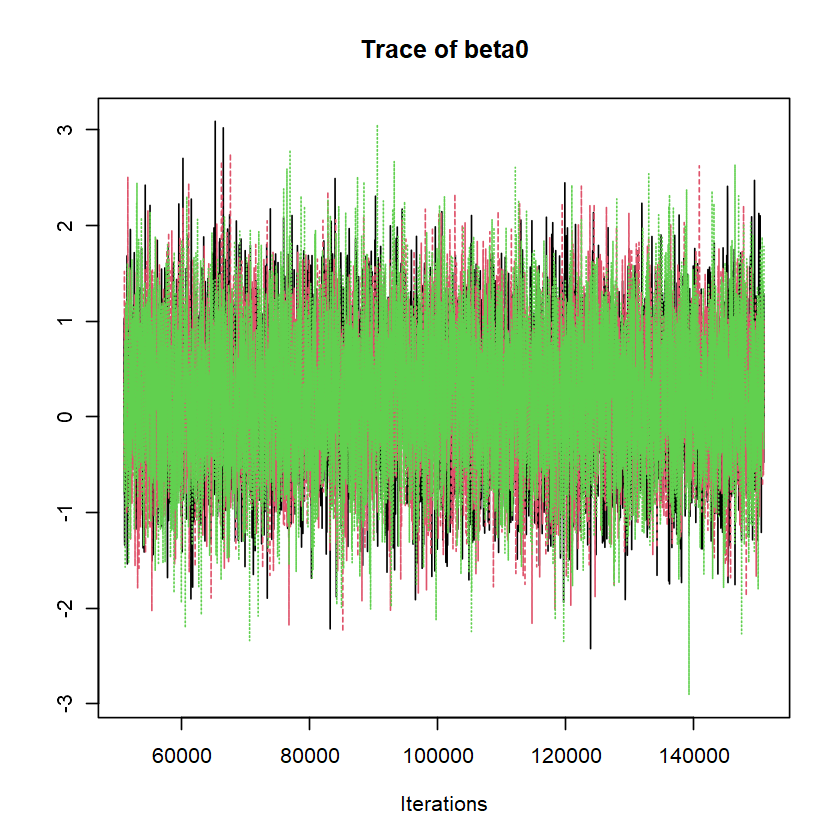

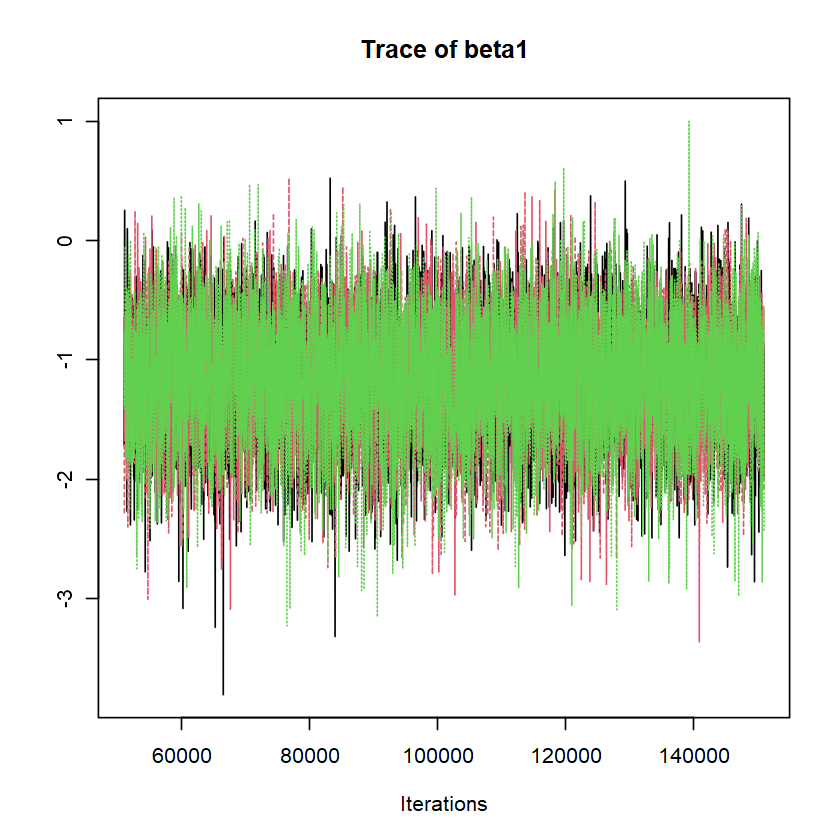

In [ ]:
bmod$graphs(samp, type_of_graph = "traceplot")

In [ ]:
bmod$metrics(samp, type_of_metric = "gelman")

Potential scale reduction factors:

      Point est. Upper C.I.
beta0          1          1
beta1          1          1

Multivariate psrf

1

The Gelman-Rubin criterion (which compares the average intra-chain variance (W) with the inter-chain variance (B)) is equal to 1, so the 3 chains have converged towards the same distribution.

In [ ]:
bmod$metrics(samp, type_of_metric = "autocorr")

,beta0,beta1
Lag 0,1.000000000,1.000000000
Lag 15,0.310761290,0.314591258
Lag 75,0.001850527,0.002375530
Lag 150,-0.001207818,-0.001764633
Lag 750,0.005726059,0.003920240


The autocorrelations are all <0.4 so the samples are not dependent (if samples are autocorrelated, they do not bring enough new information, so less autocorrelation means more information per sample. Autocorrelation can also slow down or even prevent convergence)


In [ ]:
bmod$metrics(samp, type_of_metric = "effectivesize")

beta0    beta1 
10514.32 10425.25

10000 independent samples for each parameters, so estimations are reliable?

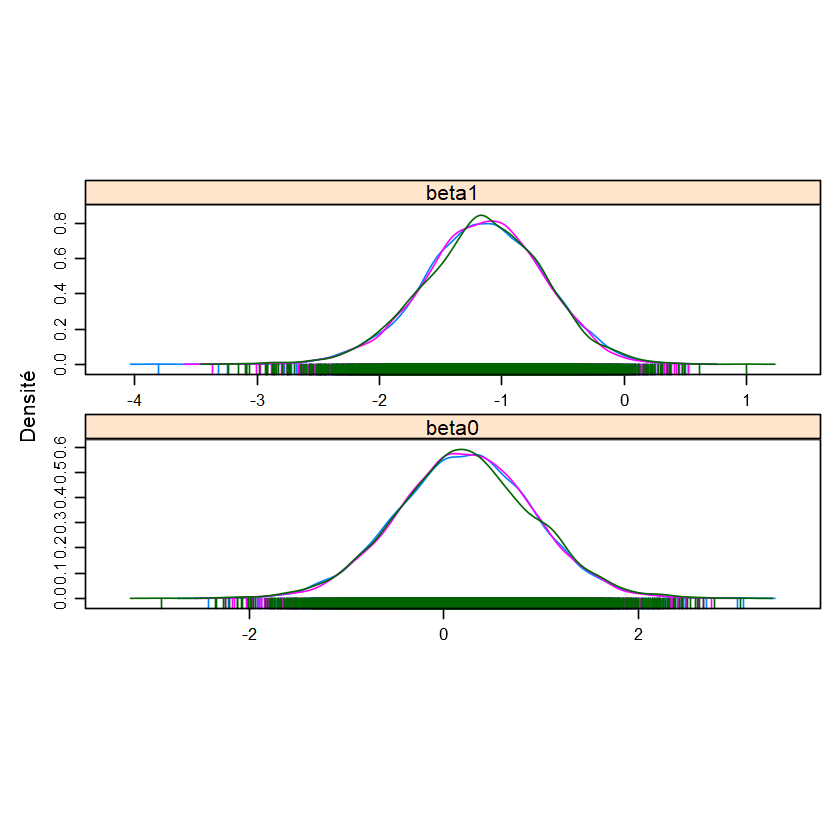

In [ ]:
bmod$graphs(samp, type_of_graph = "density")

In [ ]:
# First 5 samples of chain 1
head(samp[[1]], 5)
head(samp[[2]], 5)
head(samp[[3]], 5)

# # Last 5 samples of chain 1
# tail(samp[[1]], 5)
# tail(samp[[2]], 5)
# tail(samp[[3]], 5)


Markov Chain Monte Carlo (MCMC) output:
Start = 51015 
End = 51090 
Thinning interval = 15 
           beta0      beta1
[1,] -0.17318620 -1.2441184
[2,]  1.02536849 -1.7176155
[3,]  0.07803553 -1.0931399
[4,] -0.35329915 -0.8711135
[5,] -0.81478627 -0.6765121
[6,]  0.66088668 -1.6566713

Markov Chain Monte Carlo (MCMC) output:
Start = 51015 
End = 51090 
Thinning interval = 15 
           beta0      beta1
[1,] -0.55406142 -0.6472584
[2,] -0.02256856 -1.0033850
[3,]  0.39449571 -1.5916942
[4,]  0.37837991 -1.3523187
[5,]  1.52003072 -2.2972313
[6,]  0.71661664 -1.3249131

Markov Chain Monte Carlo (MCMC) output:
Start = 51015 
End = 51090 
Thinning interval = 15 
            beta0      beta1
[1,]  0.345460327 -1.3672711
[2,] -0.156850332 -1.0340579
[3,]  0.086468345 -0.8480819
[4,] -0.789062778 -0.8133594
[5,] -0.007258428 -0.8748719
[6,] -0.271592119 -0.7572615

The distributions are not identical and the chains are not intialized the same way so each chain brings information

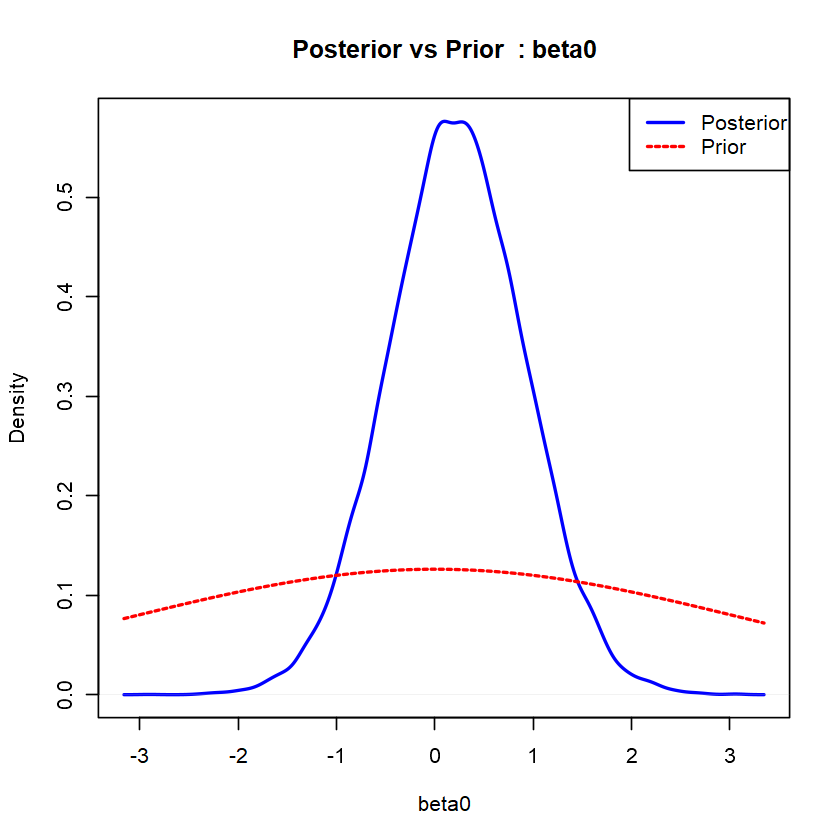

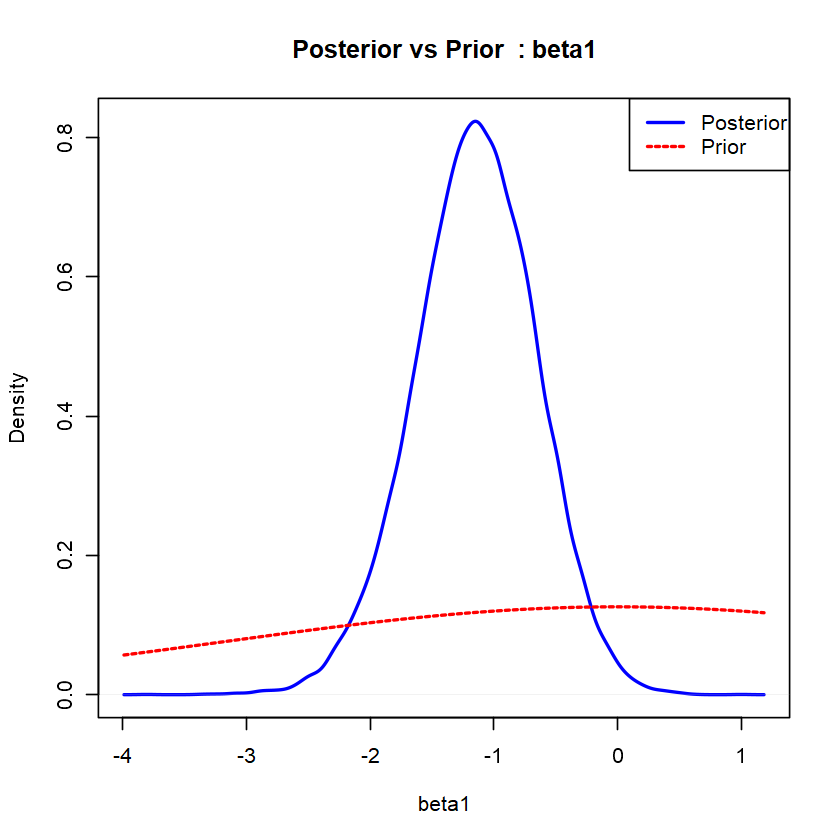

In [ ]:
bmod$graphs(samp, 
            type_of_graph = "comparison", 
            apriori=list(c("beta0",function(x) dnorm(x, mean = 0, sd = sqrt(10))),c("beta1", function(x) dnorm(x, mean = 0, sd = sqrt(10))))
)

In [ ]:
bmod$summ(samp)


Iterations = 51015:150990
Thinning interval = 15 
Number of chains = 3 
Sample size per chain = 6666 

1. Empirical mean and standard deviation for each variable,
   plus standard error of the mean:

         Mean     SD Naive SE Time-series SE
beta0  0.2206 0.6928 0.004899       0.006756
beta1 -1.1512 0.4915 0.003475       0.004814

2. Quantiles for each variable:

        2.5%     25%     50%     75%   97.5%
beta0 -1.137 -0.2416  0.2181  0.6866  1.5837
beta1 -2.150 -1.4708 -1.1411 -0.8155 -0.2265


In [ ]:
#odds
exp(-1.1528 )

[1] 0.3157514

In [ ]:
beta1_samples <- as.matrix(samp)[, "beta1"]
prob_neg <- mean(beta1_samples < 0)
print(prob_neg)

[1] 0.9927493


In average, the tretament reduces the chances of treatment failure of  68% and there is a 97,5% chance of a reduction of at least 21%. Theses results are similar to those of the logistic regression

In [ ]:
results_df_log

Variable_to_explain,OR_CI_not_adjusted,p_value_1,OR_CI_adjusted,p_value_2
<chr>,<chr>,<dbl>,<chr>,<dbl>
TreatmentFailureMan,0.32 (0.12 - 0.85),0.022941429,0.24 (0.07 - 0.78),0.018394660
EarlyFailureMan,0.96 (0.29 - 3.22),0.951568231,1.13 (0.24 - 5.35),0.872723966
EMV,0.76 (0.19 - 3.02),0.691642954,0.82 (0.13 - 5.25),0.831956379
ESS,0.63 (0.1 - 4.01),0.624227646,0 (0 - 123425.5),0.203536341
ED,0.97 (0.13 - 7.24),0.973010054,9.01 (0.01 - 10463.37),0.537662368
LateFailureMan,0.05 (0.01 - 0.43),0.006378337,0.03 (0 - 0.35),0.005196135
RP,0.09 (0.01 - 0.77),0.028254932,0.06 (0.01 - 0.65),0.020701023
RF,0.18 (0.02 - 1.63),0.125499406,0.13 (0.01 - 1.35),0.085992680
LMV,0.23 (0.02 - 2.16),0.196175133,0.13 (0.01 - 1.55),0.105963253


- Courbe de la vraisemblance
- tracé de la probabilité d'évènement

In [ ]:
# bmod$predictions(mod, variable_names=c("Y_pred"), niter = 100000, thin = 15)

Let's consider:\
X: random variable representing the treatment group (0 for placebo)\
Y: random variable representing the number of days in the ICU

$Y=y \mid X=x \sim \text{BN}(p(x), \theta)$, $x \in \{0,1\}$ 
where :
- $E(Y)=\mu(x) = \theta\frac{1-p(x)}{p(x)}$ with $\mu(x)=exp(\beta_0 + \beta_1x)$, so $p(x)=\frac{\theta}{exp(\beta_0 + \beta_1x)+\theta}$\
According to Bayes formula:
$
\psi(\beta, \theta/y)\approx f(y/\beta, \theta)\pi(\beta)\phi(\theta)$ (we suppose $\theta$ and $\beta$ independant)
, 
with:
- $\beta =(\beta_0, \beta_1) \sim \text{N}(\mu, \Sigma)$ where $\Sigma=\binom{\sigma_0^{2}   \rho_{\sigma_0\sigma_1}}{\rho_{\sigma_0 \sigma_1}  \sigma_1^{2}}$ and $ \mu = \binom{\mu_0}{\mu_1}$
- $ \pi(\beta)=\frac{exp(-\frac{1}{2}(\beta-\mu)^T\Sigma^-1(\beta-\mu))}{2\pi|\Sigma|^\frac{1}{2}}$
- $f(y/\beta, \theta)= \prod_{i=1}^n [\binom{y_i + \theta - 1}{y_i} \, p(x_i)^\theta (1 - p(x_i))^{y_i}]=$
$\prod_{i=1}^n [\binom{y_i + \theta - 1}{y_i} \, (\frac{\theta}{exp(\beta_0 + \beta_1x_i)+\theta})^\theta (1 - \frac{\theta}{exp(\beta_0 + \beta_1x_i)+\theta})^{y_i}]$\
- We suppose $\theta \sim \Gamma(a,b)$:
$ \phi(\theta)= \theta^{a-1}\frac{b^a e{-b\theta}}{\Gamma{a}} $\
considering a sample $(x,y)=((x_1,y_1),..., (x_n,y_n))$\
Finally:
$$
\psi(\beta, \theta/y)\approx \theta^{a-1}\frac{b^a e{-b\theta}}{\Gamma{a}} \frac{exp(-\frac{1}{2}(\beta-\mu)^T\Sigma^-1(\beta-\mu))}{2\pi|\Sigma|^\frac{1}{2}} \prod_{i=1}^n [\binom{y_i + \theta - 1}{y_i} \, (\frac{\theta}{exp(\beta_0 + \beta_1x_i)+\theta})^\theta (1 - \frac{\theta}{exp(\beta_0 + \beta_1x_i)+\theta})^{y_i}]
$$


For all simulations, since we know the average number of days in the ICU for non dead placebo patients is 4.66 days, 

* **Non informative scenario**: \
$\beta_1,\beta_0 \sim \text{N}(0,10), \text{IC}_{95\%} = [-19.6, 19.6]$\
=> We have a large range so we're not sure if the treatment works or not\
$\theta \sim \Gamma(0.01,0.01), \text{IC}_{95\%} = [3.5e-159, 4.7]$\
=> Very large range so no concrete information on the overdispersion

* **Optimistic scenario**: \
$\beta_0 \sim \text{N}(-0.8,0.2), \text{IC}_{95\%} = [-1.192, -0.408]$, IC for proportions : [0.23, 0.4]\
$\beta_1 \sim \text{N}(-0.4,0.2), \text{IC}_{95\%} = [-0.792, 0.008]$\
=> The treatment reduces the chaces of having a treatment failure by 0 to 45%. The proportion for the placebo group is close to the real one of 0.29\
$\theta \sim \Gamma(35,80), \text{IC}_{95\%} = [0.30, 0.59]$\
=> small variability of $\theta$ w around the true value of 0.35, meaning a strong overdispersion so a variable number of days in the ICU amongst patients

* **Pessimistic scenario**: \
$\beta_0 \sim \text{N}(-0.8,0.2)$\
$\beta_1 \sim \text{N}(0,0.2), \text{IC}_{95\%} = [-0.392, 0.392]$\
=> The treatment may have no effect (0 in the IC)\
$\theta \sim \Gamma(10,1), \text{IC}_{95\%} = [4.79, 17.09]$\
=> Moderate varaibility of $\theta$ but very far from the true value, with also a moderate overdispersion: the number of days in spent in the ICU do not vary as much among patients


déduire la surdispersion en fonction de la varaince

In [ ]:
#Pessimistic scenario
df<-data_dint[data_dint$UCI_Interm==1,]
modelString_nb_pess="
model {
  for (i in 1:N) {
     Y[i] ~ dnegbin(p[i], theta)
     Y_pred[i] ~ dnegbin(p[i], theta)
     p[i] <- theta/(exp(beta0 + beta1*X[i])+theta)
  }
  beta0 ~ dnorm(-0.8,5)
  beta1 ~ dnorm(0,5)
  theta~ dgamma(10, 1)
} 
"
bmod_nb_pess <- BayesianModel$new(data = df, Y = "EvolDiasUCI_tronq", X = "Grupo", modelString = modelString_nb_pess)

Compiling model graph
   Resolving undeclared variables
   Allocating nodes
Graph information:
   Observed stochastic nodes: 89
   Unobserved stochastic nodes: 94
   Total graph size: 290

Initializing model



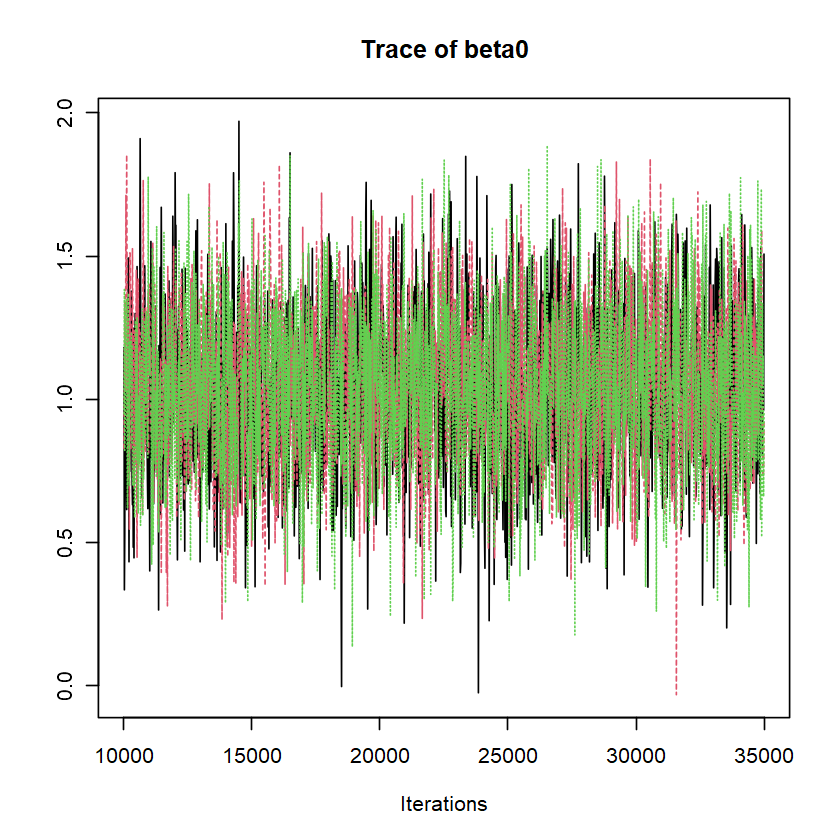

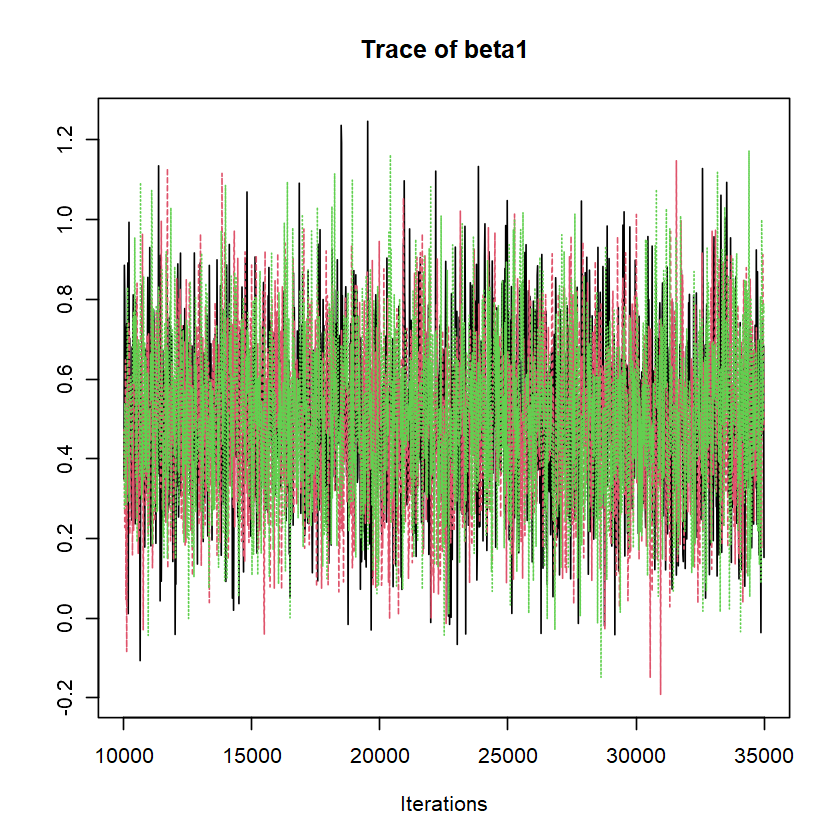

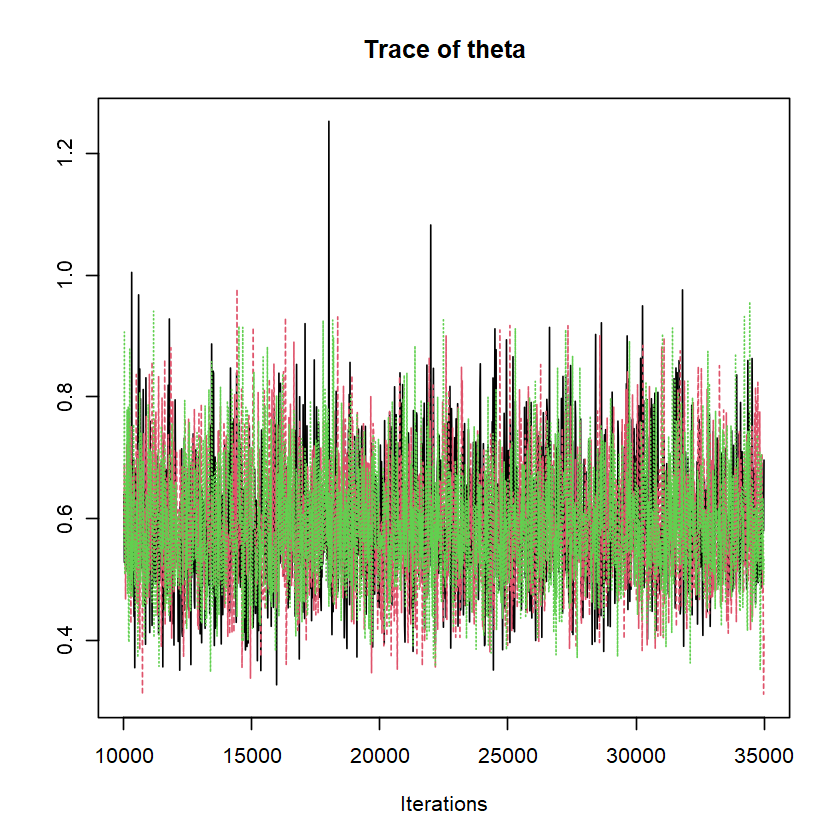

In [ ]:

mod_nb_pess <- bmod_nb_pess$model(nchains = 3, nadapt = 1000, burnin = 9000)
samp_nb_pess <- bmod_nb_pess$sample(model = mod_nb_pess, variable_names = c("beta0", "beta1","theta"), niter =25000, thin = 15)
bmod_nb_pess$graphs(samp_nb_pess, type_of_graph = "traceplot")


In [ ]:
bmod_nb_pess$metrics(samp_nb_pess, type_of_metric = "gelman")

Potential scale reduction factors:

      Point est. Upper C.I.
beta0          1       1.00
beta1          1       1.00
theta          1       1.01

Multivariate psrf

1

In [ ]:
bmod_nb_pess$metrics(samp_nb_pess, type_of_metric = "autocorr")

,beta0,beta1,theta
Lag 0,1.000000000,1.0000000000,1.000000000
Lag 15,0.113205297,0.1163623747,0.009383509
Lag 75,-0.004222828,-0.0005090862,0.018764501
Lag 150,-0.012509190,0.0017320511,0.002697487
Lag 750,-0.003133741,-0.0018792951,-0.002381648


In [ ]:
bmod_nb_pess$metrics(samp_nb_pess, type_of_metric = "effectivesize")


beta0    beta1    theta 
4314.529 4050.184 5399.526

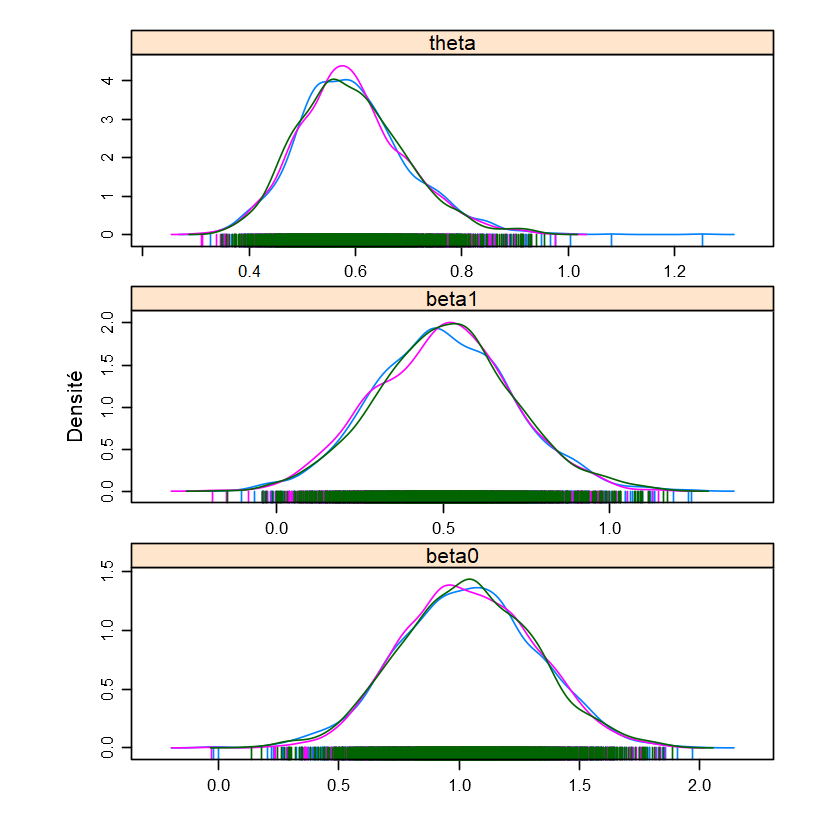

In [ ]:
bmod_nb_pess$graphs(samp_nb_pess, type_of_graph = "density")

In [ ]:
# First 5 samples of chain 1
head(samp_nb_pess[[1]], 5)
head(samp_nb_pess[[2]], 5)
head(samp_nb_pess[[3]], 5)

Markov Chain Monte Carlo (MCMC) output:
Start = 10015 
End = 10090 
Thinning interval = 15 
         beta0     beta1     theta
[1,] 1.1811634 0.3491303 0.6397964
[2,] 0.3357123 0.8854479 0.5283657
[3,] 0.5321807 0.8042519 0.6304072
[4,] 1.1722753 0.3821937 0.5641949
[5,] 0.9074939 0.5453535 0.5602753
[6,] 0.8269136 0.7301603 0.6397709

Markov Chain Monte Carlo (MCMC) output:
Start = 10015 
End = 10090 
Thinning interval = 15 
         beta0      beta1     theta
[1,] 0.8298529 0.47329713 0.5774122
[2,] 1.0117567 0.46074535 0.6903464
[3,] 1.3422588 0.22749544 0.6173235
[4,] 1.1370936 0.40004541 0.5959572
[5,] 1.0309058 0.64798727 0.4680337
[6,] 1.7134586 0.04693047 0.5754188

Markov Chain Monte Carlo (MCMC) output:
Start = 10015 
End = 10090 
Thinning interval = 15 
         beta0     beta1     theta
[1,] 0.9511274 0.4671648 0.5572359
[2,] 1.3838518 0.2753641 0.9063292
[3,] 0.8224108 0.5398530 0.5084262
[4,] 0.9093385 0.5084442 0.5220386
[5,] 0.9567003 0.4667118 0.6235834
[6,] 1.3015798 0.2846278 0.6423429

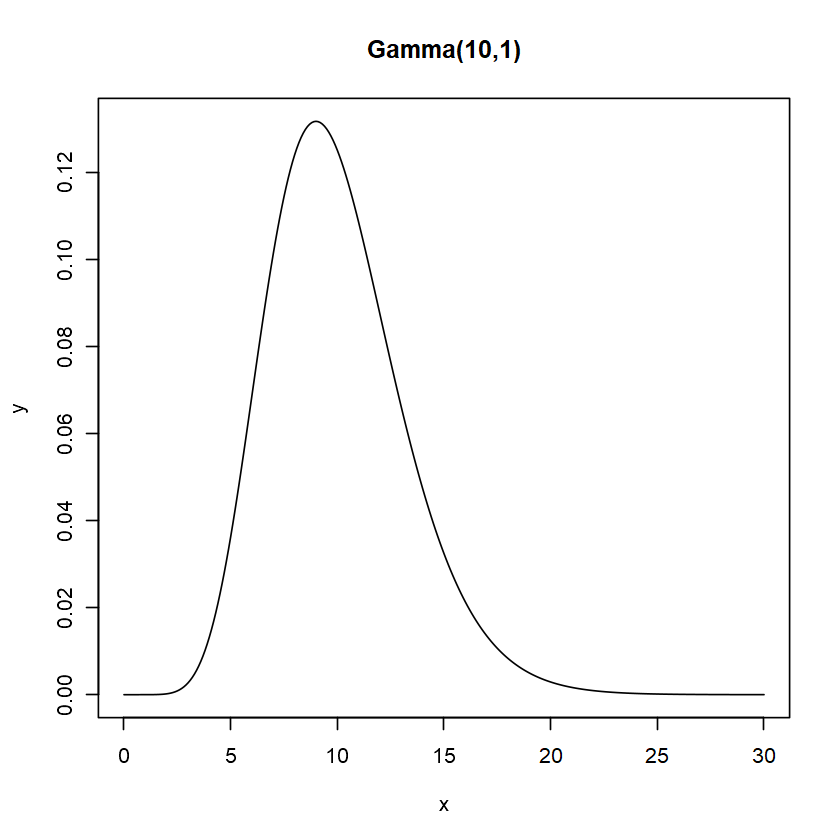

In [ ]:
x <- seq(0, 30, by = 0.1)
y <- dgamma(x, shape = 10, rate = 1)
plot(x, y, type = "l", main = "Gamma(10,1)")

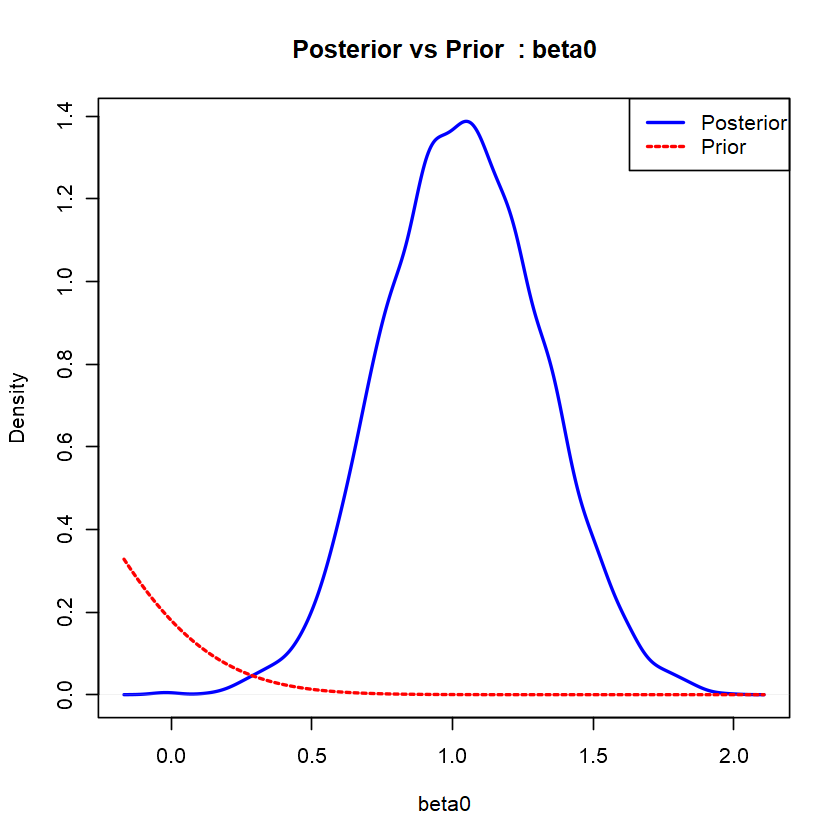

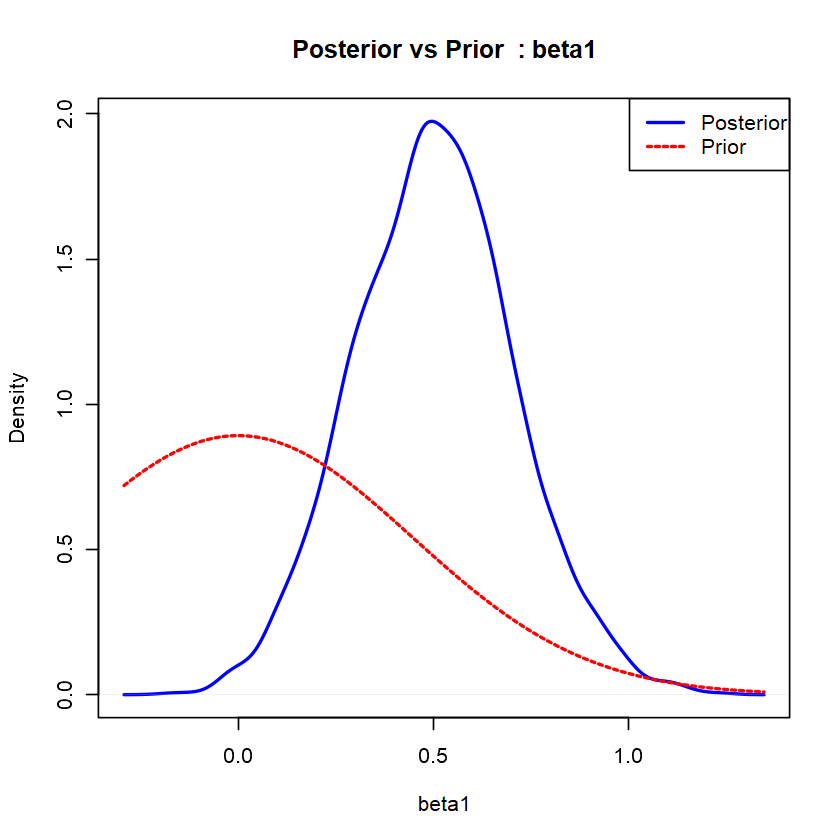

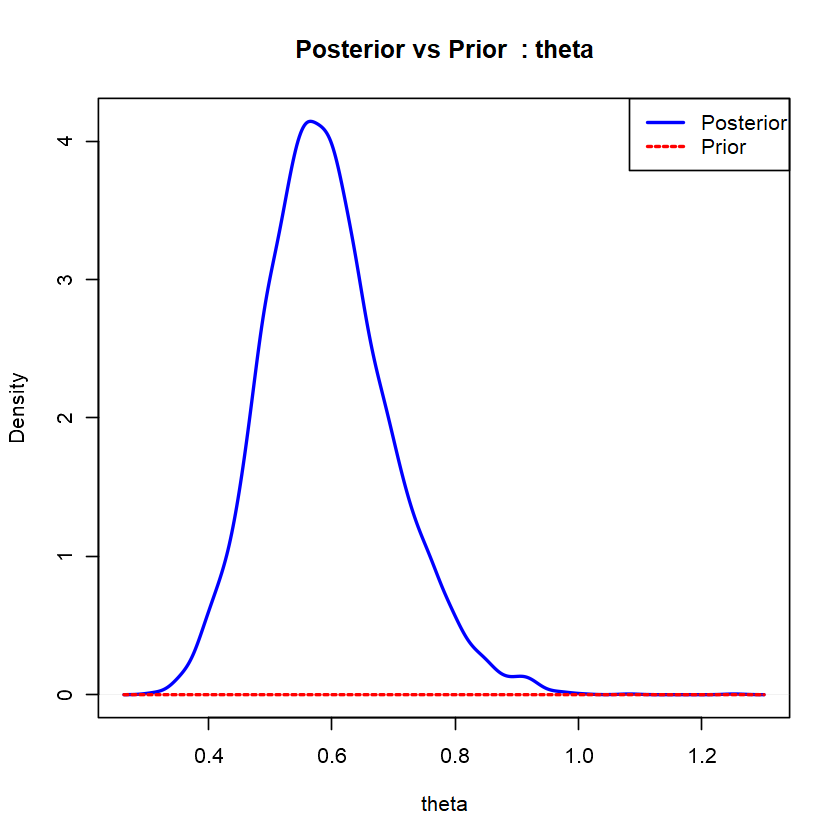

In [ ]:
bmod_nb_pess$graphs(samp_nb_pess, 
            type_of_graph = "comparison", 
            apriori=list(c("beta0",function(x) dnorm(x, mean = -0.8, sd = sqrt(0.2))),
            c("beta1", function(x) dnorm(x, mean = 0, sd = sqrt(0.2))),
            c("theta", function(x) dgamma(x, shape = 10, rate = 1))
            
            )
)

In [ ]:
bmod_nb_pess$summ(samp_nb_pess)



Iterations = 10015:34990
Thinning interval = 15 
Number of chains = 3 
Sample size per chain = 1666 

1. Empirical mean and standard deviation for each variable,
   plus standard error of the mean:

        Mean     SD Naive SE Time-series SE
beta0 1.0382 0.2787 0.003942       0.004272
beta1 0.5029 0.2050 0.002899       0.003225
theta 0.5925 0.1021 0.001445       0.001399

2. Quantiles for each variable:

        2.5%    25%    50%    75%  97.5%
beta0 0.5099 0.8488 1.0365 1.2276 1.5837
beta1 0.1066 0.3623 0.5027 0.6379 0.9168
theta 0.4129 0.5226 0.5840 0.6541 0.8159


In [ ]:
exp(0.9328)

[1] 2.541616

In [ ]:
beta1_nb_pess <- as.matrix(samp_nb_pess)[, "beta1"]
print( mean(beta1_nb_pess < 0))

[1] 0.005802321


In [ ]:
#non informative scenario
modelString_nb="
model {
  for (i in 1:N) {
     Y[i] ~ dnegbin(p[i], theta)
     Y_pred[i] ~ dnegbin(p[i], theta)
     p[i] <- theta/(exp(beta0 + beta1*X[i])+theta)
  }
  beta0 ~ dnorm(0,0.1)
  beta1 ~ dnorm(0,0.1)
  theta~ dgamma(0.01, 0.01)
} 
"
bmod_nb <- BayesianModel$new(data = df, Y = "EvolDiasUCI_tronq", X = "Grupo", modelString = modelString_nb)

Compiling model graph
   Resolving undeclared variables
   Allocating nodes
Graph information:
   Observed stochastic nodes: 89
   Unobserved stochastic nodes: 94
   Total graph size: 287

Initializing model



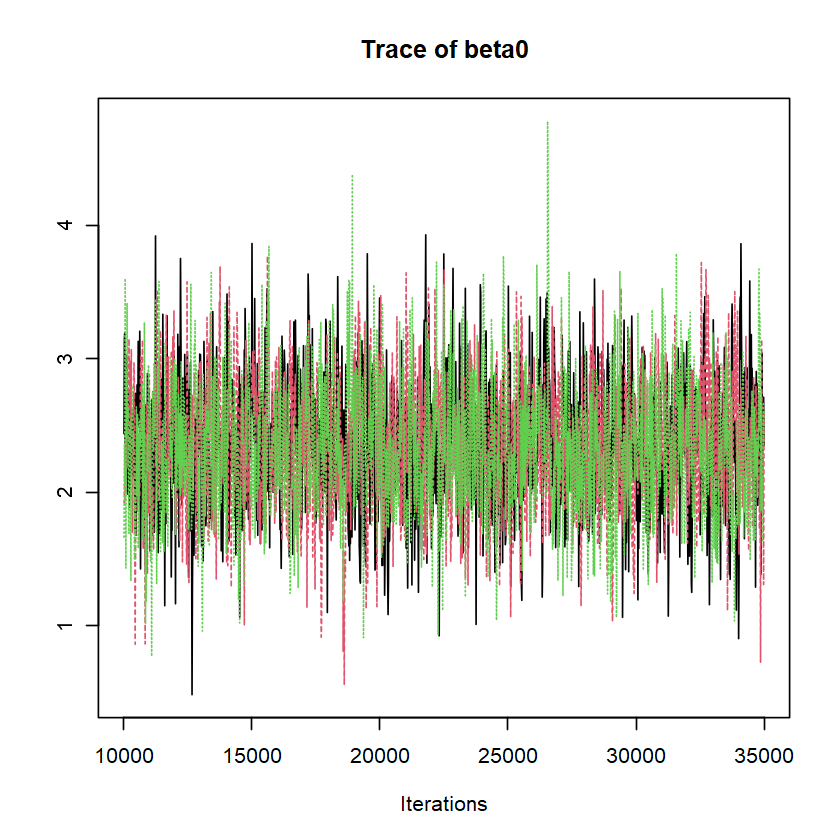

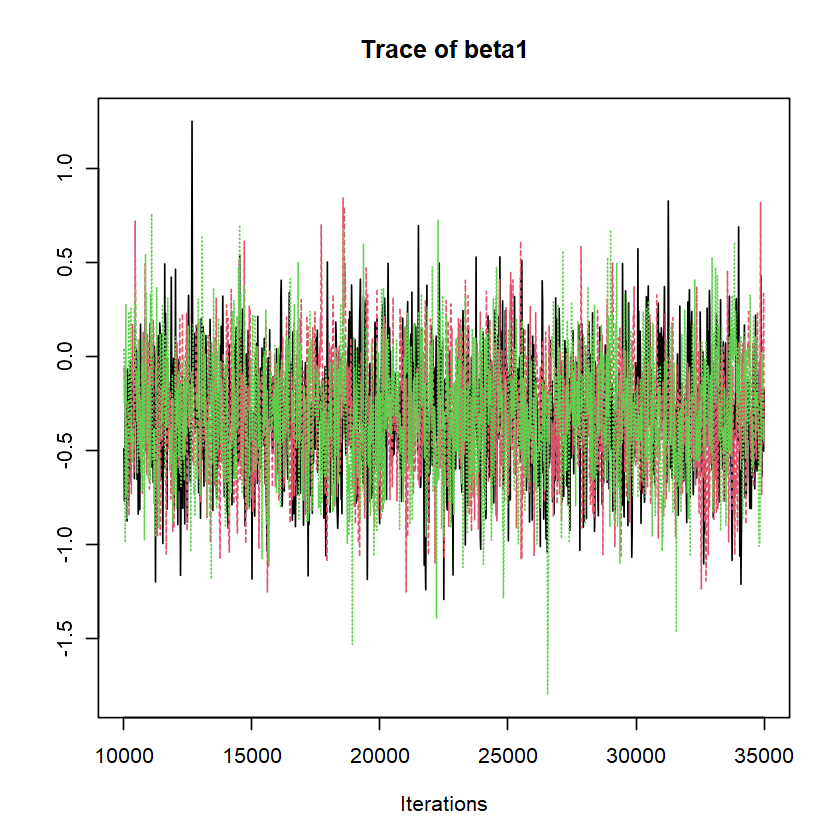

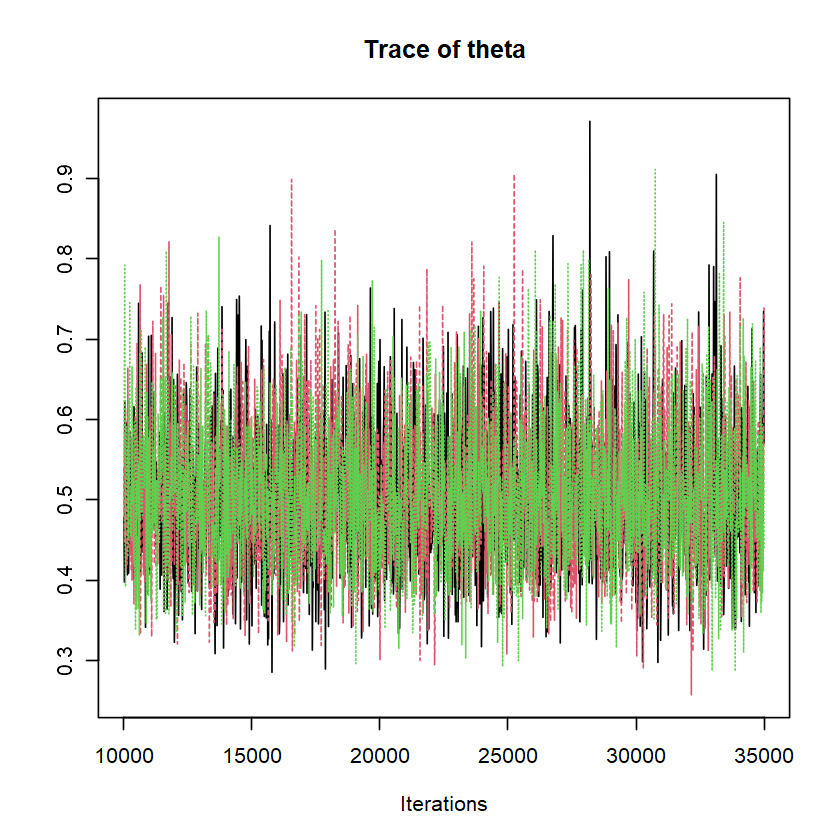

In [ ]:
mod_nb<- bmod_nb$model(nchains = 3, nadapt = 1000, burnin = 9000)
samp_nb<- bmod_nb$sample(model = mod_nb, variable_names = c("beta0", "beta1","theta"), niter =25000, thin = 15)
bmod_nb$graphs(samp_nb, type_of_graph = "traceplot")


In [ ]:
bmod_nb$metrics(samp_nb, type_of_metric = "gelman")


Potential scale reduction factors:

      Point est. Upper C.I.
beta0          1          1
beta1          1          1
theta          1          1

Multivariate psrf

1

In [ ]:
bmod_nb$metrics(samp_nb, type_of_metric = "autocorr")

,beta0,beta1,theta
Lag 0,1.000000000,1.000000000,1.000000000
Lag 15,0.347568069,0.356124588,-0.018196441
Lag 75,-0.015209259,-0.013003310,0.009552349
Lag 150,0.001935976,0.008875424,-0.008308066
Lag 750,-0.013863705,-0.016354141,0.002597409


In [ ]:
bmod_nb$metrics(samp_nb, type_of_metric = "effectivesize")


beta0    beta1    theta 
2415.883 2372.200 5329.675

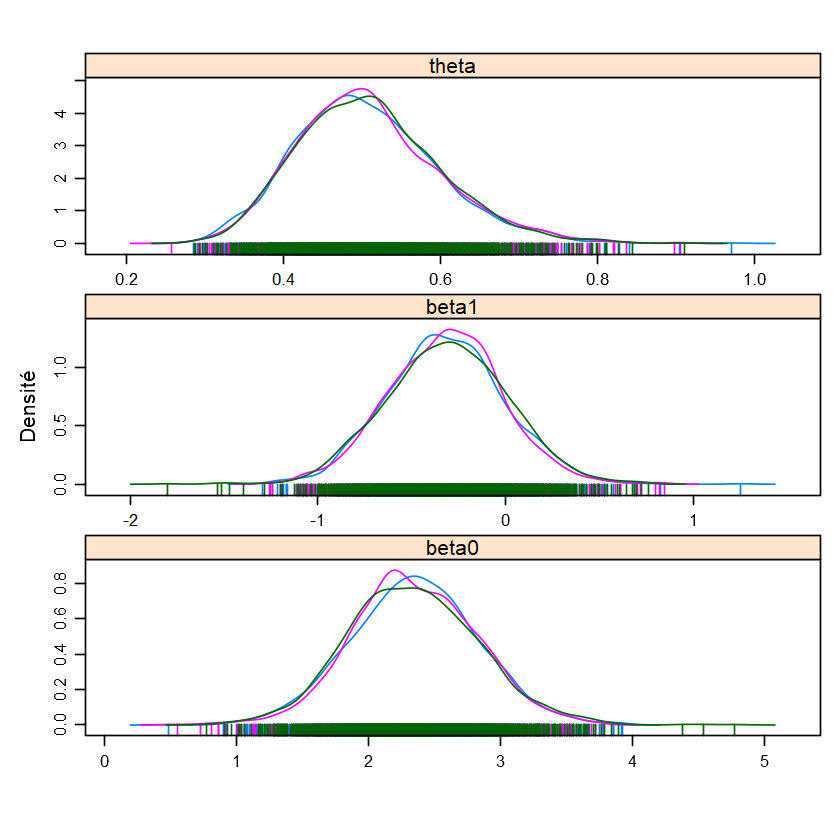

In [ ]:
bmod_nb$graphs(samp_nb, type_of_graph = "density")

In [ ]:
# First 5 samples of all chains
head(samp_nb[[1]], 5)
head(samp_nb[[2]], 5)
head(samp_nb[[3]], 5)

Markov Chain Monte Carlo (MCMC) output:
Start = 10015 
End = 10090 
Thinning interval = 15 
        beta0      beta1     theta
[1,] 2.438116 -0.4913455 0.4786074
[2,] 3.146306 -0.7679203 0.3978986
[3,] 3.195043 -0.7718967 0.6228216
[4,] 2.201403 -0.3502662 0.4861469
[5,] 2.349929 -0.2610689 0.5387370
[6,] 2.533305 -0.4626243 0.4166199

Markov Chain Monte Carlo (MCMC) output:
Start = 10015 
End = 10090 
Thinning interval = 15 
        beta0       beta1     theta
[1,] 1.926905 -0.06271348 0.5394122
[2,] 1.919069 -0.13681515 0.4480225
[3,] 2.211560 -0.25834904 0.5850164
[4,] 1.928122 -0.07408069 0.5419854
[5,] 2.516573 -0.34898008 0.6143536
[6,] 2.528545 -0.57519898 0.4426710

Markov Chain Monte Carlo (MCMC) output:
Start = 10015 
End = 10090 
Thinning interval = 15 
        beta0       beta1     theta
[1,] 1.662999  0.03477436 0.5478110
[2,] 2.352251 -0.24784965 0.6702384
[3,] 2.054253 -0.11494107 0.7923431
[4,] 3.600490 -0.99132699 0.4589101
[5,] 2.059854 -0.05714913 0.3931149
[6,] 1.430807  0.27799061 0.5041383

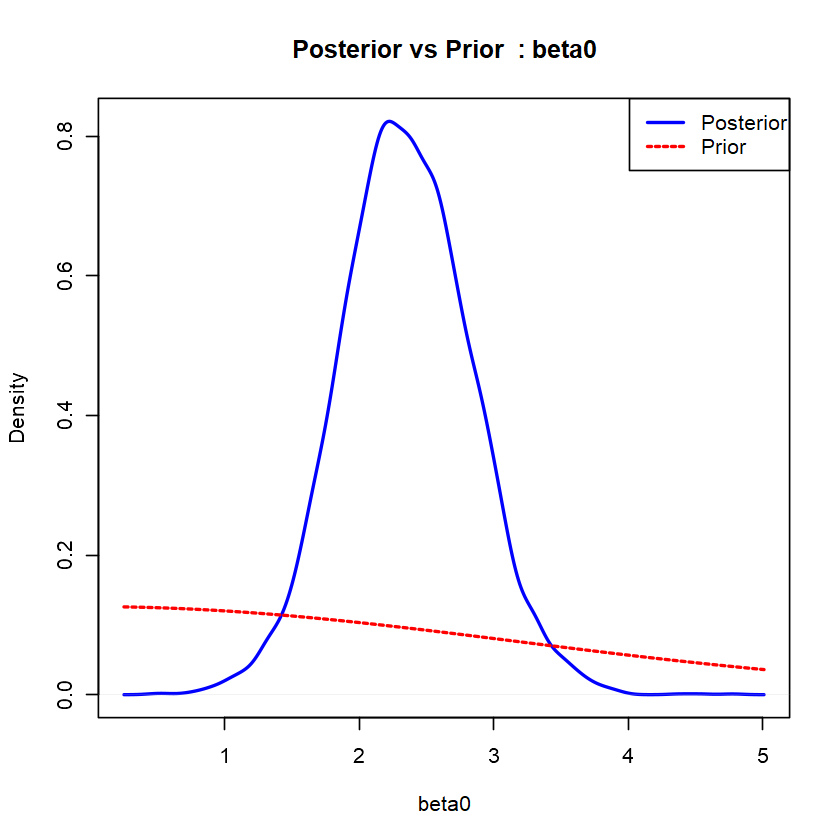

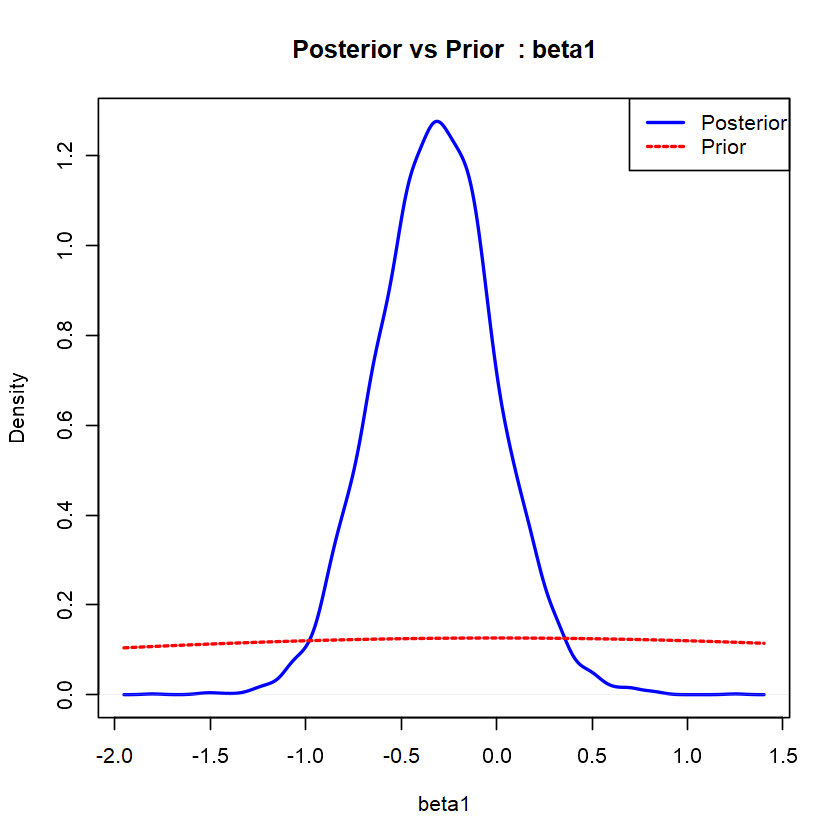

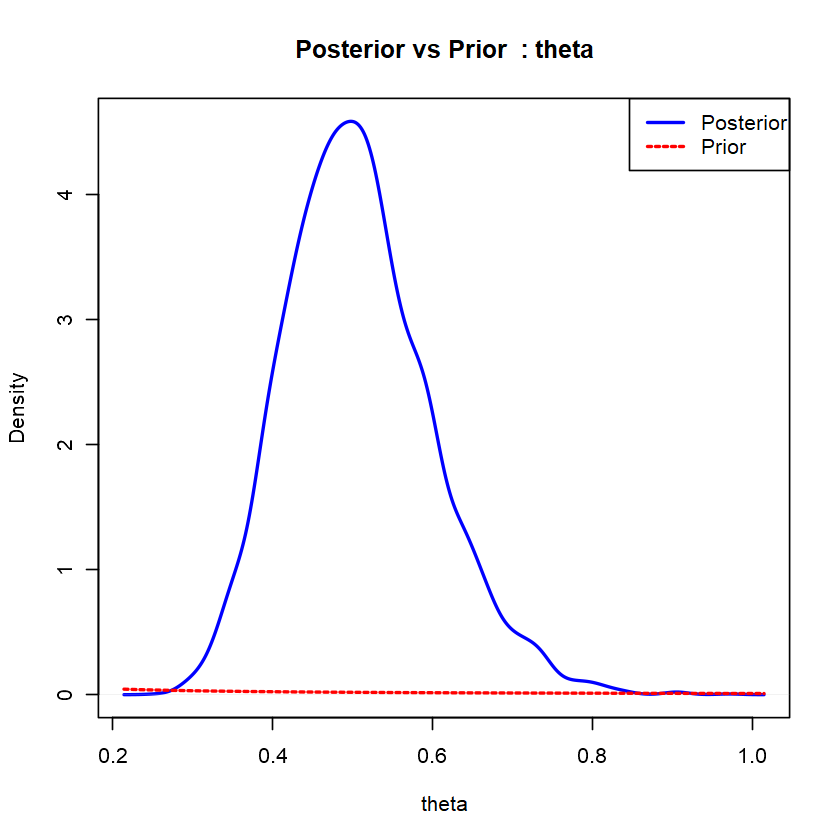

In [ ]:
bmod_nb$graphs(samp_nb, 
            type_of_graph = "comparison", 
            apriori=list(c("beta0",function(x) dnorm(x, mean = 0, sd = sqrt(10))),
            c("beta1", function(x) dnorm(x, mean = 0, sd = sqrt(10))),
            c("theta", function(x) dgamma(x, shape = 0.01, rate = 0.01))
            
            )
)

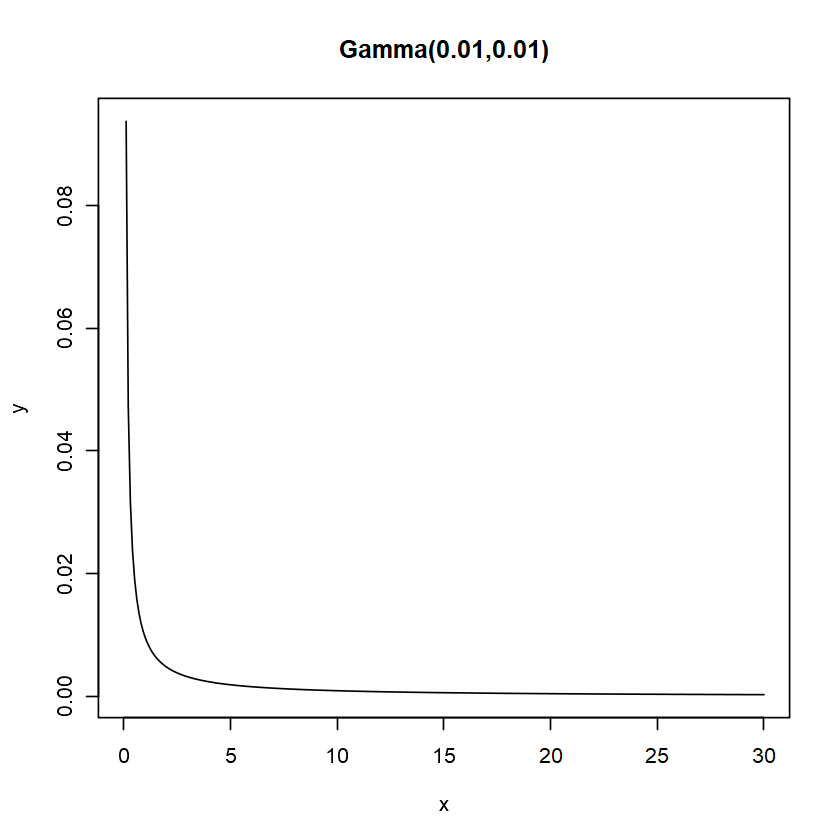

In [ ]:
x <- seq(0, 30, by = 0.1)
y <- dgamma(x, shape = 0.01, rate = 0.01)
plot(x, y, type = "l", main = "Gamma(0.01,0.01)")

In [ ]:
bmod_nb$summ(samp_nb)



Iterations = 10015:34990
Thinning interval = 15 
Number of chains = 3 
Sample size per chain = 1666 

1. Empirical mean and standard deviation for each variable,
   plus standard error of the mean:

         Mean      SD Naive SE Time-series SE
beta0  2.3470 0.48249 0.006825       0.009829
beta1 -0.3162 0.31446 0.004448       0.006463
theta  0.5074 0.09069 0.001283       0.001243

2. Quantiles for each variable:

         2.5%    25%     50%     75%  97.5%
beta0  1.4196  2.027  2.3364  2.6637 3.3134
beta1 -0.9133 -0.524 -0.3159 -0.1119 0.3067
theta  0.3501  0.444  0.5003  0.5625 0.7109


In [ ]:
exp(-0.3033)

[1] 0.7383775

In [ ]:
beta1_nb <- as.matrix(samp_nb)[, "beta1"]
print( mean(beta1_nb < 0))

[1] 0.8509404


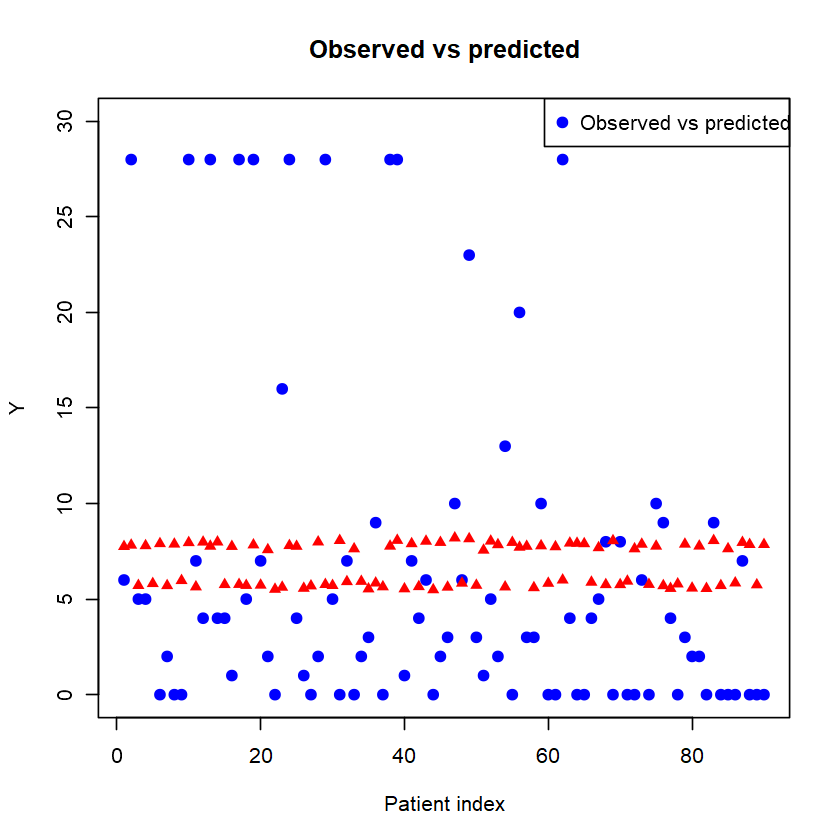

In [ ]:
bmod_nb$predictions(mod_nb, variable_names=c("Y_pred"), niter = 25000, thin = 15, ylim=c(0,30))

In [ ]:
summary(pool(nb_model_), conf.int=TRUE)

term,estimate,std.error,statistic,df,p.value,2.5 %,97.5 %
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),1.8057849,0.2500329,7.222190,115.0385,5.959091e-11,1.310520,2.3010502
Grupo1,-0.4840291,0.3545368,-1.365244,115.0385,1.748403e-01,-1.186296,0.2182375


In [ ]:
mean(data_dint$EvolDiasUCI_tronq[data_dint$Grupo==0 & data_dint$EvolMort28==0 & data_dint$UCI_Interm==1], na.rm=TRUE)

[1] 4.658537

In [ ]:
mean(data_dint$vf_days[data_dint$Grupo==0 & data_dint$vf_days>0 & data_dint$UCI_Interm==1], na.rm=TRUE)

[1] 23.925

In [ ]:
mean(data_dint$vf_days, na.rm=TRUE)^2/(var(data_dint$vf_days, na.rm=TRUE)-mean(data_dint$vf_days, na.rm=TRUE))

[1] 12.50722

**Zero-inflated**

The average number of ventilation-free for non dead placebo patients is 23.93 days\
Proportion of dead placebo patients admitted in the ICU: 6.67%

Let's consider:\
X: random variable representing the treatment group (0 for placebo)\
Y: random variable representing the number of ventilation-free days\
Z: random varaible representing death (1 for death)

$Y=y \mid X=x, Z=0 \sim \text{BN}(p(x), \theta), \text{and} Z=z,\mid X=x \sim \text{B}(\rho(x)) x,z \in \{0,1\}$ 
where :
- $ \rho(x)=P(Z=1 \mid X)= \frac{exp(\alpha_0+\alpha_1x)}{1+exp(\alpha_0+\alpha_1x)}  $
- $E(Y)=\mu(x) = \theta\frac{1-p(x)}{p(x)}$ with $\mu(x)=exp(\beta_0 + \beta_1x)$, so $p(x)=\frac{\theta}{exp(\beta_0 + \beta_1x)+\theta}$\
According to Bayes formula:
$
\psi(\beta, \theta/y)\approx f(y/\beta, \theta)\pi(\beta)\phi(\theta)$ (we suppose $\theta$ and $\beta$ independant)
, 
with:
- $\beta =(\beta_0, \beta_1) \sim \text{N}(\mu, \Sigma)$ where $\Sigma=\binom{\sigma_0^{2}   \rho_{\sigma_0\sigma_1}}{\rho_{\sigma_0 \sigma_1}  \sigma_1^{2}}$ and $ \mu = \binom{\mu_0}{\mu_1}$
- $ \pi(\beta)=\frac{exp(-\frac{1}{2}(\beta-\mu)^T\Sigma^-1(\beta-\mu))}{2\pi|\Sigma|^\frac{1}{2}}$
- $f(y/\beta, \theta)= \prod_{i=1}^n [ (1-z_i)\binom{y_i + \theta - 1}{y_i} \, p(x_i)^\theta (1 - p(x_i))^{y_i}] + \prod_{i=1}^n [ z_i p(x_i)^{\theta}]=$
$\prod_{i=1}^n [ (1-z_i) \binom{y_i + \theta - 1}{y_i} \, (\frac{\theta}{exp(\beta_0 + \beta_1x_i)+\theta})^\theta (1 - \frac{\theta}{exp(\beta_0 + \beta_1x_i)+\theta})^{y_i}] + \prod_{i=1}^n [z_i (\frac{\theta}{exp(\beta_0 + \beta_1x_i)+\theta})^{\theta} ]$
- We suppose $\theta \sim \Gamma(a,b)$:
$ \phi(\theta)= \theta^{a-1}\frac{b^a e{-b\theta}}{\Gamma{a}} $\
considering a sample $(x,y,z)=((x_1,y_1,z_1),..., (x_n,y_n,z_n))$\
Finally:
$$
\psi(\beta, \theta/y)\approx \theta^{a-1}\frac{b^a e{-b\theta}}{\Gamma{a}} \frac{exp(-\frac{1}{2}(\beta-\mu)^T\Sigma^-1(\beta-\mu))}{2\pi|\Sigma|^\frac{1}{2}}\Biggl (\prod_{i=1}^n [ (1-z_i) \binom{y_i + \theta - 1}{y_i} \, (\frac{\theta}{exp(\beta_0 + \beta_1x_i)+\theta})^\theta (1 - \frac{\theta}{exp(\beta_0 + \beta_1x_i)+\theta})^{y_i}] + \prod_{i=1}^n [z_i (\frac{\theta}{exp(\beta_0 + \beta_1x_i)+\theta})^{\theta} ] \Biggr)
$$


* For all the scenarios we consider: $\theta \sim \Gamma(0.05,0.01), \text{IC}_{95\%} = ]0, 56.7]$\
=> Very large range so no concrete information on the overdispersion, but the true value of 12.5 is in the interval\
$\alpha_0 ,\alpha_1, \sim \text{N}(0,10), \text{IC}_{95\%} = [-19,6, 19,6]$\
=> We have a large range so we're not sure if the treatment works or not on death 


* **Non informative scenario**: \
$\beta_0 ,\beta_1 \sim \text{N}(0,10), \text{IC}_{95\%} = [-19,6, 19,6]$\
=> We have a large range so we're not sure if the treatment works or not on number of ventilation-free days


* **Optimistic scenario**: \
$\beta_0 \sim \text{N}(-0.8,0.2), \text{IC}_{95\%} = [-1.192, -0.408]$, IC for proportions : [0.23, 0.4]\
$\beta_1 \sim \text{N}(-0.4,0.2), \text{IC}_{95\%} = [-0.792, 0.008]$\
=> The treatment reduces the chances of having a treatment failure by 0 to 45%. The proportion for the placebo group is close to the real one of 0.29\


* **Pessimistic scenario**: \
$\beta_0 \sim \text{N}(-0.8,0.2)$\
$\beta_1 \sim \text{N}(0,0.2), \text{IC}_{95\%} = [-0.392, 0.392]$\
=> The treatment may have no effect (0 in the IC)\


In [ ]:
df<-data_dint[data_dint$UCI_Interm==1,]
modelString_zinb="
model {
  for (i in 1:N) {
     z[i] ~ dbern(pi[i])
     pi[i] <- exp(alpha0+alpha1*X[i])/(1+exp(alpha0+alpha1*X[i]))
     Y[i] ~ dnegbin(p[i], theta)
     Y_pred[i] ~ dnegbin(p[i], theta)
     loglik[i] <- logdensity.negbin(Y[i], p[i], theta)
     p[i] <- (theta/(exp(beta0 + beta1*X[i])+theta))*(1-z[i]) + z[i]
  }
  alpha0 ~ dnorm(0,0.1)
  alpha1 ~ dnorm(0,0.1)
  theta~ dgamma(0.05, 0.01)
  beta0 ~ dnorm(0,0.1)
  beta1 ~ dnorm(0,0.1)
  
} 
"
modelString_zinb_op="
model {
  for (i in 1:N) {
     z[i] ~ dbern(pi[i])
     pi[i] <- exp(alpha0+alpha1*X[i])/(1+exp(alpha0+alpha1*X[i]))
     Y[i] ~ dnegbin(p[i], theta)
     Y_pred[i] ~ dnegbin(p[i], theta)
     loglik[i] <- logdensity.negbin(Y[i], p[i], theta)
     p[i] <- (theta/(exp(beta0 + beta1*X[i])+theta))*(1-z[i]) + z[i]
  }
  alpha0 ~ dnorm(0,0.1)
  alpha1 ~ dnorm(0,0.1)
  theta~ dgamma(0.05, 0.01)
  beta0 ~ dnorm(-0.8,5)
  beta1 ~ dnorm(-0.4,5)
  
} 
"
modelString_zinb_pess="
model {
  for (i in 1:N) {
     z[i] ~ dbern(pi[i])
     pi[i] <- exp(alpha0+alpha1*X[i])/(1+exp(alpha0+alpha1*X[i]))
     Y[i] ~ dnegbin(p[i], theta)
     Y_pred[i] ~ dnegbin(p[i], theta)
     loglik[i] <- logdensity.negbin(Y[i], p[i], theta)
     p[i] <- (theta/(exp(beta0 + beta1*X[i])+theta))*(1-z[i]) + z[i]
  }
  alpha0 ~ dnorm(0,0.1)
  alpha1 ~ dnorm(0,0.1)
  theta~ dgamma(0.05, 0.01)
  beta0 ~ dnorm(-0.8,5)
  beta1 ~ dnorm(0,5)
  
} 
"
bmod_zinb <- BayesianModel$new(data = df, Y = "vf_days", X = "Grupo", z="EvolMort28",modelString = modelString_zinb)
bmod_zinb_op <- BayesianModel$new(data = df, Y = "vf_days", X = "Grupo",z="EvolMort28", modelString = modelString_zinb_op)
bmod_zinb_pess <- BayesianModel$new(data = df, Y = "vf_days", X = "Grupo",z="EvolMort28", modelString = modelString_zinb_pess)

ERROR: Error in .Object$initialize(...): argument inutilisé (z = "EvolMort28")


In [ ]:
mod_zinb<- bmod_zinb$model(nchains = 3, nadapt = 1000, burnin = 9000)
samp_zinb<- bmod_zinb$sample(model = mod_zinb, variable_names = c("alpha0", "alpha1","beta0", "beta1","theta"), niter =25000, thin = 15)
mod_zinb_op<- bmod_zinb_op$model(nchains = 3, nadapt = 1000, burnin = 9000)
samp_zinb_op<- bmod_zinb_op$sample(model = mod_zinb_op, variable_names = c("alpha0", "alpha1","beta0", "beta1","theta"), niter =25000, thin = 15)
mod_zinb_pess<- bmod_zinb_pess$model(nchains = 3, nadapt = 1000, burnin = 9000)
samp_zinb_pess<- bmod_zinb_pess$sample(model = mod_zinb_pess, variable_names = c("alpha0", "alpha1","beta0", "beta1","theta"), niter =25000, thin = 15)


Compiling model graph
   Resolving undeclared variables
   Allocating nodes
Graph information:
   Observed stochastic nodes: 89
   Unobserved stochastic nodes: 186
   Total graph size: 751

Initializing model

Compiling model graph
   Resolving undeclared variables
   Allocating nodes
Graph information:
   Observed stochastic nodes: 89
   Unobserved stochastic nodes: 186
   Total graph size: 756

Initializing model

Compiling model graph
   Resolving undeclared variables
   Allocating nodes
Graph information:
   Observed stochastic nodes: 89
   Unobserved stochastic nodes: 186
   Total graph size: 754

Initializing model



[1] "Non informative"
[1] "Optimistic"


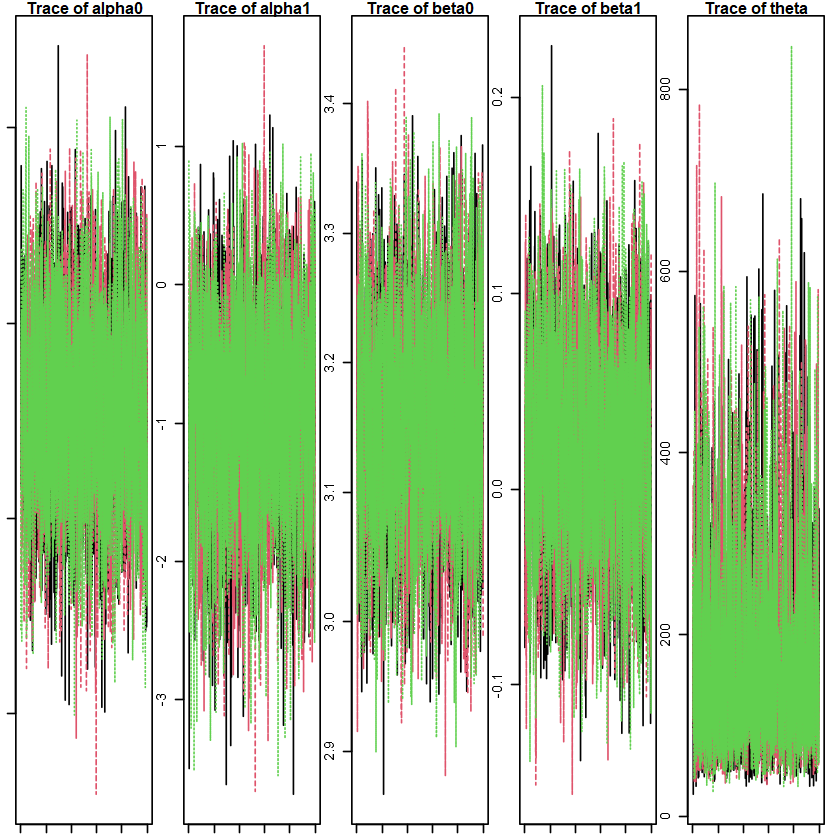

[1] "Pessimistic"


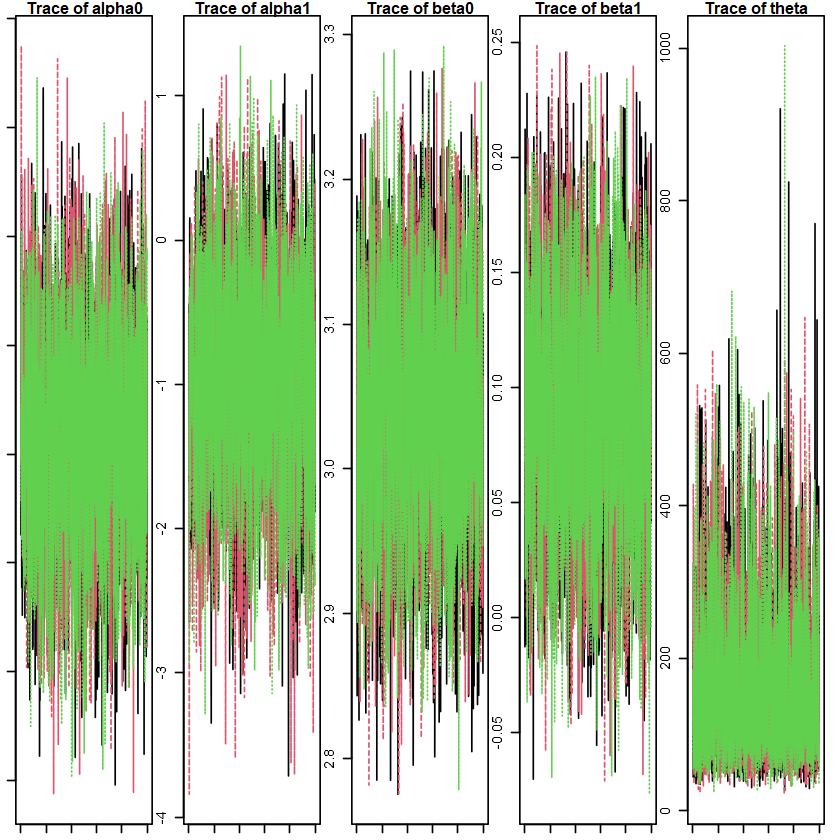

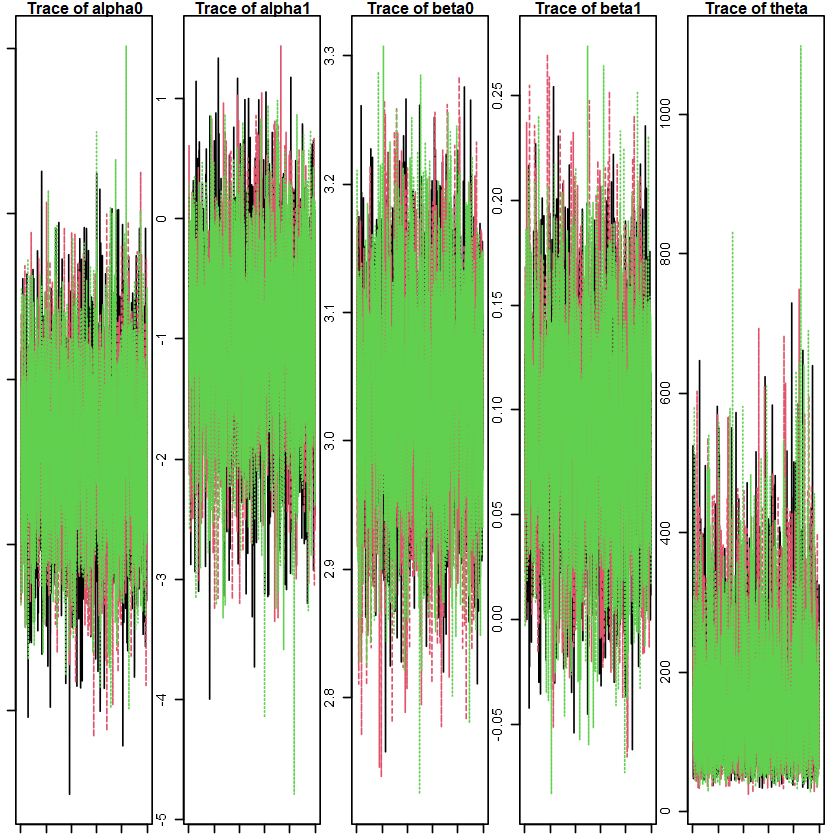

In [ ]:
par(mfrow = c(1, 5), mar=c(1,1,1,1))

print("Non informative")
bmod_zinb$graphs(samp_zinb, type_of_graph = "traceplot")
print("Optimistic")
bmod_zinb_op$graphs(samp_zinb_op, type_of_graph = "traceplot")
print("Pessimistic")
bmod_zinb_pess$graphs(samp_zinb_pess, type_of_graph = "traceplot")


par(mfrow = c(1,1))


In [ ]:
print("Non informative")
bmod_zinb$metrics(samp_zinb, type_of_metric = "gelman")
print("Optimistic")
bmod_zinb_op$metrics(samp_zinb_op, type_of_metric = "gelman")
print("Pessimistic")
bmod_zinb_pess$metrics(samp_zinb_pess, type_of_metric = "gelman")

[1] "Non informative"


Potential scale reduction factors:

       Point est. Upper C.I.
alpha0          1          1
alpha1          1          1
beta0           1          1
beta1           1          1
theta           1          1

Multivariate psrf

1

[1] "Optimistic"


Potential scale reduction factors:

       Point est. Upper C.I.
alpha0          1          1
alpha1          1          1
beta0           1          1
beta1           1          1
theta           1          1

Multivariate psrf

1

[1] "Pessimistic"


Potential scale reduction factors:

       Point est. Upper C.I.
alpha0          1       1.00
alpha1          1       1.01
beta0           1       1.00
beta1           1       1.00
theta           1       1.00

Multivariate psrf

1

In [ ]:
print("Non informative")
bmod_zinb$metrics(samp_zinb, type_of_metric = "autocorr")
print("Optimistic")
bmod_zinb_op$metrics(samp_zinb_op, type_of_metric = "autocorr")
print("Pessimistic")
bmod_zinb_pess$metrics(samp_zinb_pess, type_of_metric = "autocorr")

[1] "Non informative"


,alpha0,alpha1,beta0,beta1,theta
Lag 0,1.000000000,1.000000000,1.00000000,1.0000000000,1.000000000
Lag 15,0.275606924,0.272557321,0.37886921,0.3752393278,-0.004863383
Lag 75,0.001667740,-0.003947952,0.01134301,-0.0003766584,0.009193866
Lag 150,0.004135827,0.009711126,0.02185097,0.0207173900,0.033919714
Lag 750,0.023246165,0.013789664,-0.03132466,-0.0307679843,0.009376868


[1] "Optimistic"


,alpha0,alpha1,beta0,beta1,theta
Lag 0,1.000000000,1.000000000,1.00000000,1.00000000,1.000000000
Lag 15,0.311386766,0.297489046,0.35511871,0.36149585,0.009125492
Lag 75,-0.005541824,-0.003079344,0.01724654,0.02412399,0.019823623
Lag 150,-0.033956424,-0.039290679,-0.01719436,-0.02148433,0.014510395
Lag 750,-0.009921961,-0.007813278,0.03305459,0.03096148,-0.016652835


[1] "Pessimistic"


,alpha0,alpha1,beta0,beta1,theta
Lag 0,1.000000000,1.000000000,1.000000000,1.000000000,1.000000000
Lag 15,0.305541877,0.299577707,0.339363895,0.345905543,0.008648503
Lag 75,-0.033156538,-0.017117204,-0.003316880,-0.007312084,-0.003096361
Lag 150,0.020937670,0.011277393,0.005285848,0.001521835,-0.003302019
Lag 750,-0.002244842,0.006974841,-0.017330001,-0.013470018,0.012049112


In [ ]:
print("Non informative")
bmod_zinb$metrics(samp_zinb, type_of_metric = "effectivesize")
print("Optimistic")
bmod_zinb_op$metrics(samp_zinb_op, type_of_metric = "effectivesize")
print("Pessimistic")
bmod_zinb_pess$metrics(samp_zinb_pess, type_of_metric = "effectivesize")

[1] "Non informative"


alpha0   alpha1    beta0    beta1    theta 
2846.674 2893.954 2254.685 2271.954 5249.362

[1] "Optimistic"


alpha0   alpha1    beta0    beta1    theta 
2457.778 2514.361 2370.329 2241.396 4066.844

[1] "Pessimistic"


alpha0   alpha1    beta0    beta1    theta 
2788.775 2702.834 2384.860 2326.057 4998.000

[1] "Non informative"
[1] "optimistic"


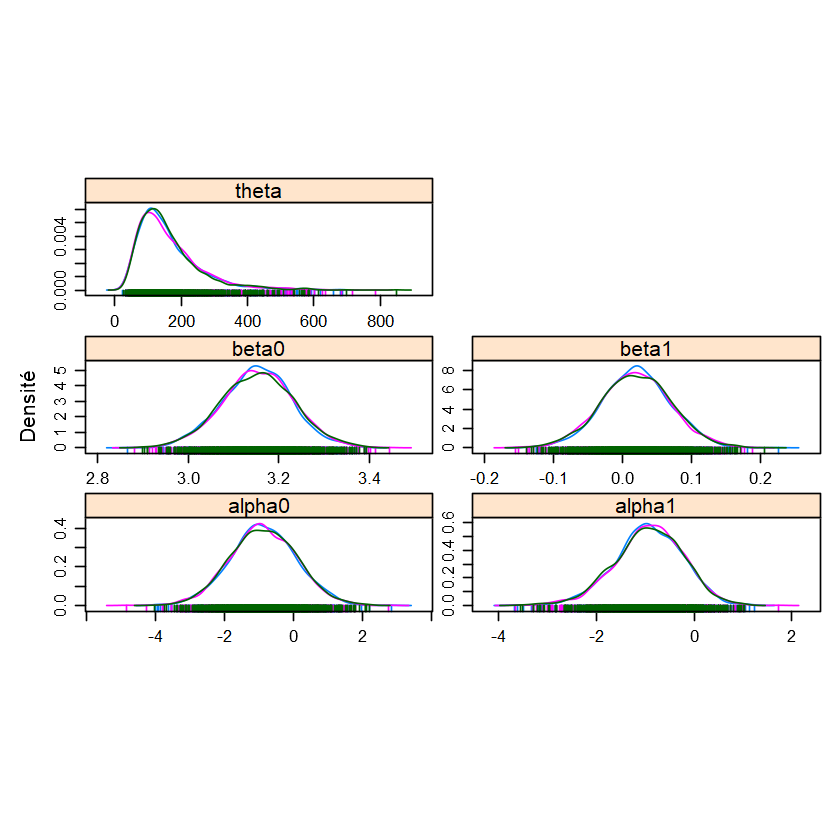

[1] "pessimistic"


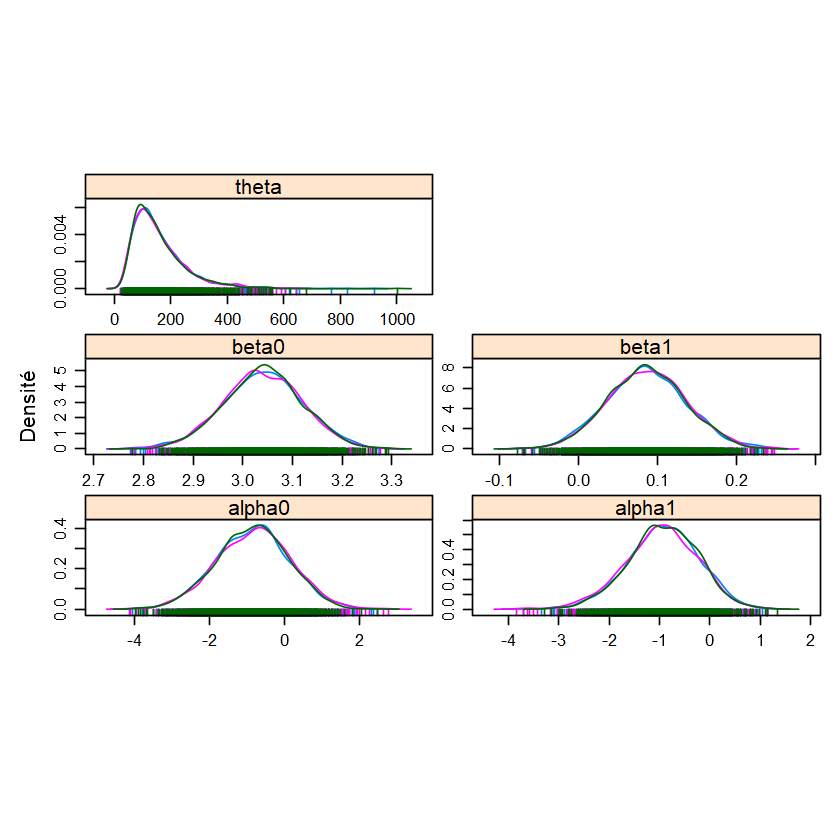

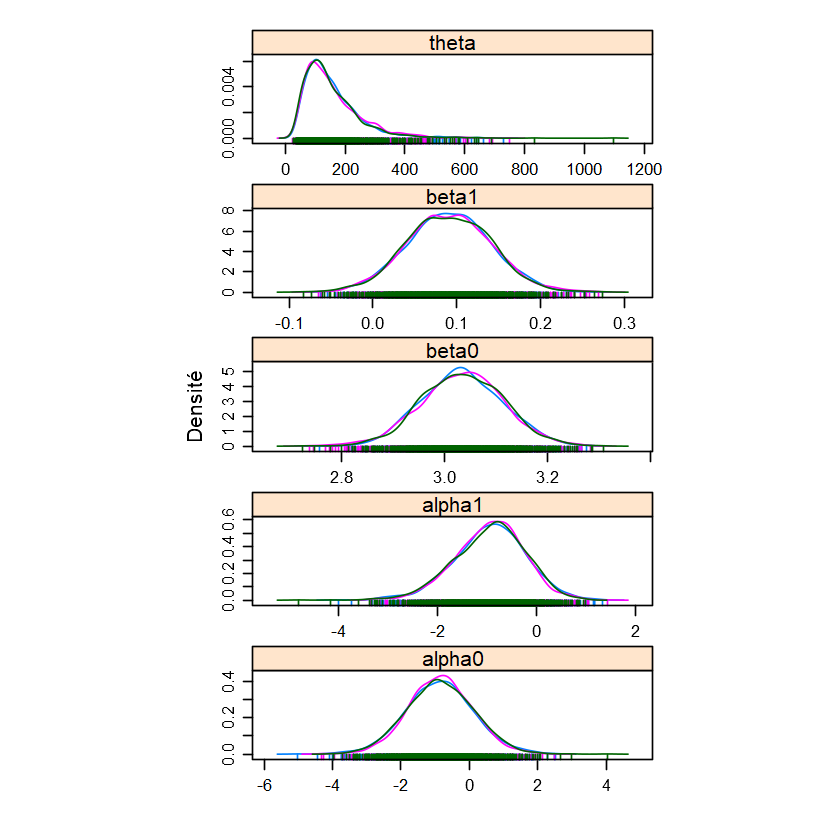

In [ ]:
par(mfrow = c(1, 5), mar=c(1,1,1,1))

print("Non informative")
bmod_zinb$graphs(samp_zinb, type_of_graph = "density")
print("optimistic")
bmod_zinb_op$graphs(samp_zinb_op, type_of_graph = "density")
print("pessimistic")
bmod_zinb_pess$graphs(samp_zinb_pess, type_of_graph = "density")


par(mfrow = c(1,1))


In [ ]:
lik_zinb<-rowSums(as.matrix(bmod_zinb$likelihood(model = mod_zinb,  likelihood_name="loglik", niter = 25000, thin = 15) ))

lik_zinb_op<-rowSums(as.matrix(bmod_zinb_op$likelihood(model = mod_zinb_op,  likelihood_name="loglik", niter = 25000, thin = 15)))

lik_zinb_pess<-rowSums(as.matrix(bmod_zinb_pess$likelihood(model = mod_zinb_pess,  likelihood_name="loglik", niter = 25000, thin = 15)))



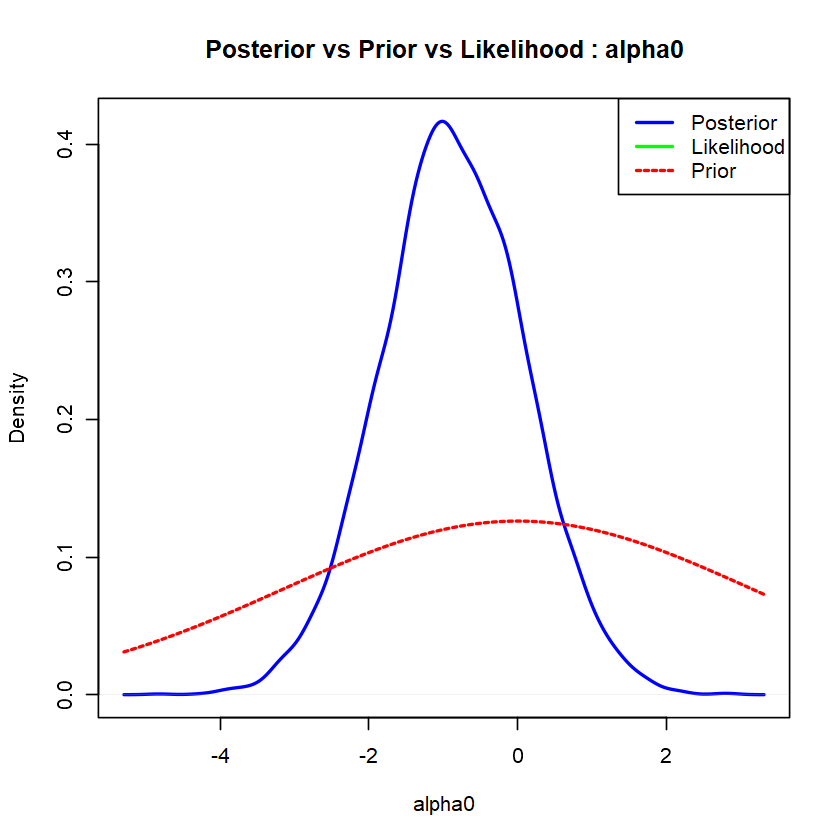

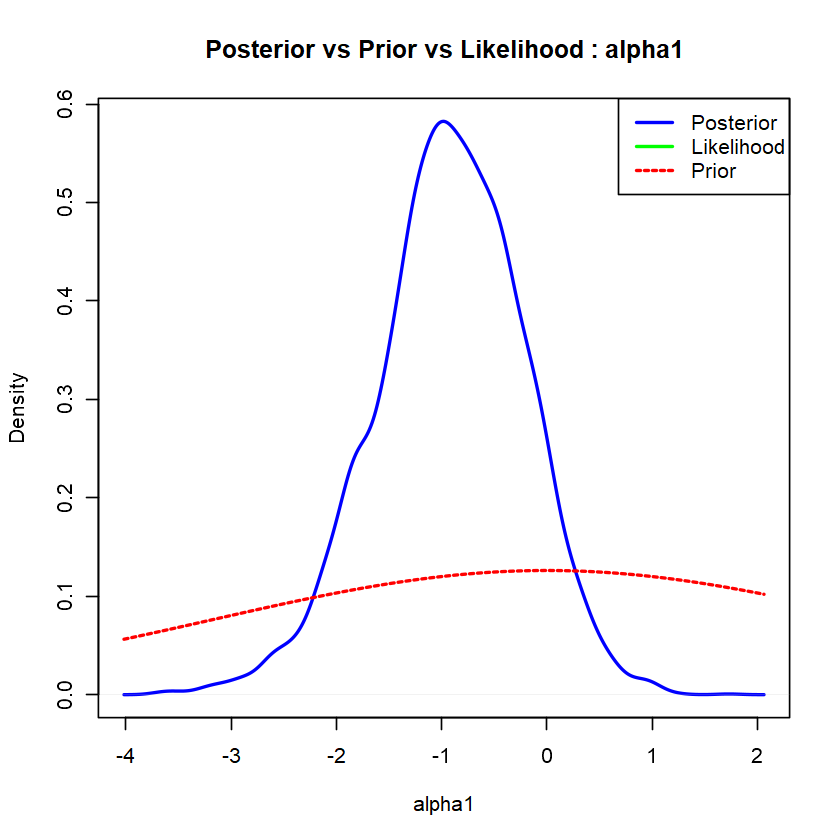

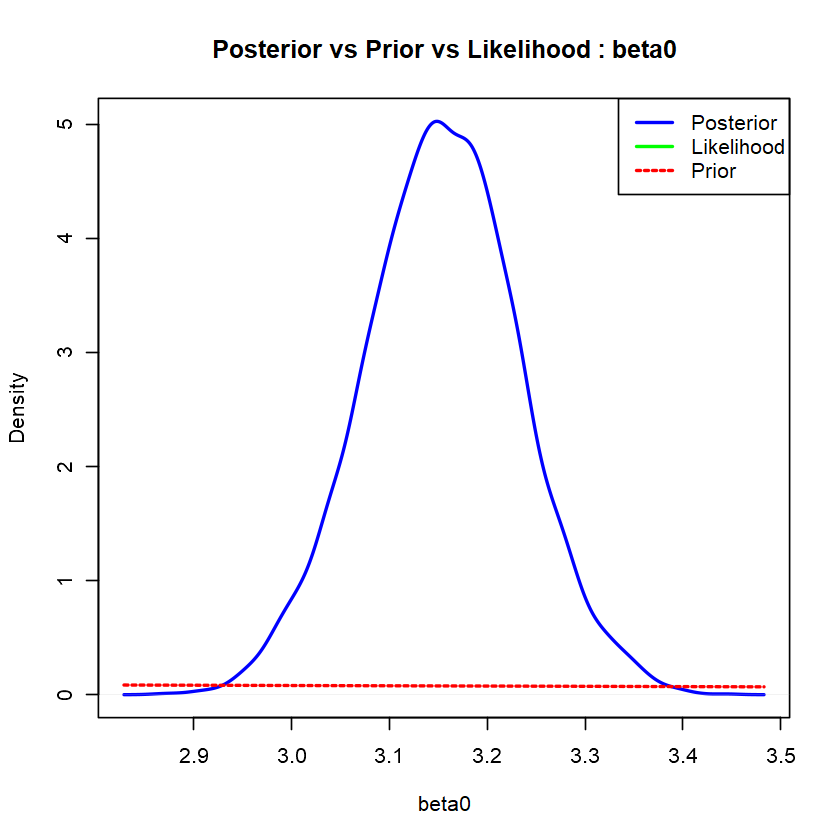

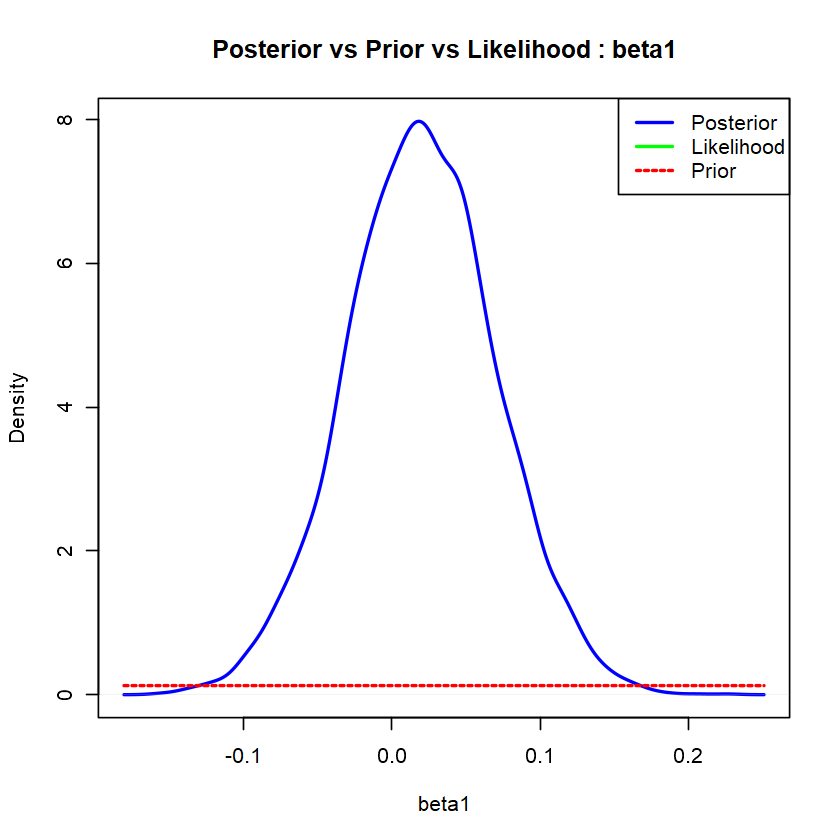

In [ ]:
bmod_zinb$graphs(sample=samp_zinb,
                likelihood=lik_zinb,
                type_of_graph = "comparison",
                apriori=list(c("alpha0",function(x) dnorm(x, mean = 0, sd = sqrt(10))),
                             c("alpha1", function(x) dnorm(x, mean = 0, sd = sqrt(10))),
                             c("beta0",function(x) dnorm(x, mean = 0, sd = sqrt(10))),
                             c("beta1", function(x) dnorm(x, mean = 0, sd = sqrt(10)))
                        )
                        )


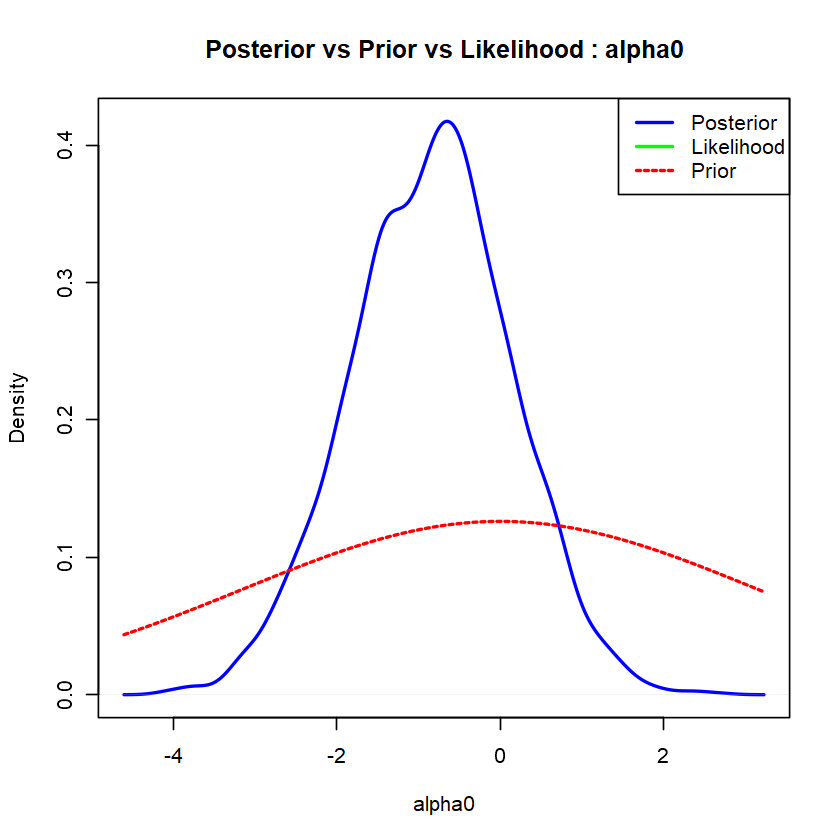

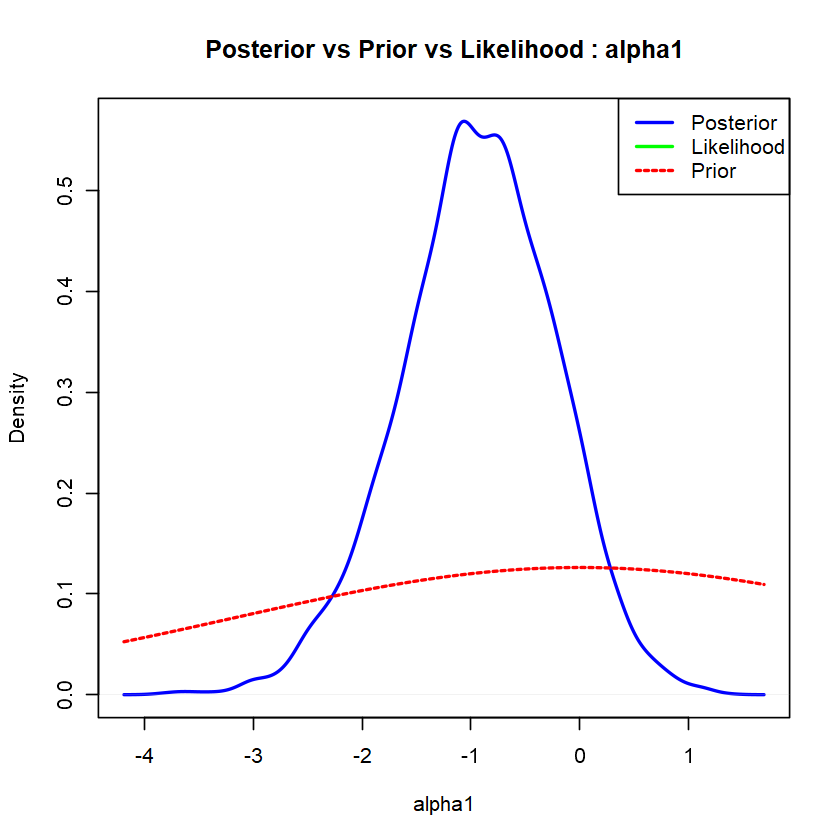

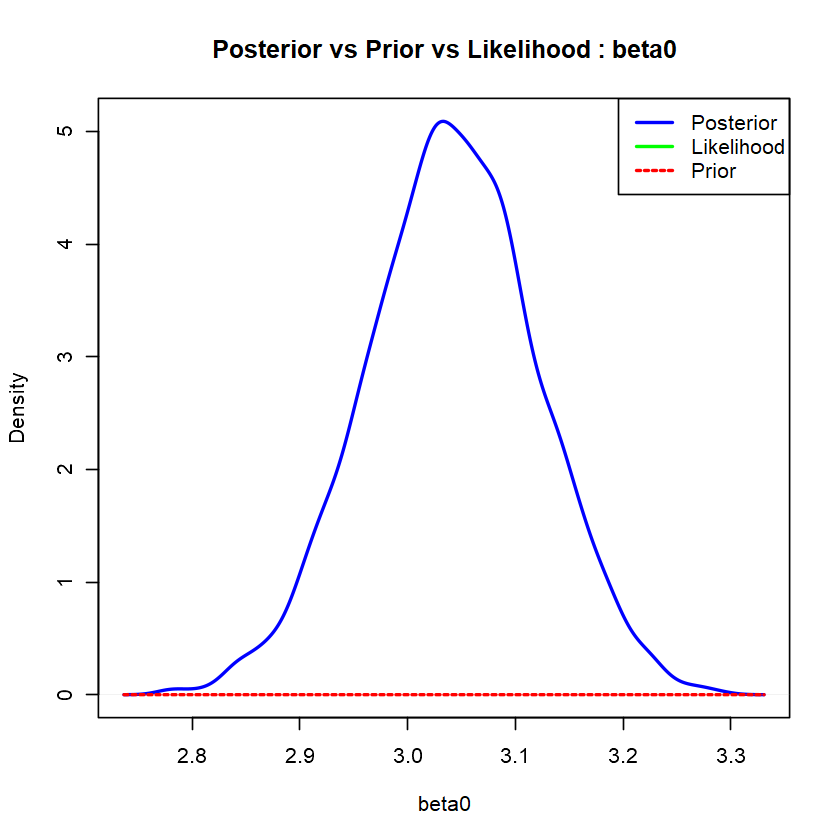

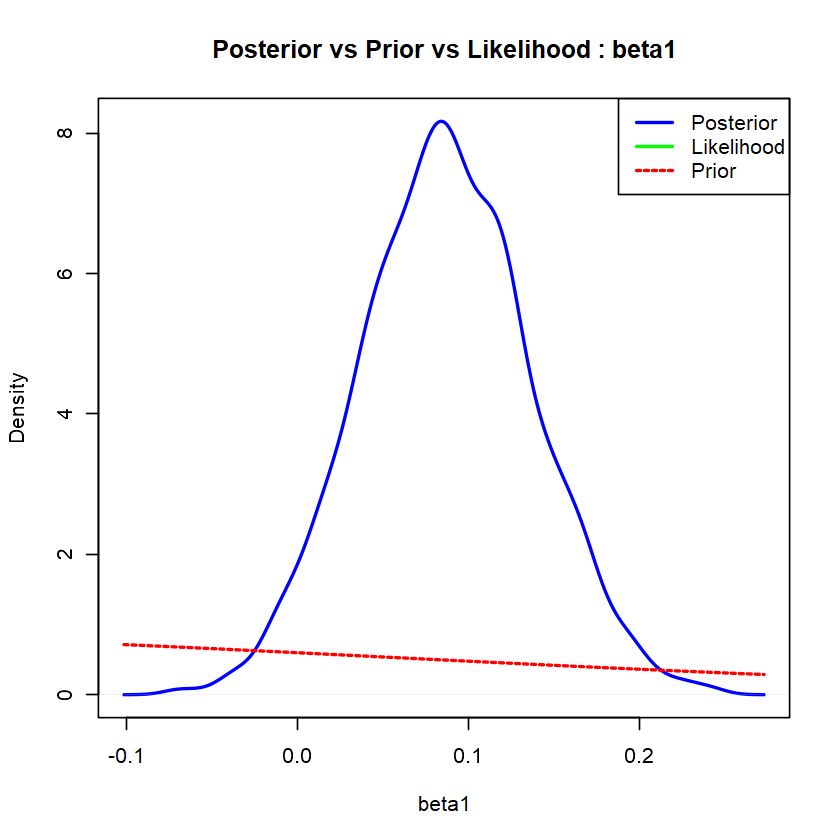

In [ ]:
bmod_zinb_op$graphs(sample=samp_zinb_op,
                likelihood=lik_zinb_op,
                type_of_graph = "comparison",
                apriori=list(c("alpha0",function(x) dnorm(x, mean = 0, sd = sqrt(10))),
                             c("alpha1", function(x) dnorm(x, mean = 0, sd = sqrt(10))),
                             c("beta0",function(x) dnorm(x, mean = -0.8, sd = sqrt(0.2))),
                             c("beta1", function(x) dnorm(x, mean = -0.4, sd = sqrt(0.2)))
                        )
                        )

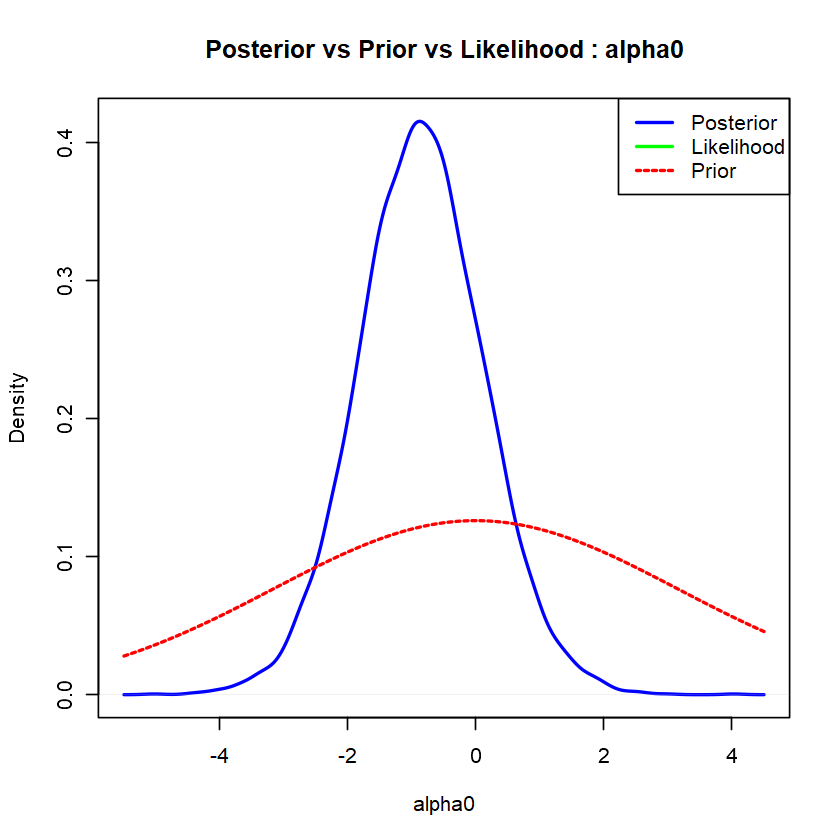

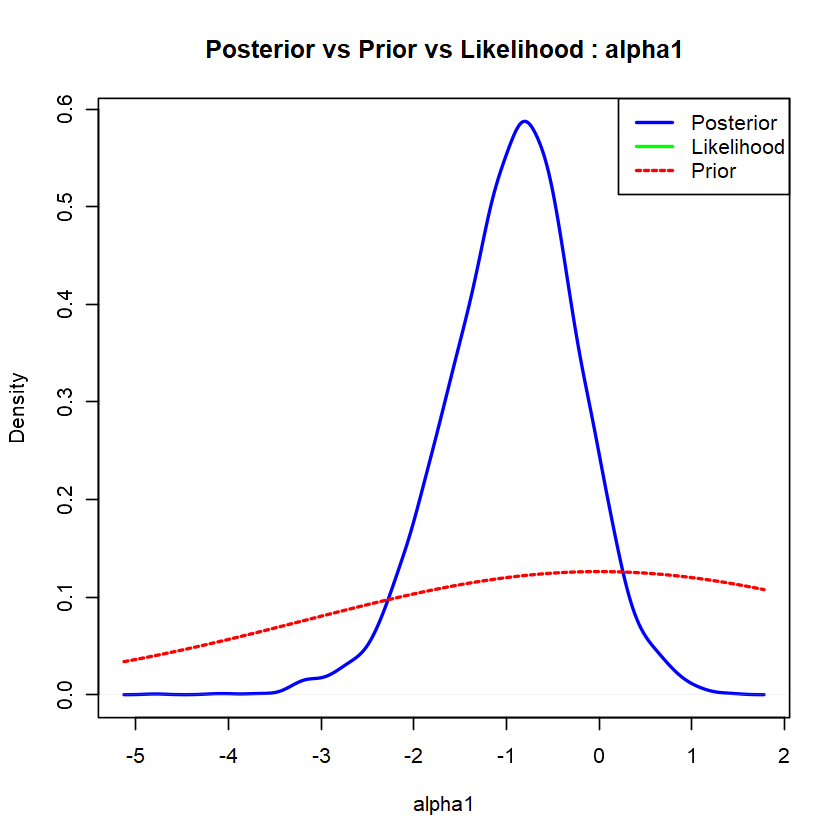

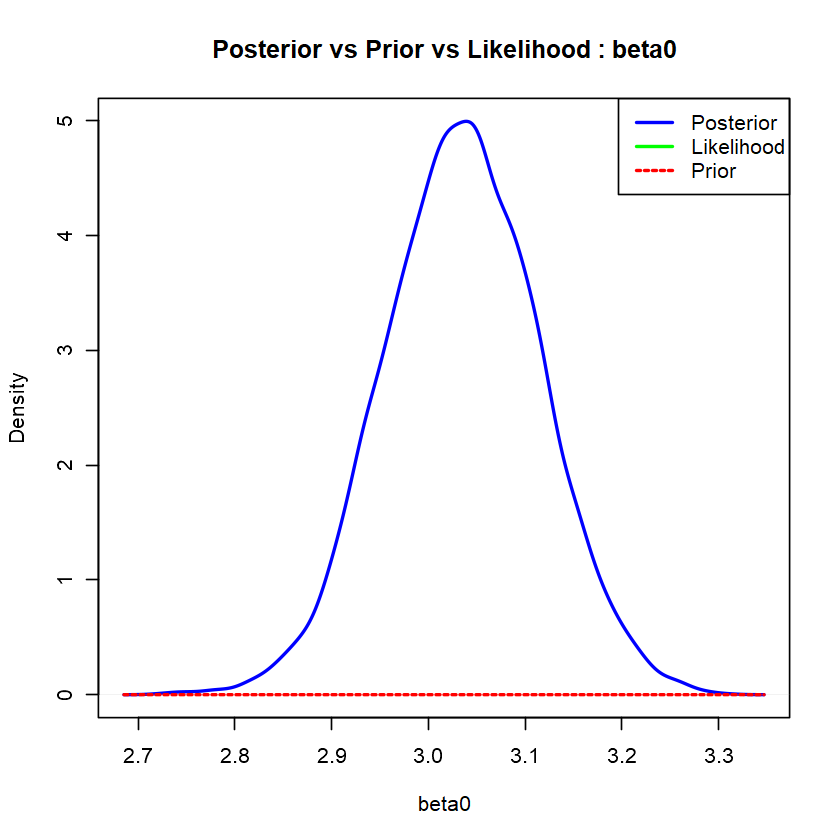

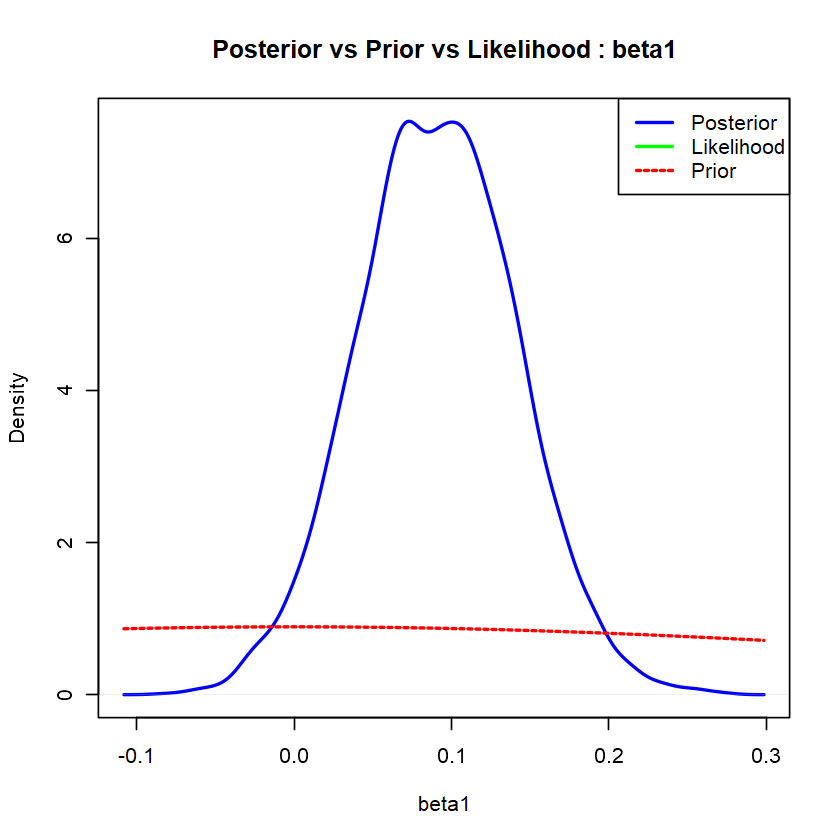

In [ ]:
bmod_zinb_pess$graphs(sample=samp_zinb_pess,
                likelihood=lik_zinb_pess,
                type_of_graph = "comparison",
                apriori=list(c("alpha0",function(x) dnorm(x, mean = 0, sd = sqrt(10))),
                             c("alpha1", function(x) dnorm(x, mean = 0, sd = sqrt(10))),
                             c("beta0",function(x) dnorm(x, mean = -0.8, sd = sqrt(0.2))),
                             c("beta1", function(x) dnorm(x, mean = 0, sd = sqrt(0.2)))
                        )
                        )

In [ ]:
curve(dnorm(mean = 0, sd = sqrt(0.2)), add = TRUE, col = "red", lwd = 2, lty = 2)

ERROR: Error in curve(dnorm(mean = 0, sd = sqrt(0.2)), add = TRUE, col = "red", : 'expr' doit être une fonction, un appel ou une expression contenant 'x'


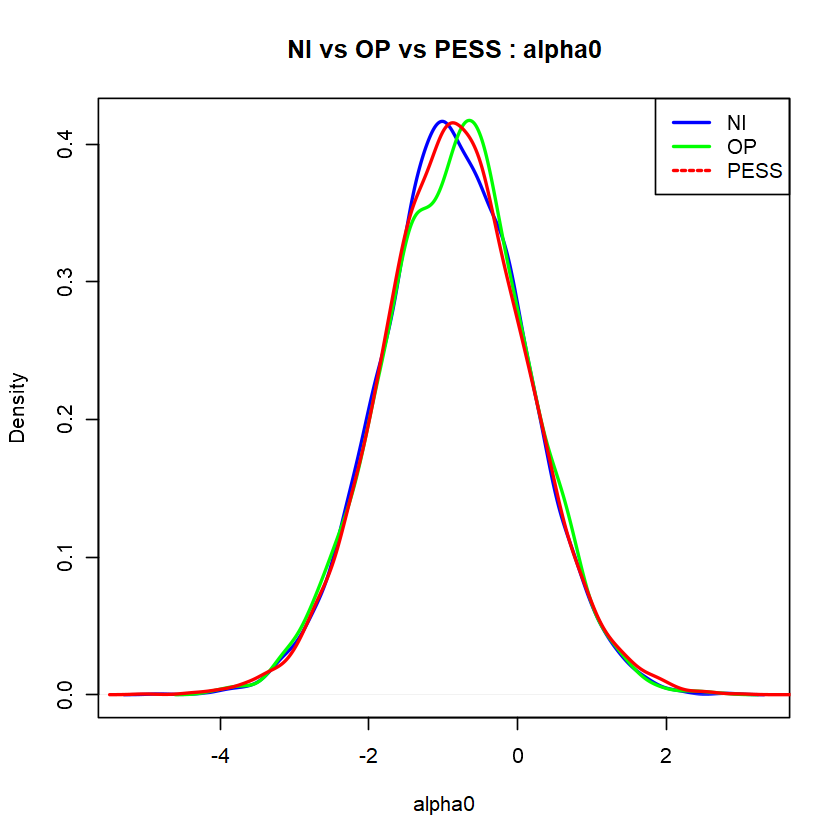

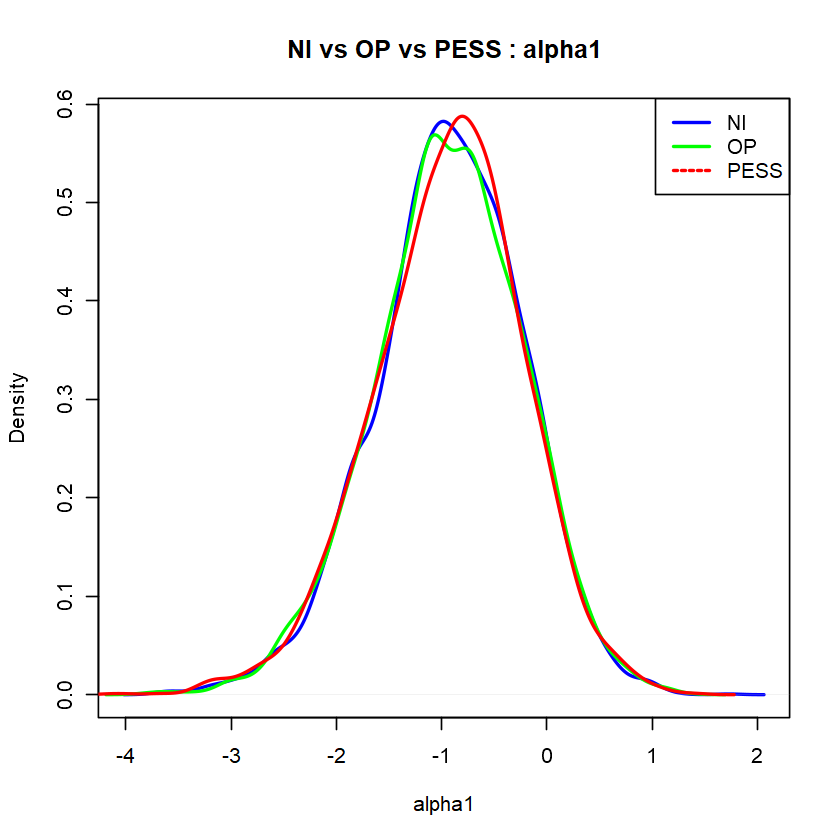

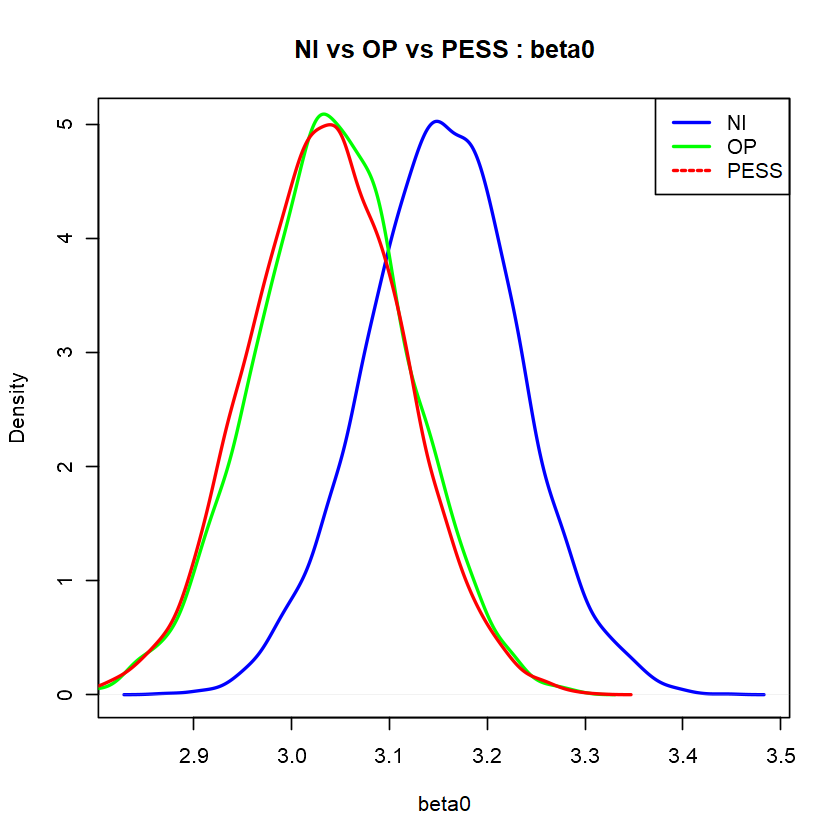

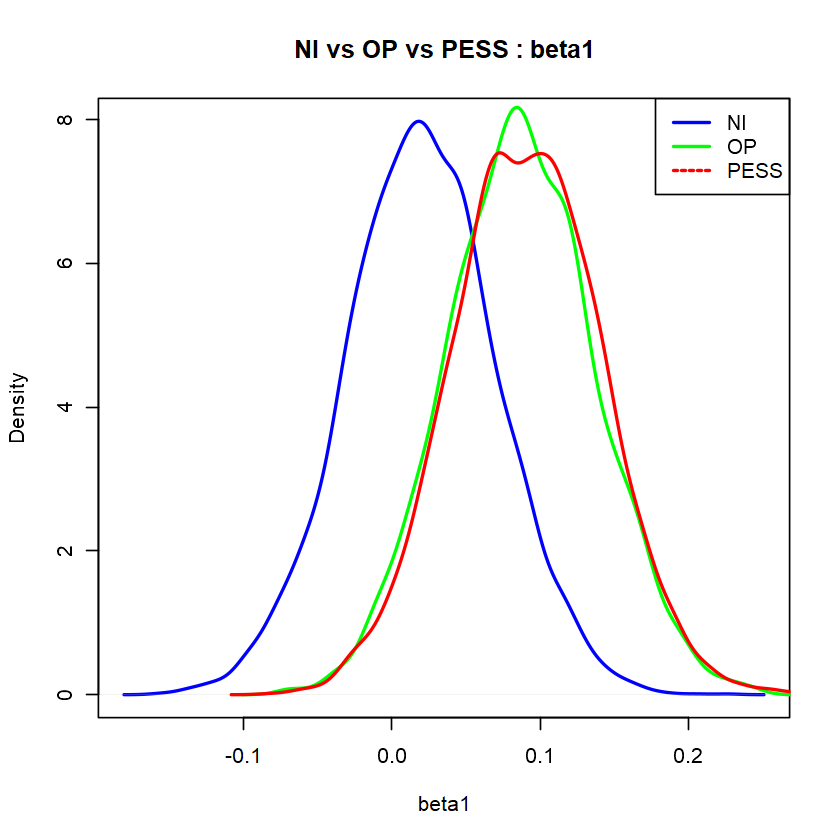

In [ ]:
for (param_name in c("alpha0", "alpha1", "beta0","beta1")){
    plot(density(as.matrix(samp_zinb)[,param_name]), main = paste("NI vs OP vs PESS", ":", param_name),
              lwd = 2, col = "blue", xlab = param_name)
    lines(density(as.matrix(samp_zinb_op)[,param_name]), lwd = 2, col = "green")
    lines(density(as.matrix(samp_zinb_pess)[,param_name]), lwd = 2, col = "red")
    legend("topright", legend = c("NI", "OP", "PESS"),col = c("blue", "green", "red"), lwd = 2, lty = c(1, 1, 2))

}


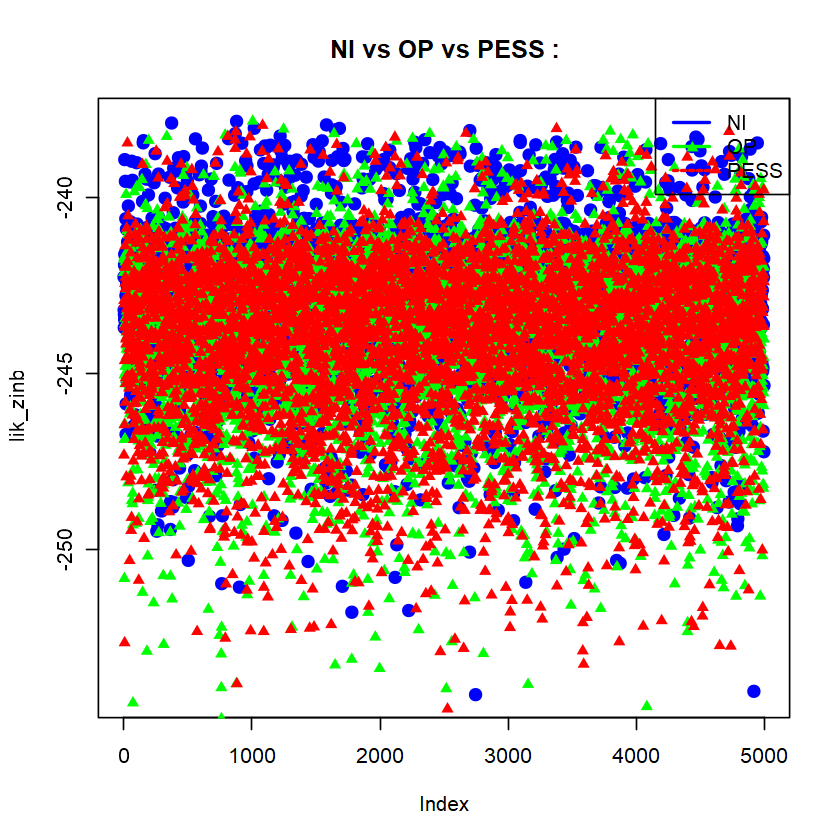

In [ ]:
plot(lik_zinb, pch=19, main = paste("NI vs OP vs PESS", ":"),
              lwd = 2, col = "blue")
points(lik_zinb_op, pch=17,lwd = 2, col = "green")
points(lik_zinb_pess,pch=17, lwd = 2, col = "red")
legend("topright", legend = c("NI", "OP", "PESS"),col = c("blue", "green", "red"), lwd = 2, lty = c(1, 1, 2))


In [ ]:
bmod_zinb$summ(samp_zinb)


Iterations = 10015:34990
Thinning interval = 15 
Number of chains = 3 
Sample size per chain = 1666 

1. Empirical mean and standard deviation for each variable,
   plus standard error of the mean:

            Mean       SD  Naive SE Time-series SE
alpha0  -0.86427  0.95942 0.0135709       0.018013
alpha1  -0.92640  0.69976 0.0098980       0.013021
beta0    3.15375  0.07886 0.0011155       0.001669
beta1    0.01997  0.05021 0.0007102       0.001057
theta  163.64469 95.89022 1.3563638       1.327775

2. Quantiles for each variable:

           2.5%      25%       50%       75%    97.5%
alpha0 -2.74974 -1.49790  -0.88010  -0.20846   1.0152
alpha1 -2.37838 -1.35464  -0.90732  -0.44287   0.3578
beta0   2.99528  3.10120   3.15428   3.20602   3.3121
beta1  -0.07939 -0.01387   0.01971   0.05314   0.1197
theta  50.70473 97.79980 139.75631 202.55430 424.5173


In [ ]:
# Coefficients
alpha0 <- -0.86427
alpha1 <- 0.95942
beta0 <- 3.15375
beta1 <- 0.07886

# Placebo (X = 0)
mu_0 <- exp(beta0)
pi_0 <- exp(alpha0) / (1 + exp(alpha0))
print(paste("Number of ventilation-free days for placebo patients:",(1 - pi_0) * mu_0))

# Treatement (X = 1)
mu_1 <- exp(beta0 + beta1)
pi_1 <- exp(alpha0 + alpha1) / (1 + exp(alpha0 + alpha1))
print(paste("Number of ventilation-free days for treatment patients:",(1 - pi_1) * mu_1))

[1] "Number of ventilation-free days for placebo patients: 16.4798186629142"
[1] "Number of ventilation-free days for treatment patients: 12.0704046012473"


In [ ]:
bmod_zinb_op$summ(samp_zinb_op)


Iterations = 10015:34990
Thinning interval = 15 
Number of chains = 3 
Sample size per chain = 1666 

1. Empirical mean and standard deviation for each variable,
   plus standard error of the mean:

            Mean       SD Naive SE Time-series SE
alpha0  -0.84489  0.97630 0.013810       0.019729
alpha1  -0.93702  0.70909 0.010030       0.014166
beta0    3.04090  0.07910 0.001119       0.001625
beta1    0.08713  0.04991 0.000706       0.001058
theta  157.95991 94.27587 1.333529       1.507282

2. Quantiles for each variable:

            2.5%      25%      50%      75%    97.5%
alpha0 -2.791014 -1.50027  -0.8106  -0.1964   1.0321
alpha1 -2.422814 -1.39152  -0.9205  -0.4497   0.3786
beta0   2.883431  2.98811   3.0410   3.0932   3.1945
beta1  -0.009388  0.05279   0.0866   0.1205   0.1864
theta  46.651643 92.21260 135.0635 198.5604 411.1380


In [ ]:
# Coefficients
alpha0 <- -0.84489  
alpha1 <- 0.93702  
beta0 <- 3.04090  
beta1 <- 0.08713  

# Placebo (X = 0)
mu_0 <- exp(beta0)
pi_0 <- exp(alpha0) / (1 + exp(alpha0))
print(paste("Number of ventilation-free days for placebo patients:",(1 - pi_0) * mu_0))

# Treatement (X = 1)
mu_1 <- exp(beta0 + beta1)
pi_1 <- exp(alpha0 + alpha1) / (1 + exp(alpha0 + alpha1))
print(paste("Number of ventilation-free days for treatment patients:",(1 - pi_1) * mu_1))

[1] "Number of ventilation-free days for placebo patients: 14.6362611352752"
[1] "Number of ventilation-free days for treatment patients: 10.889044612174"


* distribution de la différence du nombre de jours et de la proportion de treatment failure

In [ ]:
bmod_zinb_op$summ(samp_zinb_op)


Iterations = 10015:34990
Thinning interval = 15 
Number of chains = 3 
Sample size per chain = 1666 

1. Empirical mean and standard deviation for each variable,
   plus standard error of the mean:

            Mean       SD Naive SE Time-series SE
alpha0  -0.84489  0.97630 0.013810       0.019729
alpha1  -0.93702  0.70909 0.010030       0.014166
beta0    3.04090  0.07910 0.001119       0.001625
beta1    0.08713  0.04991 0.000706       0.001058
theta  157.95991 94.27587 1.333529       1.507282

2. Quantiles for each variable:

            2.5%      25%      50%      75%    97.5%
alpha0 -2.791014 -1.50027  -0.8106  -0.1964   1.0321
alpha1 -2.422814 -1.39152  -0.9205  -0.4497   0.3786
beta0   2.883431  2.98811   3.0410   3.0932   3.1945
beta1  -0.009388  0.05279   0.0866   0.1205   0.1864
theta  46.651643 92.21260 135.0635 198.5604 411.1380


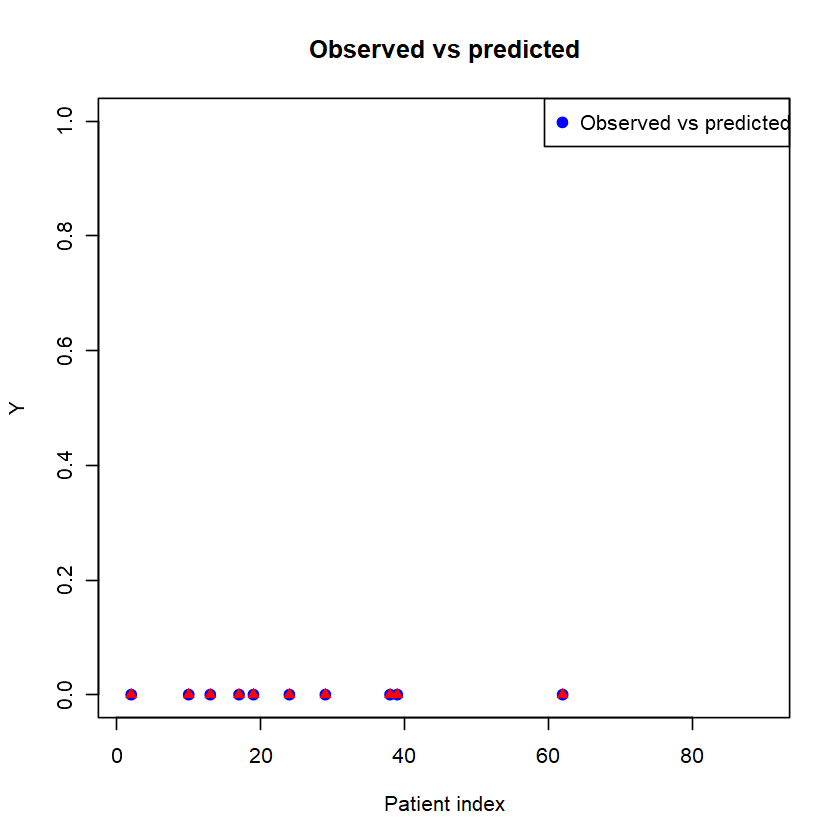

In [ ]:
bmod_zinb$predictions(mod_zinb, variable_names = c("Y_pred"), niter = 25000, thin = 15,ylim=c(0, 1))

* Fonction pour relever effet du tratiement selon caractéristiques (nbr de jours en ICU puis ventilation-free days) (variables d'interactions traitement+carac+carac*traitement)


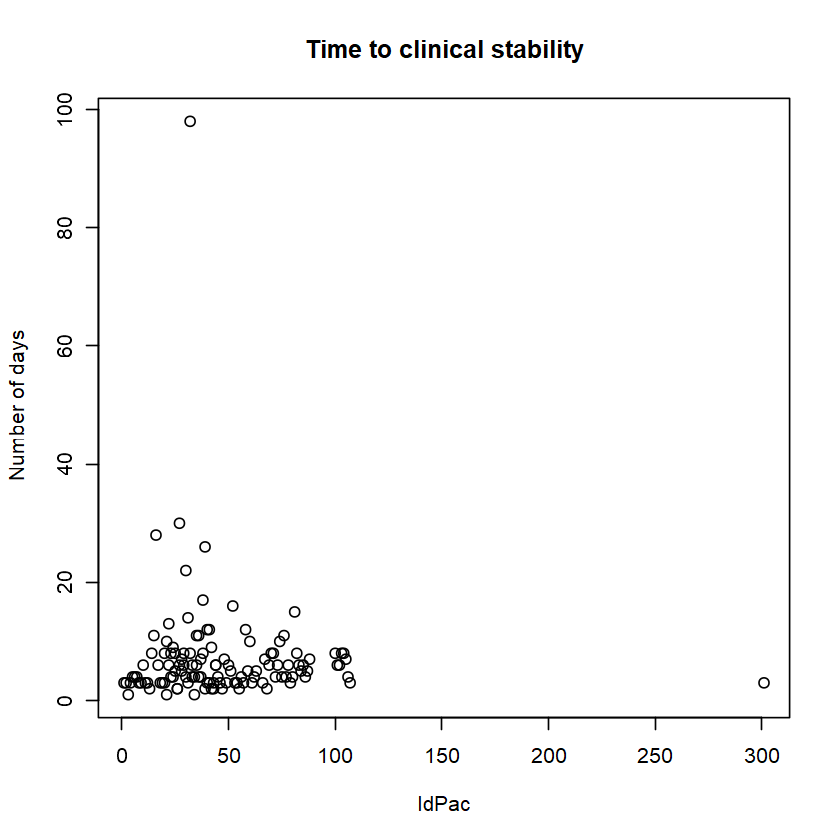

In [ ]:
plot(data_dint$IdPac[!is.na(data_dint$EstabClin)],data_dint$EstabClin[!is.na(data_dint$EstabClin)], main="Time to clinical stability", xlab="IdPac",ylab="Number of days")

In [ ]:
# Proportional hazard test for our variables of interest

## Treatment failure

surv_TF<-Surv(data_dint$Dia_TF, data_dint$TreatmentFailureMan) 
cox_model <- coxph(surv_TF~ Grupo, data= data_dint)

# Test proportional hazards assumption
ph_test <- cox.zph(cox_model)

# Print the results
print(ph_test)
summary(cox_model)

       chisq df     p
Grupo   3.24  1 0.072
GLOBAL  3.24  1 0.072


Call:
coxph(formula = surv_TF ~ Grupo, data = data_dint)

  n= 120, number of events= 24 

          coef exp(coef) se(coef)      z Pr(>|z|)  
Grupo1 -0.9740    0.3776   0.4493 -2.168   0.0302 *
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

       exp(coef) exp(-coef) lower .95 upper .95
Grupo1    0.3776      2.649    0.1565    0.9108

Concordance= 0.614  (se = 0.052 )
Likelihood ratio test= 5.2  on 1 df,   p=0.02
Wald test            = 4.7  on 1 df,   p=0.03
Score (logrank) test = 5.08  on 1 df,   p=0.02


p = 0.072 → Not significant at 5% level, so there is no evidence that the proportional hazards assumption is violated for time to treatment failure

In [ ]:
#Log rank test
survdiff(surv_TF ~ Grupo, data = data)

Call:
survdiff(formula = surv_TF ~ Grupo, data = data)

         N Observed Expected (O-E)^2/E (O-E)^2/V
Grupo=0 59       17     11.8      2.31      4.89
Grupo=1 61        7     12.2      2.23      4.89

 Chisq= 4.9  on 1 degrees of freedom, p= 0.03 

       chisq df     p
Grupo   3.24  1 0.072
GLOBAL  3.24  1 0.072


Call:
survdiff(formula = surv_TF ~ Grupo, data = data)

         N Observed Expected (O-E)^2/E (O-E)^2/V
Grupo=0 59       17     11.8      2.31      4.89
Grupo=1 61        7     12.2      2.23      4.89

 Chisq= 4.9  on 1 degrees of freedom, p= 0.03 

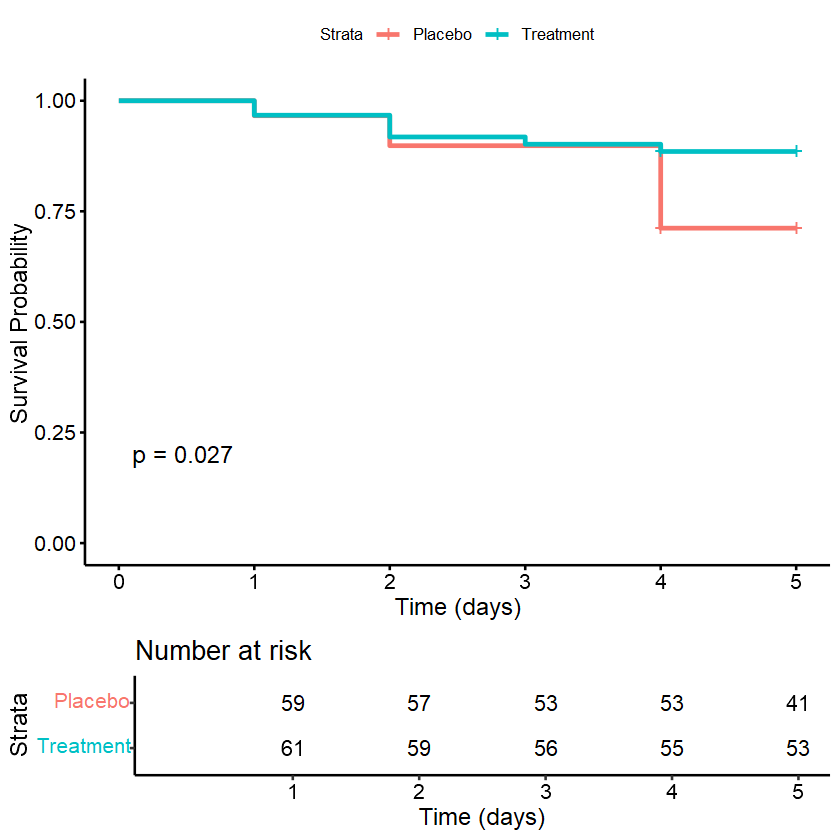

In [ ]:
# Proportional hazard test for our variables of interest
surv_TF<-Surv(data_dint$Dia_TF, data_dint$TreatmentFailureMan) 
cox_model <- coxph(surv_TF~ Grupo, data= data_dint)

# Test proportional hazards assumption
ph_test <- cox.zph(cox_model)

# Print the results
print(ph_test)

#Log rank test
survdiff(surv_TF ~ Grupo, data = data)

#Kaplan meier method
fit <- survfit(surv_TF ~ Grupo, data = data_dint)
ggsurvplot(fit, data = data_dint, pval = TRUE, conf.int = FALSE,
           risk.table = TRUE, legend.labs = c("Placebo", "Treatment"),
           xlab = "Time (days)", ylab = "Survival Probability")


There is a significative difference of time to treatment failure between the 2 groups (p-val=0.03). In particular, as seen on the graph, the treatment group survives longer, the critical points being 2 days and 4 days after the treatment.

In [ ]:
get_cox_results <- function(vars_to_explain, imp_data) {
  # Helper to extract HR, CI, p-value
  extract_hr_stats <- function(pooled_fit) {
    tidy_fit <- tidy(pooled_fit, conf.int = TRUE, exponentiate = TRUE)
    grupo_row <- tidy_fit[1,]
    
    if (nrow(grupo_row) == 0) {
      hr_ci <- NA
      p_val <- NA
    } else {
      hr <- round(grupo_row$estimate, 2)
      ci_lower <- round(grupo_row$conf.low, 2)
      ci_upper <- round(grupo_row$conf.high, 2)
      p_val <- grupo_row$p.value
      hr_ci <- paste0(hr, " (", ci_lower, " - ", ci_upper, ")")
    }
    
    list(hr_ci = hr_ci, p_val = p_val)
  }
  
  # Main mapping function
  results_list <- map(vars_to_explain, function(time_event_pair) {
    time_var <- time_event_pair[[1]]
    event_var <- time_event_pair[[2]]
    
    # Fit Cox models
    fit1 <- with(imp_data, coxph(as.formula(paste0("Surv(", time_var, ", ", event_var, ") ~ Grupo"))))
    fit2 <- with(imp_data, coxph(as.formula(paste0("Surv(", time_var, ", ", event_var, ") ~ Grupo + IL101 + PCT1 + CdxShockSept+ Centro + YearOfAdmission"))))
    pool1 <- pool(fit1)
    pool2 <- pool(fit2)

    # martingale_resid <- residuals(pool2, type = "martingale")
    # print(var)
    # print(plot(imp_data$data[["Grupo"]], martingale_resid))
    
    stats1 <- extract_hr_stats(pool1)
    stats2 <- extract_hr_stats(pool2)
    
    # Perform PH test on the first model (unadjusted)
    fit_complete <- complete(imp_data, action = 1)
    surv_obj <- Surv(fit_complete[[time_var]], fit_complete[[event_var]])
    ph_model <- coxph(surv_obj ~ Grupo, data = fit_complete)
    ph_test <- cox.zph(ph_model)
    ph_p <- ph_test$table["Grupo", "p"]
    
    verdict <- ifelse(ph_p < 0.05, "PH assumption violated", "PH assumption met")
    
    data.frame(
      Time = time_var,
      Event = event_var,
      HR_CI_not_adjusted = stats1$hr_ci,
      p_value_1 = stats1$p_val,
      HR_CI_adjusted = stats2$hr_ci,
      p_value_2 = stats2$p_val,
      ph_test_p_value = round(ph_p, 3),
      ph_test_verdict = verdict,
      stringsAsFactors = FALSE
    )
  })
  
  bind_rows(results_list)
}


In [ ]:
#Model
vars_to_expl <- list(c("Dia_TF","TreatmentFailureMan"),
                    c("tiempo_estancia","StayHosp"),
                     c("EvolDiasUCI","UCI_event"),
                     c("EvolDiasUCI_tronq","UCI_event"),
                     c("EstabClin","EstabClin_event"))
get_cox_results(vars_to_expl,imp)

Warning message in coxph.fit(X, Y, istrat, offset, init, control, weights = weights, :
"Loglik converged before variable  14 ; coefficient may be infinite. "
Warning message in coxph.fit(X, Y, istrat, offset, init, control, weights = weights, :
"Loglik converged before variable  14 ; coefficient may be infinite. "
Warning message in coxph.fit(X, Y, istrat, offset, init, control, weights = weights, :
"Loglik converged before variable  14 ; coefficient may be infinite. "
Warning message in coxph.fit(X, Y, istrat, offset, init, control, weights = weights, :
"Loglik converged before variable  14 ; coefficient may be infinite. "
Warning message in coxph.fit(X, Y, istrat, offset, init, control, weights = weights, :
"Loglik converged before variable  14 ; coefficient may be infinite. "
Warning message in coxph.fit(X, Y, istrat, offset, init, control, weights = weights, :
"Loglik converged before variable  5 ; coefficient may be infinite. "
Warning message in coxph.fit(X, Y, istrat, offset, in

Time,Event,HR_CI_not_adjusted,p_value_1,HR_CI_adjusted,p_value_2,ph_test_p_value,ph_test_verdict
<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>
Dia_TF,TreatmentFailureMan,0.38 (0.15 - 0.96),0.04167194,0.32 (0.09 - 1.15),0.07214309,0.072,PH assumption met
tiempo_estancia,StayHosp,1.01 (0.7 - 1.46),0.96566695,1 (0.66 - 1.52),0.98171935,0.718,PH assumption met
EvolDiasUCI,UCI_event,1.23 (0.6 - 2.52),0.55726073,0.96 (0.34 - 2.76),0.94065874,0.258,PH assumption met
EvolDiasUCI_tronq,UCI_event,1.42 (0.7 - 2.87),0.32206754,1.11 (0.39 - 3.11),0.83611872,0.076,PH assumption met
EstabClin,EstabClin_event,1.01 (0.68 - 1.52),0.95460566,1.11 (0.7 - 1.77),0.64312436,0.181,PH assumption met


#### Save results

In [ ]:
# Generate summaries
sheet1 <- summary_num_by_group(data_dint_explcit, "Grupo")
sheet2 <- summary_cat_by_group(data_dint_explcit, "Grupo")
# Comparison tests
sheet3 <- compare_var_num(data_dint,"Grupo")
sheet4<-compare_proportions(data_dint, c("TreatmentFailureMan",
                                "EarlyFailureMan","EMV","ESS","ED",
                                "LateFailureMan","RP","RF","LMV","LSS","EvolMort28"),
                                 "Grupo")
sheet5 <- compare_var_cat(data_dint,"Grupo")
sheet6 <- results_df
sheet7<-get_cox_results(vars_to_expl,imp)


# Create a new Excel workbook
wb <- createWorkbook()

# Add numerical summary
addWorksheet(wb, "NumericalSummary")
writeData(wb, "NumericalSummary", sheet1)

# Add categorical summary
addWorksheet(wb, "CategoricalSummary")
writeData(wb, "CategoricalSummary", sheet2)

# Add numerical test
addWorksheet(wb, "NumericalTests1")
writeData(wb, "NumericalTests1", sheet3)
addWorksheet(wb, "NumericalTests2")
writeData(wb, "NumericalTests2", sheet4)

# Add categorical test
addWorksheet(wb, "CategoricalTests")
writeData(wb, "CategoricalTests", sheet5)

# Add logistic regression
addWorksheet(wb, "logit")
writeData(wb, "logit", sheet6)

# Add cox model
addWorksheet(wb, "cox")
writeData(wb, "cox", sheet7)

# Save the Excel file
saveWorkbook(wb, "Summary_of_analysises_ITT.xlsx", overwrite = TRUE)

Warning message in group_var == 1 & !is.na(x):
"la taille d'un objet plus long n'est pas multiple de la taille d'un objet plus court"
Warning message in group_var == 0 & !is.na(x):
"la taille d'un objet plus long n'est pas multiple de la taille d'un objet plus court"
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
"impossible de calculer la p-value exacte avec des ex-aequos"
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
"impossible de calculer la p-value exacte avec des ex-aequos"
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
"impossible de calculer la p-value exacte avec des ex-aequos"
Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximat

### Per protocol

#### Comparison tests

In [ ]:
data_dint_pp<-data[data$PP==1,vars_dint] %>%
  mutate(FINE=as.factor(FINE))%>%
  mutate(BProteinasTot =as.numeric(as.character(BProteinasTot)))%>%
  mutate(PCT1 =as.numeric(as.character(PCT1 )))%>%
  mutate(IL61 =as.numeric(as.character(IL61 )))%>%
  mutate(IL81 =as.numeric(as.character(IL81 )))%>%
  mutate(IL101 =as.numeric(as.character(IL101)))
data_dint_pp[["ratio_il6_il10"]]=data_dint_pp$IL101/data_dint_pp$IL61
#Manually builds early and late failure
data_dint_pp$EarlyFailureMan <- with(data_dint_pp, factor(as.integer(EMV == 1 | ESS == 1 | ED == 1), levels = c(0,1)))
data_dint_pp$LateFailureMan <- with(data_dint_pp, factor(as.integer(LMV == 1 | LSS == 1 | RP == 1 | RF == 1), levels = c(0,1)))
data_dint_pp$TreatmentFailureMan <- with(data_dint_pp, factor(as.integer(EarlyFailureMan == 1 | LateFailureMan == 1), levels = c(0,1)))
# #Suppress
# data_dint_pp <- data_dint_pp %>% select(-LateFailure, -EarlyFailure)

In [ ]:
#Test normality of numerical variables
normality <- sapply(data_dint_pp,seek_normality)
data.frame(variable = names(normality), normality = normality)

,variable,normality
,<chr>,<chr>
IdPac,IdPac,not normal
YearOfAdmission,YearOfAdmission,NA
Edad,Edad,not normal
Sexo,Sexo,NA
Fumador,Fumador,NA
Diabetes,Diabetes,NA
EPOC,EPOC,NA
HTA,HTA,NA
Cancer,Cancer,NA


In [ ]:

#Explicit modalities of categorical variables
data_dint_pp_explcit<-data_dint_pp %>%
  mutate(Sexo = recode(Sexo, "1" = "Male", "0" = "Female")) %>%
  mutate(Diabetes = recode(Diabetes, "1" = "Diabetes mellitus", "0" = "Not diabetic"))%>%
  mutate(Fumador = recode(Fumador, "1" = "Current smoker", "0" = "Not smoker"))%>%
  mutate(EPOC = recode(EPOC, "1" = "Chronic pulmonary disease", "0" = "Not EPOC"))%>%
  mutate(HTA = recode(HTA, "1" = "Congestive heart failure", "0" = "Not HTA"))%>%
  mutate(Cancer = recode(Cancer, "1" = "History of malignancy", "0" = "No cancer"))%>%
  mutate(CardIsq = recode(CardIsq, "1" = "Ischemic heart disease", "0" = "No IHD"))%>%
  mutate(CFiebre = recode(CFiebre, "1" = "Fever", "0" = "No fever"))%>%
  mutate(CAlterNivelConc = recode(CAlterNivelConc, "1" = "Altered Mental status", "0" = "Not altered"))%>%
  mutate(CDisnea = recode(CDisnea, "1" = "Breathlessness", "0" = "No Breathlessness"))%>%
  mutate(CTos = recode(CTos, "1" = "Cough", "0" = "No cough"))%>%
  mutate(CEscalofrios = recode(CEscalofrios, "1" = "Chills", "0" = "No chills"))%>%
  mutate(CDolorPleur = recode(CDolorPleur, "1" = "Chest pain", "0" = "No chest pain"))%>%
  mutate(CdxVM = recode(CdxVM, "1" = "Mechanical ventialtion", "0" = "No MV"))%>%
  mutate(CdxVMtipo = recode(CdxVMtipo, "1" = "Noninvasive alone","2" = "Noninvasive followed by invasive","3" = "Invasive alone", "0" = "No MV"))%>%
  mutate(CdxShockSept = recode(CdxShockSept, "1" = "Septic shock", "0" = "No shock"))%>%
  mutate(CdxPAP90 = recode(CdxPAP90, "1" = "Systolic blood pressure< 90 mmHg", "0" = "PAP>90"))%>%
  mutate(CdxMultilobar = recode(CdxMultilobar, "1" = "Multilobar involvement", "0" = "No involvement"))%>%
  mutate(CdxPaFi250 = recode(CdxPaFi250, "1" = "Ratio of PaO2 to fraction of inspired oxygen < 250 mmHg", "0" = "Ratio>250"))%>%
  mutate(UCI_Interm = recode(UCI_Interm, "1" = "ICU admission", "0" = "No ICU admission"))%>%
  mutate(TimeToFirstAntibiotic_SS = recode(TimeToFirstAntibiotic_SS, "1" = "Within 1h in patients with septic shock", "0" = "Within 4h in patients without septic shock"))%>% 
  mutate(macrolide = recode(macrolide, "1" = " Macrolide combination therapy", "0" = "No macrolide"))%>%
  mutate(EarlyFailureMan = recode(EarlyFailureMan, "1" = "Early failure", "0" = "No early failure"))%>%
  mutate(EMV = recode(EMV, "1" = "Early mechanical ventilation", "0" = "EVM"))%>%
  mutate(ESS = recode(ESS, "1" = "Early septic shock", "0" = "no ESS"))%>%
  mutate(ED = recode(ED, "1" = "Early death", "0" = "no ED"))%>%
  mutate(LateFailureMan = recode(LateFailureMan, "1" = "Late failure", "0" = "No late failure"))%>%
  mutate(RP = recode(RP, "1" = "Radiographic progression", "0" = "no RP"))%>%
  mutate(RF = recode(RF, "1" = "Respiratory failure", "0" = "no RF"))%>%
  mutate(LMV = recode(LMV, "1" = "Late mechanical ventilation", "0" = "no LMV"))%>%
  mutate(LSS = recode(LSS, "1" = "Late septic shock", "0" = "no LSS"))%>%
  mutate(EvolMort28 = recode(EvolMort28, "1" = "In-hospitality mortality", "0" = "no IHM"))%>%
  mutate(TreatmentFailureMan = recode(TreatmentFailureMan, "1" = "Treatment failure", "0" = "No treatment failure"))
#Summary of categorical variables
summary_cat_by_group(data_dint_pp_explcit, "Grupo")

Variable,Category,Overall_N_prop,Treatment_N_prop,Placebo_N_prop
<chr>,<chr>,<chr>,<chr>,<chr>
YearOfAdmission,2004,8 ( 7 ),3 ( 5 ),5 ( 9 )
YearOfAdmission,2005,20 ( 18 ),8 ( 15 ),12 ( 21 )
YearOfAdmission,2006,21 ( 19 ),13 ( 24 ),8 ( 14 )
YearOfAdmission,2007,17 ( 15 ),10 ( 18 ),7 ( 12 )
YearOfAdmission,2008,14 ( 12 ),7 ( 13 ),7 ( 12 )
YearOfAdmission,2009,9 ( 8 ),3 ( 5 ),6 ( 11 )
YearOfAdmission,2010,10 ( 9 ),4 ( 7 ),6 ( 11 )
YearOfAdmission,2011,11 ( 10 ),6 ( 11 ),5 ( 9 )
YearOfAdmission,2012,2 ( 2 ),1 ( 2 ),1 ( 2 )


In [ ]:
# Summary of numerical variables 
summary_num_by_group(data_dint_pp, "Grupo")

Variable,Overall_mean_SD,Overall_med_IQR,Overall_min_max,Treatment_mean_SD,Treatment_med_IQR,Treatment_min_max,Placebo_mean_SD,Placebo_med_IQR,Placebo_min_max
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
IdPac,48.3 ( 36.6 ),40 ( 26 - 67.5 ),1 - 301,49.9 ( 43 ),39 ( 29 - 64 ),4 - 301,46.8 ( 29.4 ),44 ( 24 - 69 ),1 - 107
Edad,65 ( 19.7 ),69 ( 53 - 81 ),19 - 96,63.6 ( 19.6 ),68 ( 51.5 - 81 ),24 - 89,66.3 ( 19.8 ),70 ( 56 - 81 ),19 - 96
Puntos,107.1 ( 35.9 ),109 ( 85 - 135 ),4 - 173,105.1 ( 37.4 ),107 ( 81.2 - 134.8 ),28 - 168,109 ( 34.6 ),110 ( 88.5 - 133.5 ),4 - 173
RatioPao2_oxygen,234.5 ( 80.8 ),238.1 ( 179.6 - 278.6 ),63.6 - 609.5,239.2 ( 78.1 ),242.4 ( 217.7 - 267.4 ),63.6 - 609.5,230.2 ( 83.8 ),228.6 ( 171 - 292.6 ),76 - 407.5
BGlucosa,147.6 ( 64 ),131 ( 106 - 169.8 ),50 - 422,143.8 ( 61.6 ),136 ( 105 - 159 ),64 - 422,151.4 ( 66.7 ),129 ( 106.6 - 181 ),50 - 394.8
BCreatinina,1.6 ( 0.9 ),1.3 ( 1 - 1.7 ),0.4 - 5.2,1.5 ( 0.9 ),1.3 ( 0.9 - 1.7 ),0.6 - 4.9,1.6 ( 1 ),1.3 ( 1 - 1.8 ),0.4 - 5.2
HPlaquetas,250.4 ( 133.5 ),216 ( 176.2 - 283 ),32 - 864,234.4 ( 110.8 ),214 ( 175.5 - 277 ),32 - 630,265.2 ( 151.1 ),221 ( 181 - 283 ),105 - 864
HLeucocitos,15.4 ( 11 ),13.4 ( 9 - 21.2 ),1.3 - 74,15.6 ( 12.8 ),12.9 ( 8.4 - 17.8 ),1.3 - 74,15.2 ( 8.9 ),14.4 ( 9.3 - 23.1 ),1.4 - 36.7
BProteinasTot,26.5 ( 24.1 ),8.1 ( 6.3 - 55.5 ),4.9 - 64,28.1 ( 25.1 ),8.1 ( 6.1 - 55.8 ),4.9 - 64,24.5 ( 23.4 ),8.2 ( 6.7 - 49.5 ),5.2 - 58


In [ ]:
print(median(data_dint$ratio_il6_il10, na.rm=TRUE))
print(median(data_dint$ratio_il6_il10[data_dint$Grupo==1], na.rm=TRUE))
print(median(data_dint$ratio_il6_il10[data_dint$Grupo==0], na.rm=TRUE))


[1] 0.01974448


[1] 0.01804878
[1] 0.02441036


In [ ]:
print(quantile(data_dint$ratio_il6_il10, c=0.25, na.rm=TRUE))
print(quantile(data_dint$ratio_il6_il10[data_dint$Grupo==1], na.rm=TRUE))
print(quantile(data_dint$ratio_il6_il10[data_dint$Grupo==0], na.rm=TRUE))

          0%          25%          50%          75%         100% 
0.0005257143 0.0088300221 0.0197444832 0.0388059701 3.6791044776 
          0%          25%          50%          75%         100% 
0.0005257143 0.0086741274 0.0180487805 0.0298985686 3.6791044776 
         0%         25%         50%         75%        100% 
0.001373106 0.009166982 0.024410363 0.044398132 0.184300341 


In [ ]:
print(median(data_dint$EvolDiasUCI[data_dint$EvolDiasUCI>0], na.rm=TRUE))
print(median(data_dint$EvolDiasUCI[data_dint$EvolDiasUCI>0 & data$Grupo==1], na.rm=TRUE))
print(median(data_dint$EvolDiasUCI[data_dint$EvolDiasUCI>0 & data$Grupo==0], na.rm=TRUE))

[1] 5
[1] 4
[1] 5


In [ ]:
print(quantile(data_dint$EvolDiasUCI[data_dint$EvolDiasUCI>0], na.rm=TRUE))
print(quantile(data_dint$EvolDiasUCI[data_dint$EvolDiasUCI>0 & data$Grupo==1], na.rm=TRUE))
print(quantile(data_dint$EvolDiasUCI[data_dint$EvolDiasUCI>0 & data$Grupo==0], na.rm=TRUE))

   0%   25%   50%   75%  100% 
 1.00  3.00  5.00  7.75 63.00 
  0%  25%  50%  75% 100% 
   1    3    4    7   63 
  0%  25%  50%  75% 100% 
   1    2    5    9   35 


In [ ]:
print(median(data_dint_pp$EvolDiasUCI[data_dint_pp$EvolDiasUCI>0], na.rm=TRUE))
print(quantile(data_dint_pp$EvolDiasUCI[data_dint_pp$EvolDiasUCI>0], na.rm=TRUE))
print(median(data_dint_pp$EvolDiasUCI[data_dint_pp$EvolDiasUCI>0 & data$Grupo==1], na.rm=TRUE))
print(quantile(data_dint_pp$EvolDiasUCI[data_dint_pp$EvolDiasUCI>0 & data$Grupo==1], na.rm=TRUE))
print(median(data_dint_pp$EvolDiasUCI[data_dint_pp$EvolDiasUCI>0 & data$Grupo==0], na.rm=TRUE))
print(quantile(data_dint_pp$EvolDiasUCI[data_dint_pp$EvolDiasUCI>0 & data$Grupo==0], na.rm=TRUE))

[1] 5
   0%   25%   50%   75%  100% 
 1.00  3.00  5.00  8.25 63.00 


Warning message in data_dint_pp$EvolDiasUCI > 0 & data$Grupo == 1:
"la taille d'un objet plus long n'est pas multiple de la taille d'un objet plus court"


[1] 5


Warning message in data_dint_pp$EvolDiasUCI > 0 & data$Grupo == 1:
"la taille d'un objet plus long n'est pas multiple de la taille d'un objet plus court"


  0%  25%  50%  75% 100% 
   1    2    5    8   63 


Warning message in data_dint_pp$EvolDiasUCI > 0 & data$Grupo == 0:
"la taille d'un objet plus long n'est pas multiple de la taille d'un objet plus court"


[1] 5


Warning message in data_dint_pp$EvolDiasUCI > 0 & data$Grupo == 0:
"la taille d'un objet plus long n'est pas multiple de la taille d'un objet plus court"


  0%  25%  50%  75% 100% 
   1    3    5    8   23 


In [ ]:
#Compare categorical variables
compare_var_cat(data_dint_pp,"Grupo")

Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingenc

Variable,Test,P_value,Verdict
<chr>,<chr>,<dbl>,<chr>
YearOfAdmission,Fisher,0.818,No significative difference
Sexo,Chi2,0.354,No significative difference
Fumador,Chi2,0.956,No significative difference
Diabetes,Chi2,0.694,No significative difference
EPOC,Chi2,0.330,No significative difference
HTA,Chi2,0.530,No significative difference
Cancer,Chi2,0.227,No significative difference
CardIsq,Chi2,0.734,No significative difference
CFiebre,Chi2,0.341,No significative difference


In [ ]:
#Compare numerical variables
compare_var_num(data_dint_pp, "Grupo")

Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
"impossible de calculer la p-value exacte avec des ex-aequos"
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
"impossible de calculer la p-value exacte avec des ex-aequos"
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
"impossible de calculer la p-value exacte avec des ex-aequos"
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
"impossible de calculer la p-value exacte avec des ex-aequos"
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
"impossible de calculer la p-value exacte avec des ex-aequos"
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
"impossible de calculer la p-value exacte avec des ex-aequos"


Variable,test,pvalue,verdict
<chr>,<chr>,<dbl>,<chr>
IdPac,Mann-Whitney,0.928,No significative difference
Edad,Mann-Whitney,0.485,No significative difference
Puntos,Student,0.572,No significative difference
RatioPao2_oxygen,Mann-Whitney,0.581,No significative difference
BGlucosa,Mann-Whitney,0.620,No significative difference
BCreatinina,Mann-Whitney,0.578,No significative difference
HPlaquetas,Mann-Whitney,0.544,No significative difference
HLeucocitos,Mann-Whitney,0.505,No significative difference
BProteinasTot,Mann-Whitney,0.873,No significative difference


Same associated variables: PCT1 and IL101

In [ ]:
#Compare proportions
compare_proportions(data_dint_pp, c("TreatmentFailureMan",
                                "EarlyFailureMan","EMV","ESS","ED",
                                "LateFailureMan","RP","RF","LMV","LSS","EvolMort28"),
                                 "Grupo")

Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in prop.test(successes, totals, correct 

Variable,P_value,Difference_CI
<chr>,<dbl>,<chr>
TreatmentFailureMan,0.01,19 (6–32)
EarlyFailureMan,0.73,2 (-7–11)
EMV,0.68,2 (-6–9)
ESS,0.58,2 (-4–8)
ED,NaN,0 (0–0)
LateFailureMan,0.00,21 (10–32)
RP,0.02,12 (3–22)
RF,0.10,7 (-1–15)
LMV,0.18,5 (-2–13)


In [ ]:
compare_medians(data_dint_pp, c("tiempo_estancia","EstabClin"),"Grupo")

Variable,Median_Diff,CI_95,P_value
<chr>,<dbl>,<chr>,<dbl>
tiempo_estancia,-0.5,-3 – 3,0.6989
EstabClin,-1.0,-2 – 0,0.1284


In [ ]:
group0 <- data_dint_pp[data_dint_pp[["Grupo"]] == 0 & data_dint_pp$EvolDiasUCI>0, "EvolDiasUCI", drop = TRUE]
group1 <- data_dint_pp[data_dint_pp[["Grupo"]] == 1 & data_dint_pp$EvolDiasUCI>0, "EvolDiasUCI", drop = TRUE]
    
    # Remove NA
group0 <- group0[!is.na(group0)]
group1 <- group1[!is.na(group1)]
if (length(group0) == 0 || length(group1) == 0) return(NULL)

    # Median difference
diff_median <- round(median(group1) - median(group0), 2)
    
    # P-value
p_val <- round(wilcox.test(group0, group1, exact = FALSE)$p.value, 4)
    
    # Bootstrap CI for median difference
boot_diffs <- replicate(1000, {
      med1 <- median(sample(group1, replace = TRUE))
      med0 <- median(sample(group0, replace = TRUE))
      med1 - med0
    })
    
ci <- quantile(boot_diffs, probs = c((1 - 0.95)/2, 1 - (1 - 0.95)/2))
ci_str <- paste0(round(ci[1], 2), " – ", round(ci[2], 2))
    
data.frame(
      Variable = "EvolDiasUCI",
      Median_Diff = diff_median,
      CI_95 = ci_str,
      P_value = p_val,
      stringsAsFactors = FALSE
    )

Variable,Median_Diff,CI_95,P_value
<chr>,<dbl>,<chr>,<dbl>
EvolDiasUCI,-1,-3 – 2,0.5291


### Sensitivity analysis

In [ ]:
#Prepare variables
## Treatment failure
data_dint_pp$TreatmentFailureMan <- as.numeric(as.character(data_dint_pp$TreatmentFailureMan))
data_dint_pp$Dia_TF[is.na(data_dint_pp$Dia_TF)] <- 5 #Censor at 5 days

##Length of stay in hospital
data_dint_pp$StayHosp <- as.numeric(as.character(ifelse(is.na(data_dint_pp$tiempo_estancia),0,1)))

##Time in ICU
data_dint_pp$EvolDiasUCI[is.na(data_dint_pp$EvolDiasUCI)] <- data[data$PP==1,]$EvolDiasInterm[is.na(data[data$PP==1,]$EvolDiasUCI)]
data_dint_pp$EvolDiasUCI[is.na(data_dint_pp$EvolDiasUCI)] <- data_dint_pp$tiempo_estancia[is.na(data_dint_pp$EvolDiasUCI)]
data_dint_pp$EvolDiasUCI[data_dint_pp$UCI_Interm==0] <- 0
data_dint_pp$EvolDiasUCI_tronq<-ifelse(data_dint_pp$EvolDiasUCI>28,28,data_dint_pp$EvolDiasUCI) #truncate at 28 days
data_dint_pp$UCI_event<- as.numeric(as.character(ifelse(is.na(data[data$PP==1,]$EvolUCIFechaAlta) | is.na(data[data$PP==1,]$EvolIntermFechaAlta),0,1)))

## Clinical stability
data_dint_pp$EstabClin_event <- as.numeric(as.character(ifelse(is.na(data_dint_pp$EstabClin),0,1)))
data_dint_pp$EstabClin[is.na(data_dint_pp$EstabClin)] <- data_dint_pp$tiempo_estancia[is.na(data_dint_pp$EstabClin)]

In [ ]:
data_dint_pp$EvolDiasUCI[data_dint_pp$EvolDiasUCI>28]

[1] NA 35 63

In [ ]:
#Imputation
# List of all column names
all_vars <- names(data_dint_pp)

# Create a method vector with empty strings
meth <- rep("", length(all_vars))
names(meth) <- all_vars

# Set "pmm" only for the 3 target columns
meth[c("PCT1", "IL101","CdxShockSept")] <- "pmm"

# Run mice with the method vector
imp_pp <- mice(data_dint_pp, m = 5, method = meth, seed = 123)


 iter imp variable
  1   1  CdxShockSept  PCT1  IL101
  1   2  CdxShockSept  PCT1  IL101
  1   3  CdxShockSept  PCT1  IL101
  1   4  CdxShockSept  PCT1  IL101
  1   5  CdxShockSept  PCT1  IL101
  2   1  CdxShockSept  PCT1  IL101
  2   2  CdxShockSept  PCT1  IL101
  2   3  CdxShockSept  PCT1  IL101
  2   4  CdxShockSept  PCT1  IL101
  2   5  CdxShockSept  PCT1  IL101
  3   1  CdxShockSept  PCT1  IL101
  3   2  CdxShockSept  PCT1  IL101
  3   3  CdxShockSept  PCT1  IL101
  3   4  CdxShockSept  PCT1  IL101
  3   5  CdxShockSept  PCT1  IL101
  4   1  CdxShockSept  PCT1  IL101
  4   2  CdxShockSept  PCT1  IL101
  4   3  CdxShockSept  PCT1  IL101
  4   4  CdxShockSept  PCT1  IL101
  4   5  CdxShockSept  PCT1  IL101
  5   1  CdxShockSept  PCT1  IL101
  5   2  CdxShockSept  PCT1  IL101
  5   3  CdxShockSept  PCT1  IL101
  5   4  CdxShockSept  PCT1  IL101
  5   5  CdxShockSept  PCT1  IL101


Warning message:
"Number of logged events: 6"


#### Logistic regression

In [ ]:

# Variables to explain
vars_to_explain <- c("TreatmentFailureMan",
                     "EarlyFailureMan","EMV","ESS","ED",
                     "LateFailureMan","RP","RF","LMV","LSS","EvolMort28")

#  extract OR, CI, and p-value from a glm fit inside mice object
results_list <- map(vars_to_explain, function(var) {
  # formula for first regression: outcome ~ Grupo
  fit1 <- with(imp_pp, glm(as.formula(paste(var, "~ Grupo")), family = binomial))
  
  # formula for second regression: outcome ~ Grupo + IL101 + PCT1 + Centro + YearOfAdmission
  fit2 <- with(imp_pp, glm(as.formula(paste(var, "~ Grupo + IL101 + PCT1 + CdxShockSept+ Centro + YearOfAdmission")), family = binomial))
  
  # Pool results and extract stats
  pool1 <- pool(fit1)
  pool2 <- pool(fit2)
  
  stats1 <- extract_stats(pool1)
  stats2 <- extract_stats(pool2)
  
  data.frame(
    Variable_to_explain = var,
    OR_CI_not_adjusted = stats1$or_ci,
    p_value_1 = stats1$p_val,
    OR_CI_adjusted = stats2$or_ci,
    p_value_2 = stats2$p_val,
    stringsAsFactors = FALSE
  )
})

# Combine all into one dataframe
results_df_pp <- bind_rows(results_list)
results_df_pp


Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: l'algorithme n'a pas convergé"
Warning message:
"glm.fit: l'algorithme n'a pas convergé"
Warning message:
"glm.fit: l'algor

Variable_to_explain,OR_CI_not_adjusted,p_value_1,OR_CI_adjusted,p_value_2
<chr>,<chr>,<dbl>,<chr>,<dbl>
TreatmentFailureMan,0.22 (0.07 - 0.72),0.01297907,0.13 (0.03 - 0.55),0.006167976
EarlyFailureMan,0.76 (0.16 - 3.65),0.73393319,0.49 (0.06 - 4.06),0.504979245
EMV,0.68 (0.11 - 4.32),0.67933505,0.24 (0.01 - 4.84),0.349278237
ESS,0.51 (0.04 - 5.94),0.58729226,0 (0 - 126728.6),0.203728912
ED,1 (0 - Inf),1.00000000,1 (0 - Inf),1.000000000
LateFailureMan,0.06 (0.01 - 0.51),0.01006954,0.04 (0 - 0.35),0.004962106
RP,0.11 (0.01 - 0.96),0.04609870,0.06 (0.01 - 0.63),0.019450657
RF,0.19 (0.02 - 1.75),0.14159747,0.13 (0.01 - 1.4),0.091535002
LMV,0.25 (0.03 - 2.33),0.21825465,0.14 (0.01 - 1.71),0.122220619


Goodness of fit

In [ ]:
results_list <- map(vars_to_explain, function(var) {
  # formula for first regression: outcome ~ Grupo
  fit1 <- with(imp_pp, glm(as.formula(paste(var, "~ Grupo")), family = binomial))
  
  # formula for second regression: outcome ~ Grupo + IL101 + PCT1 + Centro + YearOfAdmission
  fit2 <- with(imp_pp, glm(as.formula(paste(var, "~ Grupo + IL101 + PCT1 + CdxShockSept+ Centro + YearOfAdmission")), family = binomial))

  perf1 <- extract_performance(fit1,var)
  perf2 <- extract_performance(fit2,var)
  data.frame(
    Variable_to_explain = var,
    accuracy = perf1$accuracy,
    sensitivity = perf1$sensitivity,
    specificity = perf1$specificity,
    auc = perf1$auc,
    number_deviant_residuals= perf1$number_deviant_residuals,
    accuracy_adjusted = perf2$accuracy,
    sensitivity_adjusted = perf2$sensitivity,
    specificity_adjusted = perf2$specificity,
    auc_adjusted = perf2$auc,
    number_deviant_residuals_adjusted= perf2$number_deviant_residuals,
    stringsAsFactors = FALSE
  )
})

# Combine all into one dataframe
results_df <- bind_rows(results_list)
results_df

ERROR: [1m[33mError[39m in `map()`:[22m
[1m[22m[36mℹ[39m In index: 1.
[1mCaused by error in `data.frame()`:[22m
[33m![39m les arguments impliquent des nombres de lignes différents : 1, 0


The models are fairly well-fitted. But can predict who won't have an outcomme but cannot predict who will.

Let's model treatment failure by severity

In [ ]:
data_dint_pp <- data_dint_pp %>%
  mutate(SeveryOfFailure = case_when(
    ED == 1 | ESS == 1 | LSS == 1 ~ "Fatal",
    EMV == 1 | LMV == 1 | RF == 1|RP==1 ~ "Severe",
    TRUE                        ~ "No outcome"
  ))
prop.table(table(data_dint_pp$SeveryOfFailure))


     Fatal No outcome     Severe 
 0.0625000  0.8303571  0.1071429 

Fatal: 6.2% in PP vs 9.2% in ITT \
Severe: 10.7% in PP vs 10.8% in ITT\
No outcome: 83% in PP vs 80% in ITT


In [ ]:
table(data_dint_pp$SeveryOfFailure, data_dint_pp$Grupo)

            
              0  1
  Fatal       6  1
  No outcome 42 51
  Severe      9  3

In [ ]:
prop.table(table(data_dint_pp$SeveryOfFailure, data_dint_pp$Grupo),margin=2)

            
                      0          1
  Fatal      0.10526316 0.01818182
  No outcome 0.73684211 0.92727273
  Severe     0.15789474 0.05454545

In [ ]:
# Fit multinomial model
data_dint_pp$SeveryOfFailure <- ordered(data_dint_pp$SeveryOfFailure, levels = c("No outcome", "Severe", "Fatal"))
model <- multinom(SeveryOfFailure ~ Grupo, data = data_dint_pp)
tidy(model, exponentiate = TRUE, conf.int = TRUE)



# weights:  9 (4 variable)
initial  value 123.044576 
iter  10 value 59.949941
final  value 59.530601 
converged


y.level,term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Severe,(Intercept),0.2142853,0.3673156,-4.193796,2.743245e-05,0.10431166,0.4402021
Severe,Grupo1,0.2745100,0.6984714,-1.850853,6.419077e-02,0.06982618,1.0791905
Fatal,(Intercept),0.1428568,0.4364361,-4.458642,8.248043e-06,0.06073035,0.3360439
Fatal,Grupo1,0.1372560,1.1000359,-1.805312,7.102593e-02,0.01589202,1.1854508


Results for multinomial regressions are not significative at a 5% level

In [ ]:
#Create a table of counts and risks for severity of treatment failure
risk_table_pp<-data_dint_pp %>%
  group_by(Grupo) %>%
  summarise(
    n = n(),
    FatalCount = sum(SeveryOfFailure=="Fatal"),
    SevereCount = sum(SeveryOfFailure=="Severe"),
    NoOutcomeCount = sum(SeveryOfFailure=="No outcome"),
    FatalRisk = FatalCount / n,
    SevereOrFatalRisk = SevereCount / n,
    NoOutcomeRisk = NoOutcomeCount / n
  )


In [ ]:
relative_risk(risk_table_pp, "fatal")
relative_risk(risk_table_pp, "severe")
relative_risk(risk_table_pp, "no outcome")

,Severity,RR,CI_RR,OR,CI_OR,p_value
,<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>
odds ratio,fatal,0.173,0.021 - 1.389,0.16,0.003 - 1.385,0.1136025


,Severity,RR,CI_RR,OR,CI_OR,p_value
,<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>
odds ratio,severe,0.345,0.099 - 1.209,0.311,0.051 - 1.341,0.1247459


,Severity,RR,CI_RR,OR,CI_OR,p_value
,<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>
odds ratio,no outcome,1.258,1.06 - 1.494,4.495,1.301 - 20.022,0.01065823


RR and OR are lower in PP than in ITT for bad outcomes, and higher for no outcome. 

In [ ]:
relative_risk_within(risk_table_pp,"fatal")
relative_risk_within(risk_table_pp,"severe")

Treatment,RR,pvalue,CI
<chr>,<dbl>,<dbl>,<chr>
Treatment,0.020,0,0.003 - 0.142
Placebo,0.143,0,0.061 - 0.336


Treatment,RR,pvalue,CI
<chr>,<dbl>,<dbl>,<chr>
Treatment,0.059,0,0.018 - 0.188
Placebo,0.214,0,0.104 - 0.44


#### log-rank test and Cox model

In [ ]:
model <- glm(Dia_TF ~ Grupo , family = poisson(), data = data_dint_pp)

# Calculate dispersion statistic
dispersion <- sum(residuals(model, type = "pearson")^2) / model$df.residual
print(dispersion)


[1] 0.1297806


under dispersion

In [ ]:
#Estimating time to treatment failure with doble poisson...
db_model_pp <- with(imp_pp, gamlss(Dia_TF ~Grupo, family = DPO))
summary(db_model_pp)

GAMLSS-RS iteration 1: Global Deviance = 283.507 
GAMLSS-RS iteration 2: Global Deviance = 283.5032 
GAMLSS-RS iteration 3: Global Deviance = 283.5027 
GAMLSS-RS iteration 1: Global Deviance = 283.507 
GAMLSS-RS iteration 2: Global Deviance = 283.5032 
GAMLSS-RS iteration 3: Global Deviance = 283.5027 
GAMLSS-RS iteration 1: Global Deviance = 283.507 
GAMLSS-RS iteration 2: Global Deviance = 283.5032 
GAMLSS-RS iteration 3: Global Deviance = 283.5027 
GAMLSS-RS iteration 1: Global Deviance = 283.507 
GAMLSS-RS iteration 2: Global Deviance = 283.5032 
GAMLSS-RS iteration 3: Global Deviance = 283.5027 
GAMLSS-RS iteration 1: Global Deviance = 283.507 
GAMLSS-RS iteration 2: Global Deviance = 283.5032 
GAMLSS-RS iteration 3: Global Deviance = 283.5027 
******************************************************************
Family:  c("DPO", "Double Poisson") 

Call:  gamlss(formula = Dia_TF ~ Grupo, family = DPO) 

Fitting method: RS() 

--------------------------------------------------------

ERROR: Error in summary(x)$p.table: $ operator is invalid for atomic vectors


: 

In [ ]:
#negative binomial to estimate los in ICU
nb_model_pp <- with(imp_pp,glm.nb(EvolDiasUCI ~Grupo))
summary(pool(nb_model_pp))

ERROR: Error in with(imp_pp, glm.nb(EvolDiasUCI ~ Grupo)): objet 'imp_pp' introuvable


In [ ]:
#Model
get_cox_results(vars_to_expl,imp_pp)

Time,Event,HR_CI_not_adjusted,p_value_1,HR_CI_adjusted,p_value_2,ph_test_p_value,ph_test_verdict
<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>
tiempo_estancia,StayHosp,1.01 (0.69 - 1.48),0.9594204,1 (0.65 - 1.53),0.9943421,0.487,PH assumption met
EvolDiasUCI,UCI_Interm,0.87 (0.55 - 1.35),0.5244304,1.18 (0.69 - 2.03),0.5421603,0.586,PH assumption met
EstabClin,EstabClin_event,1.03 (0.68 - 1.56),0.8770894,1.21 (0.75 - 1.95),0.4206010,0.084,PH assumption met


#### Save results

In [ ]:
# Generate summaries
sheet1 <- summary_num_by_group(data_dint_pp_explcit, "Grupo")
sheet2 <- summary_cat_by_group(data_dint_pp_explcit, "Grupo")
# Comparison tests
sheet3 <- compare_var_num(data_dint_pp,"Grupo")
sheet4<-compare_proportions(data_dint_pp, c("TreatmentFailureMan",
                                "EarlyFailureMan","EMV","ESS","ED",
                                "LateFailureMan","RP","RF","LMV","LSS","EvolMort28"),
                                 "Grupo")
sheet5 <- compare_var_cat(data_dint_pp,"Grupo")
sheet6 <- results_df_pp
sheet7 <- get_cox_results(vars_to_expl,imp_pp)


# Create a new Excel workbook
wb <- createWorkbook()

# Add numerical summary
addWorksheet(wb, "NumericalSummary")
writeData(wb, "NumericalSummary", sheet1)

# Add categorical summary
addWorksheet(wb, "CategoricalSummary")
writeData(wb, "CategoricalSummary", sheet2)

# Add numerical test
addWorksheet(wb, "NumericalTests1")
writeData(wb, "NumericalTests1", sheet3)
addWorksheet(wb, "NumericalTests2")
writeData(wb, "NumericalTests2", sheet4)

# Add categorical test
addWorksheet(wb, "CategoricalTests")
writeData(wb, "CategoricalTests", sheet5)

# Add logistic regression
addWorksheet(wb, "logit")
writeData(wb, "logit", sheet6)

# Add cox model
addWorksheet(wb, "cox")
writeData(wb, "cox", sheet7)

# Save the Excel file
saveWorkbook(wb, "Summary_of_analysises_PP.xlsx", overwrite = TRUE)

Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
"impossible de calculer la p-value exacte avec des ex-aequos"
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
"impossible de calculer la p-value exacte avec des ex-aequos"
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
"impossible de calculer la p-value exacte avec des ex-aequos"
Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incor

### Check randomnization

In [ ]:

# Ensure InclusionDate is in Date format
data$FechaIncl <- as.Date(data$FechaIncl)

# Add derived time variables
df <- data %>%
  mutate(
    DayOfWeek = wday(FechaIncl, label = TRUE, abbr = FALSE),  # Monday, Tuesday, etc.
    Month = month(FechaIncl, label = TRUE, abbr = FALSE),
    Year = year(FechaIncl),
    GroupFull = case_when(
      Grupo == 1~ "Treatment",
      Grupo == 0 ~ "Placebo",
      TRUE ~ "Overall"
    )
  )

# Create "Overall" duplicated rows
df_all <- df %>% mutate(Grupo = "Overall")
df_combined <- bind_rows(df, df_all)


In [ ]:
p1 <- ggplot(df_combined, aes(x = FechaIncl)) +
  geom_histogram(binwidth = 30, fill = "#2c7fb8", color = "white") +
  facet_wrap(~Grupo, ncol = 3) +
  labs(title = "1. Patients by Inclusion Date", x = "Date", y = "Count") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

p2 <- ggplot(df_combined, aes(x = DayOfWeek)) +
  geom_bar(fill = "#41b6c4", color = "white") +
  facet_wrap(~Grupo, ncol = 3) +
  labs(title = "2. Patients by Day of Week", x = "Day", y = "Count") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

p3 <- ggplot(df_combined, aes(x = Month)) +
  geom_bar(fill = "#7fcdbb", color = "white") +
  facet_wrap(~Grupo, ncol = 3) +
  labs(title = "3. Patients by Month", x = "Month", y = "Count") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

p4 <- ggplot(df_combined, aes(x = as.factor(Year))) +
  geom_bar(fill = "#c7e9b4", color = "white") +
  facet_wrap(~Grupo, ncol = 3) +
  labs(title = "4. Patients by Year", x = "Year", y = "Count") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))


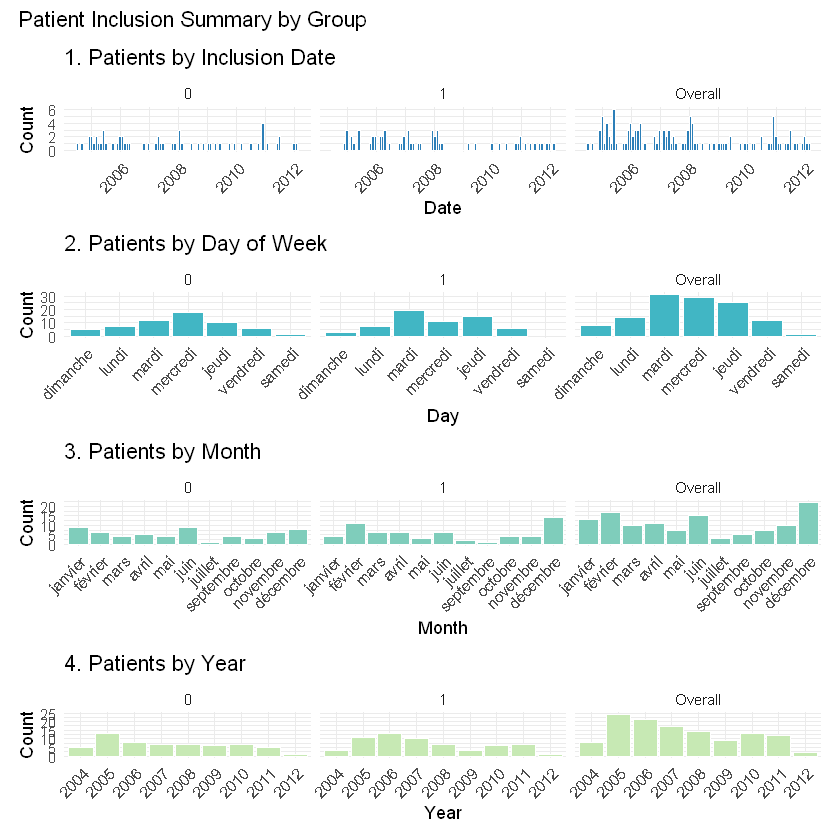

In [ ]:
# Combine all 4 plots vertically
(p1 / p2 / p3 / p4) + plot_annotation(title = "Patient Inclusion Summary by Group")


* Corriger les erreurs
* tracer les loi a priori et a posteri et vrais pour nb icu et vf
* effet du traitement (différent) pour TF, nbicu, et vf
* termes d'interractions (à automatiser): analyse avec multiples covariables
* expression d'ARN (stacy mathieu)/ expression différentielle en tumoral ou non tumoral (pas jeunes-vieux) et parès contacter l'auteur du package